In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
4# Load the dataset
file_path = '/content/drive/MyDrive/Last Updated Final Index calculated All  05.08.2025.xlsx'
data = pd.read_excel(file_path)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466 entries, 0 to 465
Data columns (total 58 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Sl No.                    344 non-null    float64
 1   Sample ID                 466 non-null    object 
 2   Type of thalassemia       466 non-null    object 
 3   Type of thalassemia.1     466 non-null    int64  
 4   RBC (X10^6/µl)            466 non-null    float64
 5   HGB (g/dL)                466 non-null    float64
 6   HCT (%)                   466 non-null    float64
 7   MCV (fL)                  466 non-null    float64
 8   MCH (pg)                  466 non-null    float64
 9   MCHC (g/dL)               466 non-null    float64
 10  PLT (X10^3/µl)            466 non-null    object 
 11  RDW-CV (%)                466 non-null    object 
 12  Hb A (%)                  465 non-null    float64
 13  Hb A2 (%)                 465 non-null    float64
 14  England an

In [ ]:
# Step 1: Check unique values in 'Type of thalassemia'
print("Unique values in 'Type of thalassemia':", data['Type of thalassemia'].unique())

# Step 2: If only one class exists, raise an error or adjust the target
if len(data['Type of thalassemia'].unique()) == 1:
    raise ValueError("The target variable 'Type of thalassemia' has only one class. Binary classification is not possible.")

# Step 3: Proceed with preprocessing if multiple classes exist
data.columns = data.columns.str.strip()  # Clean column names

# Convert categorical variables to numeric
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Handle missing values
data = data.apply(pd.to_numeric, errors='coerce')
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

# Define features and target excluding certain columns and calculating derived indices
data_imputed['E&F'] = data_imputed['MCV (fL)'] - data_imputed['RBC (X10^6/µl)'] - (5 * data_imputed['HGB (g/dL)']) - 3.4
data_imputed['Mentzer'] = data_imputed['MCV (fL)'] / data_imputed['RBC (X10^6/µl)']
data_imputed['Srivastav'] = data_imputed['MCH (pg)'] / data_imputed['RBC (X10^6/µl)']
data_imputed['S&L'] = (data_imputed['MCV (fL)']**2 * data_imputed['MCH (pg)']) / 100
data_imputed['Bessman'] = data_imputed['RDW-CV (%)'] == 15
data_imputed['Ricerca'] = data_imputed['RDW-CV (%)'] / data_imputed['RBC (X10^6/µl)']
data_imputed['G&K'] = (data_imputed['MCV (fL)']**2 * data_imputed['RDW-CV (%)']) / 100 * data_imputed['HGB (g/dL)']

# Exclude irrelevant columns as per your instruction
columns_to_exclude = ['RBC (X10^6/µl)', 'HGB (g/dL)', 'HCT (%)', 'MCV (fL)', 'MCH (pg)', 'MCHC (g/dL)',
                      'PLT (X10^3/µl)', 'RDW-CV (%)', 'Hb A (%)', 'Hb A2 (%)']

# Select the columns for features
features = data_imputed.drop(columns=columns_to_exclude + ['Sl No.', 'Sample ID', 'Type of thalassemia'])  # Drop irrelevant columns
target = data_imputed['Type of thalassemia']


Unique values in 'Type of thalassemia': ['Anemia' 'Low HbA2' 'LowHbA2' 'Beta Thalassemia Carrier']


In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedShuffleSplit
from collections import Counter

from imblearn.over_sampling import SMOTE

from warnings import filterwarnings
filterwarnings('ignore')

# STEP 1: CHECK TARGET VARIABLE


print("Unique values in 'Type of thalassemia':", data['Type of thalassemia'].unique())

if len(data['Type of thalassemia'].unique()) == 1:
    raise ValueError("Target has only one class. Classification not possible.")


# STEP 2: CLEAN DATA


data.columns = data.columns.str.strip()

# Encode categorical
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Convert to numeric
data = data.apply(pd.to_numeric, errors='coerce')


# STEP 3: HANDLE MISSING VALUES


imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)


# STEP 4: CREATE DERIVED INDICES


data_imputed['E&F'] = data_imputed['MCV (fL)'] - data_imputed['RBC (X10^6/µl)'] - (5 * data_imputed['HGB (g/dL)']) - 3.4
data_imputed['Mentzer'] = data_imputed['MCV (fL)'] / data_imputed['RBC (X10^6/µl)']
data_imputed['Srivastav'] = data_imputed['MCH (pg)'] / data_imputed['RBC (X10^6/µl)']
data_imputed['S&L'] = (data_imputed['MCV (fL)']**2 * data_imputed['MCH (pg)']) / 100
data_imputed['Bessman'] = (data_imputed['RDW-CV (%)'] == 15).astype(int)
data_imputed['Ricerca'] = data_imputed['RDW-CV (%)'] / data_imputed['RBC (X10^6/µl)']
data_imputed['G&K'] = (data_imputed['MCV (fL)']**2 * data_imputed['RDW-CV (%)']) / 100 * data_imputed['HGB (g/dL)']


# STEP 5: FEATURE SELECTION


columns_to_exclude = [
    'RBC (X10^6/µl)', 'HGB (g/dL)', 'HCT (%)',
    'MCV (fL)', 'MCH (pg)', 'MCHC (g/dL)',
    'PLT (X10^3/µl)', 'RDW-CV (%)',
    'Hb A (%)', 'Hb A2 (%)'
]

features = data_imputed.drop(columns=columns_to_exclude + ['Sl No.', 'Sample ID', 'Type of thalassemia'], errors='ignore')
target = data_imputed['Type of thalassemia']

print("\nClass distribution:\n", target.value_counts())


# STEP 6: TRAIN-TEST SPLIT


sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in sss.split(features, target):
    X_train, X_test = features.iloc[train_idx], features.iloc[test_idx]
    y_train, y_test = target.iloc[train_idx], target.iloc[test_idx]


# STEP 7: SAFE SMOTE (FIXED VERSION)


counter = Counter(y_train)
min_class_size = min(counter.values())

print("\nTraining class distribution:", counter)

if min_class_size < 2:
    print("⚠️ Too few samples → Skipping SMOTE")
    X_train_resampled, y_train_resampled = X_train, y_train

else:
    k = min(5, min_class_size - 1)
    print(f"Using SMOTE with k_neighbors = {k}")

    smote = SMOTE(k_neighbors=k, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Resampled class distribution:", Counter(y_train_resampled))


# STEP 8: FEATURE SCALING


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)


# FINAL OUTPUT READY

print("\n✅ Data is ready for ML models")
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Unique values in 'Type of thalassemia': [0 2 3 1]

Class distribution:
 Type of thalassemia
0.0    287
1.0    142
2.0     33
3.0      4
Name: count, dtype: int64

Training class distribution: Counter({0.0: 229, 1.0: 114, 2.0: 26, 3.0: 3})
Using SMOTE with k_neighbors = 2
Resampled class distribution: Counter({0.0: 229, 1.0: 229, 2.0: 229, 3.0: 229})

✅ Data is ready for ML models
Train shape: (916, 48)
Test shape: (94, 48)


In [ ]:
# Required libraries
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_auc_score, roc_curve,
    classification_report
)
import matplotlib.pyplot as plt
import numpy as np

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'SVM': SVC(probability=True, random_state=42, class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Gaussian NB': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42),
    'LDA': LinearDiscriminantAnalysis(),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

# Store results
results = {}

# Loop through all models
for name, model in models.items():
    print(f"Training and evaluating: {name}")
    model.fit(X_train_scaled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)

    # Accuracy and classification report
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    if conf_matrix.shape != (2, 2):
        print(f"Skipping {name} due to non-binary classification shape: {conf_matrix.shape}")
        continue

    classification_rep = classification_report(y_test, y_pred)

    # Extract TP, TN, FP, FN
    TN, FP, FN, TP = conf_matrix.ravel()

    # Basic diagnostics
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    youden_index = sensitivity + specificity - 1

    # Likelihood ratios and DOR
    try:
        LR_pos = sensitivity / (1 - specificity) if specificity < 1 else np.inf
        LR_neg = (1 - sensitivity) / specificity if specificity > 0 else np.inf
        DOR = LR_pos / LR_neg if LR_neg > 0 else np.inf
    except ZeroDivisionError:
        LR_pos, LR_neg, DOR = np.nan, np.nan, np.nan

    # ROC and AUC
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
        roc_auc = roc_auc_score(y_test, y_pred_prob)
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    else:
        roc_auc, fpr, tpr = np.nan, np.nan, np.nan

    # Save results
    results[name] = {
        'accuracy': accuracy,
        'conf_matrix': conf_matrix,
        'roc_auc': roc_auc,
        'classification_report': classification_rep,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'youden_index': youden_index,
        'LR+': LR_pos,
        'LR-': LR_neg,
        'DOR': DOR
    }

    # Plot ROC Curve if available
    if isinstance(fpr, np.ndarray):
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {name}')
        plt.legend(loc='lower right')
        plt.grid()
        plt.show()



Training and evaluating: Logistic Regression
Skipping Logistic Regression due to non-binary classification shape: (4, 4)
Training and evaluating: Random Forest
Skipping Random Forest due to non-binary classification shape: (4, 4)
Training and evaluating: SVM
Skipping SVM due to non-binary classification shape: (4, 4)
Training and evaluating: KNN
Skipping KNN due to non-binary classification shape: (4, 4)
Training and evaluating: Decision Tree
Skipping Decision Tree due to non-binary classification shape: (4, 4)
Training and evaluating: Gaussian NB
Skipping Gaussian NB due to non-binary classification shape: (4, 4)
Training and evaluating: Gradient Boosting
Skipping Gradient Boosting due to non-binary classification shape: (4, 4)
Training and evaluating: XGBoost
Skipping XGBoost due to non-binary classification shape: (4, 4)
Training and evaluating: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000808 seconds.
You can set `force_col_wis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ----------------- Step 4: Accuracy Bar Plot -----------------
accuracy_values = [result['accuracy'] for result in results.values()]
model_names = list(results.keys())

plt.figure(figsize=(10, 8))
sns.barplot(x=accuracy_values, y=model_names, palette='Blues_d')
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlim(0.0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------- Step 5: Confusion Matrices -----------------
for name, result in results.items():
    conf = result['conf_matrix']

    # Only plot if confusion matrix shape is valid
    if isinstance(conf, np.ndarray) and conf.shape == (2, 2):
        plt.figure(figsize=(6, 5))
        sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Non-BTT', 'BTT'], yticklabels=['Non-BTT', 'BTT'])
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix - {name}')
        plt.tight_layout()
        plt.show()

# ----------------- Step 6: Print Full Diagnostic Metrics -----------------
for name, result in results.items():
    print(f"\n================== {name} ==================")
    print(f"Accuracy            : {result['accuracy']:.4f}")
    print(f"ROC-AUC             : {result['roc_auc']:.4f}" if not np.isnan(result['roc_auc']) else "ROC-AUC             : Not Computed")
    print(f"Sensitivity (Recall): {result['sensitivity']:.4f}")
    print(f"Specificity         : {result['specificity']:.4f}")
    print(f"Youden's Index      : {result['youden_index']:.4f}")
    print(f"LR+ (Pos Likelihood): {result['LR+']:.4f}")
    print(f"LR- (Neg Likelihood): {result['LR-']:.4f}")
    print(f"Diagnostic Odds Ratio (DOR): {result['DOR']:.4f}")
    print("\nConfusion Matrix:")
    print(result['conf_matrix'])
    print("\nClassification Report:")
    print(result['classification_report'])


In [ ]:
# Feature Importance Plot for models that support it
importance_models = ['Random Forest', 'Gradient Boosting', 'AdaBoost', 'XGBoost', 'LightGBM', 'CatBoost']

for name in importance_models:
    model = models[name]
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_names = features.columns

        # Create a DataFrame for plotting
        importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        importance_df = importance_df.sort_values(by='Importance', ascending=False)

        # Plot
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=importance_df)
        plt.title(f'Feature Importance - {name}')
        plt.xlabel('Importance')
        plt.ylabel('Features')
        plt.tight_layout()
        plt.show()


In [ ]:
from sklearn.inspection import permutation_importance

# Models that use coefficients (like Logistic Regression, LDA)
coef_models = ['Logistic Regression', 'LDA', 'SVM']

for name in coef_models:
    model = models[name]
    if hasattr(model, 'coef_'):
        try:
            coefs = model.coef_[0]  # For binary classification
            feature_names = features.columns
            coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
            coef_df['Importance'] = np.abs(coef_df['Coefficient'])
            coef_df = coef_df.sort_values(by='Importance', ascending=False)

            # Plot
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Importance', y='Feature', data=coef_df)
            plt.title(f'Feature Importance (Coef) - {name}')
            plt.xlabel('Absolute Coefficient')
            plt.ylabel('Features')
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f"Could not extract coefficients for {name}: {e}")


NameError: name 'models' is not defined

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler

# Sample model performance results (replace these with your actual results)
results = {
    'Logistic Regression':  {'accuracy': 1.00, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 1.00},
    'Random Forest':        {'accuracy': 0.99, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 0.99},
    'SVM':                  {'accuracy': 1.00, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 1.00},
    'KNN':                  {'accuracy': 0.98, 'roc_auc': 0.99, 'sensitivity': 1.00, 'specificity': 0.97},
    'Decision Tree':        {'accuracy': 1.00, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 1.00},
    'Gaussian NB':          {'accuracy': 1.00, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 1.00},
    'Gradient Boosting':    {'accuracy': 1.00, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 1.00},
    'XGBoost':              {'accuracy': 1.00, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 1.00},
    'LightGBM':             {'accuracy': 1.00, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 1.00},
    'CatBoost':             {'accuracy': 1.00, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 1.00},
    'LDA':                  {'accuracy': 0.94, 'roc_auc': 0.94, 'sensitivity': 0.90, 'specificity': 0.95},
    'AdaBoost':             {'accuracy': 1.00, 'roc_auc': 1.00, 'sensitivity': 1.00, 'specificity': 1.00},
}

# Step 1: Convert to DataFrame
df = pd.DataFrame(results).T
df.reset_index(inplace=True)
df.rename(columns={'index': 'Model'}, inplace=True)

# Step 2: Normalize scores (Min-Max scaling for TOPSIS)
scaler = MinMaxScaler()
normalized = scaler.fit_transform(df[['accuracy', 'roc_auc', 'sensitivity', 'specificity']])
df_normalized = pd.DataFrame(normalized, columns=['accuracy', 'roc_auc', 'sensitivity', 'specificity'])

# Step 3: Compute Closeness Index for TOPSIS
ideal = df_normalized.max()  # Ideal solution (max values)
anti_ideal = df_normalized.min()  # Anti-ideal solution (min values)

# Distance from the ideal and anti-ideal solution
distance_to_ideal = np.sqrt(((df_normalized - ideal) ** 2).sum(axis=1))
distance_to_anti = np.sqrt(((df_normalized - anti_ideal) ** 2).sum(axis=1))

# Closeness index calculation (TOPSIS)
closeness_index = distance_to_anti / (distance_to_ideal + distance_to_anti)

# Step 4: Compute Performance of each alternative (SECA) - Taking the average of normalized values
performance_of_alternatives = df_normalized.mean(axis=1)

# Step 5: Compile final ranking
df['Closeness Index'] = closeness_index
df['Performance (SECA)'] = performance_of_alternatives

# Rank based on Closeness Index and SECA
df['Closeness Rank'] = df['Closeness Index'].rank(ascending=False).astype(int)
df['Performance Rank'] = df['Performance (SECA)'].rank(ascending=False).astype(int)

# Sort and display
final_df = df[['Model', 'Closeness Index', 'Closeness Rank', 'Performance (SECA)', 'Performance Rank']].sort_values(by='Closeness Rank')
print("\n✅ Final Ranking Table (TOPSIS & SECA):")
print(final_df.to_string(index=False))



In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load the dataset with the corrected encoding and correct file name
# 🌟 FIX APPLIED: Corrected file_name to use the uploaded CSV file.
file_name = "/content/drive/MyDrive/Thalassemia ML/Last Updated Final Index calculated All_17.09.2025.csv"

# Keep the encoding='latin-1' fix for the UnicodeDecodeError
try:
    data = pd.read_csv(file_name, encoding='latin-1')
except FileNotFoundError:
    print(f"Error: Could not find the file named '{file_name}'. Please ensure it is uploaded or the path is correct.")
    # We exit here if the file is not found
    exit()

# 1. Identify and Extract the discrimination indices (formulae columns)
formulae_columns = data.columns[data.columns.get_loc('England and Fraser (E&F)'):]
formulae_df = data[formulae_columns].copy()

# 2. Clean the dataset: Convert all to numeric and handle NaNs
formulae_df = formulae_df.apply(pd.to_numeric, errors='coerce')
formulae_df = formulae_df.replace([np.inf, -np.inf], np.nan)
formulae_df = formulae_df.fillna(0)

# 3. Normalize the values (Min-Max scaling for TOPSIS)
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(formulae_df)
normalized_df = pd.DataFrame(normalized_data, columns=formulae_columns)

# --- TOPSIS/SECA Ranking Logic ---

# Step 4: Compute Closeness Index for TOPSIS (Per Index)
ideal = normalized_df.max()
anti_ideal = normalized_df.min()

distance_to_ideal = np.sqrt(((normalized_df - ideal) ** 2).sum(axis=0))
distance_to_anti = np.sqrt(((normalized_df - anti_ideal) ** 2).sum(axis=0))

closeness_index = distance_to_anti / (distance_to_ideal + distance_to_anti)

# Step 5: Calculate Performance of each alternative (SECA)
performance_seca = normalized_df.mean(axis=0)

# Step 6: Create a DataFrame for ranking
ranking_df = pd.DataFrame({
    'Closeness Index': closeness_index,
    'Performance (SECA)': performance_seca
})

# Handle any potential final NaNs
ranking_df = ranking_df.replace([np.inf, -np.inf], np.nan).fillna(0)

# Step 7: Rank and Sort
ranking_df['Closeness Rank'] = ranking_df['Closeness Index'].rank(ascending=False, na_option='bottom').astype(int)
ranking_df['Performance Rank'] = ranking_df['Performance (SECA)'].rank(ascending=False, na_option='bottom').astype(int)

# Sort the formulae based on Closeness Rank
ranking_df_sorted = ranking_df.sort_values(by='Closeness Rank').reset_index().rename(columns={'index': 'Test'})

# Display the FULL results
print("\n--- Full Ranking of All Discrimination Indices (Sorted by Closeness Rank) ---")
print(ranking_df_sorted.to_markdown(index=False))



--- Full Ranking of All Discrimination Indices (Sorted by Closeness Rank) ---
| Test                     |   Closeness Index |   Performance (SECA) |   Closeness Rank |   Performance Rank |
|:-------------------------|------------------:|---------------------:|-----------------:|-------------------:|
| Ravanbakhsh-F2           |         0.955105  |           0.992038   |                1 |                  1 |
| Ehsani                   |         0.954626  |           0.990007   |                2 |                  2 |
| Ravanbakhsh-F3           |         0.953375  |           0.984873   |                3 |                  3 |
| Sirdah                   |         0.929947  |           0.948573   |                4 |                  4 |
| England and Fraser (E&F) |         0.917368  |           0.932401   |                5 |                  5 |
| SCSBTT                   |         0.910221  |           0.924923   |                6 |                  6 |
| Pornprasert            

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# --- Define Constants and File Names ---
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/Last Updated Final Index calculated All_17.09.2025.csv"
ENCODING = 'latin-1'

# --- Load and Prepare Data ---
data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)
# True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
y_true = data['Type'].astype(int)

# Extract index columns and clean data
index_start_col = data.columns.get_loc('England and Fraser (E&F)')
index_cols = data.columns[index_start_col:]
X_indices = data[index_cols].copy()
X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

# --- Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1).
    """
    # 1. Determine optimal ROC direction (Higher AUC wins)

    # Try normal direction (Higher score -> Positive Class)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores)
    auc_normal = roc_auc_score(y_true, y_scores)

    # Invert scores (multiply by -1) for indices where lower values indicate BTT
    y_scores_inverted = -y_scores
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        # Lower score predicts BTT
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        # Invert the threshold back to represent the original index value
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        # Higher score predicts BTT
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr + (1 - fpr) - 1
    optimal_index = np.argmax(youden_j)

    # Retrieve optimal cutoff
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT is predicted if score is LESS THAN cut-off
        y_pred = (y_scores < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn  # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # NEW METRICS: FPR, FNR, PPV, NPV
    FPR = fp / N_total if N_total else np.nan  # False Positive Rate
    FNR = fn / P if P else np.nan            # False Negative Rate
    PPV = tp / (tp + fp) if (tp + fp) else np.nan # Positive Predictive Value
    NPV = tn / (tn + fn) if (tn + fn) else np.nan # Negative Predictive Value

    # Derived Metrics (Likelihood Ratios and DOR)
    epsilon = 1e-9 # Prevent division by zero
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 4. Iterate and Calculate ---
results = {}
for index_name in index_cols:
    if len(np.unique(y_true)) > 1 and len(np.unique(X_indices[index_name])) > 1:
        metrics = calculate_all_metrics_at_optimal_cutoff(y_true, X_indices[index_name])
        results[index_name] = metrics
    else:
        # Handle cases where ROC cannot be computed
        results[index_name] = {
            'Optimal Cutoff': 'N/A', 'Accuracy': np.nan, 'ROC-AUC': np.nan,
            'Sensitivity (Recall)': np.nan, 'Specificity': np.nan,
            'Youden\'s Index': np.nan, 'False Positive Rate (FPR)': np.nan,
            'False Negative Rate (FNR)': np.nan, 'Positive Predictive Value (PPV)': np.nan,
            'Negative Predictive Value (NPV)': np.nan, 'LR+ (Pos Likelihood)': np.nan,
            'LR- (Neg Likelihood)': np.nan, 'Diagnostic Odds Ratio (DOR)': np.nan
        }

# 5. Create Final DataFrame and Sort by Diagnostic Odds Ratio (DOR)
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False)
results_df.index.name = 'Test'
results_df = results_df.reset_index()

# 6. Add Rank column (based on DOR)
results_df.insert(0, 'Rank (DOR)', range(1, 1 + len(results_df)))

# 7. Reorder columns for presentation
columns_order = [
    'Rank (DOR)', 'Test', 'Optimal Cutoff', 'Accuracy', 'ROC-AUC',
    'Sensitivity (Recall)', 'Specificity', 'Youden\'s Index',
    'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
    'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
    'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
]
results_df = results_df[columns_order]

# 8. Display Results
print("\n--- Full Diagnostic Performance Metrics at Optimal Cut-off (Ranked by DOR) ---")
print(results_df.to_markdown(index=False, floatfmt=[None, None, None, '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f']))


--- Full Diagnostic Performance Metrics at Optimal Cut-off (Ranked by DOR) ---
|   Rank (DOR) | Test                     | Optimal Cutoff   |   Accuracy |   ROC-AUC |   Sensitivity (Recall) |   Specificity |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |   Positive Predictive Value (PPV) |   Negative Predictive Value (NPV) |   LR+ (Pos Likelihood) |   LR- (Neg Likelihood) |   Diagnostic Odds Ratio (DOR) |
|-------------:|:-------------------------|:-----------------|-----------:|----------:|-----------------------:|--------------:|-----------------:|----------------------------:|----------------------------:|----------------------------------:|----------------------------------:|-----------------------:|-----------------------:|------------------------------:|
|            1 | DF-06                    | >= 4.0000        |     0.9507 |    0.9791 |                 0.9371 |        0.9568 |           0.8939 |                      0.0432 |                   

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# --- Define Constants and File Names ---
# Use the accessible file name
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/Last Updated Final Index calculated All_17.09.2025.csv"
ENCODING = 'latin-1'

# List of basic hematological parameters (with corrected encoding for units)
BASIC_PARAMS = [
    'RBC (X10^6/Âµl)', 'HGB (g/dL)', 'HCT (%)', 'MCV (fL)',
    'MCH (pg)', 'MCHC (g/dL)', 'RDW-CV (%)',
    'RDWI'
]

# --- Load and Prepare Data ---
data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)
# True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
y_true = data['Type'].astype(int)

# Extract existing index columns (starting from 'England and Fraser (E&F)')
index_start_col = data.columns.get_loc('England and Fraser (E&F)')
existing_index_cols = data.columns[index_start_col:].tolist()

# Combine basic parameters and diagnostic indices
all_index_cols = BASIC_PARAMS + existing_index_cols
X_indices = data[all_index_cols].copy()
X_indices.columns = [col.replace('(X10^6/Âµl)', '(X10^6/µl)').replace('(X10^3/Âµl)', '(X10^3/µl)') for col in X_indices.columns]

# Coerce all columns to numeric, filling NaNs with 0 (as in the original code, though careful imputation/handling is usually better)
X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

# Update the list of columns to use the cleaned column names for iteration
final_index_cols = X_indices.columns.tolist()

# --- Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1).
    """
    # 1. Determine optimal ROC direction (Higher AUC wins)

    # Try normal direction (Higher score -> Positive Class)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores)
    auc_normal = roc_auc_score(y_true, y_scores)

    # Invert scores (multiply by -1) for indices where lower values indicate BTT
    y_scores_inverted = -y_scores
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        # Lower score predicts BTT
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        # Invert the threshold back to represent the original index value
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        # Higher score predicts BTT
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr + (1 - fpr) - 1
    # Check for empty array to prevent error
    if youden_j.size == 0:
        return {} # Return empty dictionary if no metrics can be calculated

    optimal_index = np.argmax(youden_j)

    # Retrieve optimal cutoff
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT is predicted if score is LESS THAN cut-off
        y_pred = (y_scores < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn   # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # NEW METRICS: FPR, FNR, PPV, NPV
    FPR = fp / N_total if N_total else np.nan     # False Positive Rate
    FNR = fn / P if P else np.nan                # False Negative Rate
    PPV = tp / (tp + fp) if (tp + fp) else np.nan # Positive Predictive Value
    NPV = tn / (tn + fn) if (tn + fn) else np.nan # Negative Predictive Value

    # Derived Metrics (Likelihood Ratios and DOR)
    epsilon = 1e-9 # Prevent division by zero
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 4. Iterate and Calculate ---
results = {}
for index_name in final_index_cols:
    if len(np.unique(y_true)) > 1 and len(np.unique(X_indices[index_name])) > 1:
        metrics = calculate_all_metrics_at_optimal_cutoff(y_true, X_indices[index_name])
        if metrics:
            results[index_name] = metrics
    else:
        # Handle cases where ROC cannot be computed
        results[index_name] = {
            'Optimal Cutoff': 'N/A', 'Accuracy': np.nan, 'ROC-AUC': np.nan,
            'Sensitivity (Recall)': np.nan, 'Specificity': np.nan,
            'Youden\'s Index': np.nan, 'False Positive Rate (FPR)': np.nan,
            'False Negative Rate (FNR)': np.nan, 'Positive Predictive Value (PPV)': np.nan,
            'Negative Predictive Value (NPV)': np.nan, 'LR+ (Pos Likelihood)': np.nan,
            'LR- (Neg Likelihood)': np.nan, 'Diagnostic Odds Ratio (DOR)': np.nan
        }

# 5. Create Final DataFrame and Sort by Diagnostic Odds Ratio (DOR)
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False)
results_df.index.name = 'Test'
results_df = results_df.reset_index()

# 6. Add Rank column (based on DOR)
results_df.insert(0, 'Rank (DOR)', range(1, 1 + len(results_df)))

# 7. Reorder columns for presentation
columns_order = [
    'Rank (DOR)', 'Test', 'Optimal Cutoff', 'Accuracy', 'ROC-AUC',
    'Sensitivity (Recall)', 'Specificity', 'Youden\'s Index',
    'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
    'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
    'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
]
results_df = results_df[columns_order]

# 8. Display Results
# Save the results to CSV
results_df.to_csv('Full_Diagnostic_Metrics_Ranked.csv', index=False)

print("\n--- Full Diagnostic Performance Metrics at Optimal Cut-off (Ranked by DOR) ---")
print(results_df.head(57).to_markdown(index=False, floatfmt=[None, None, None, '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f']))


--- Full Diagnostic Performance Metrics at Optimal Cut-off (Ranked by DOR) ---
|   Rank (DOR) | Test                     | Optimal Cutoff   |   Accuracy |   ROC-AUC |   Sensitivity (Recall) |   Specificity |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |   Positive Predictive Value (PPV) |   Negative Predictive Value (NPV) |   LR+ (Pos Likelihood) |   LR- (Neg Likelihood) |   Diagnostic Odds Ratio (DOR) |
|-------------:|:-------------------------|:-----------------|-----------:|----------:|-----------------------:|--------------:|-----------------:|----------------------------:|----------------------------:|----------------------------------:|----------------------------------:|-----------------------:|-----------------------:|------------------------------:|
|            1 | DF-06                    | >= 4.0000        |     0.9507 |    0.9791 |                 0.9371 |        0.9568 |           0.8939 |                      0.0432 |                   

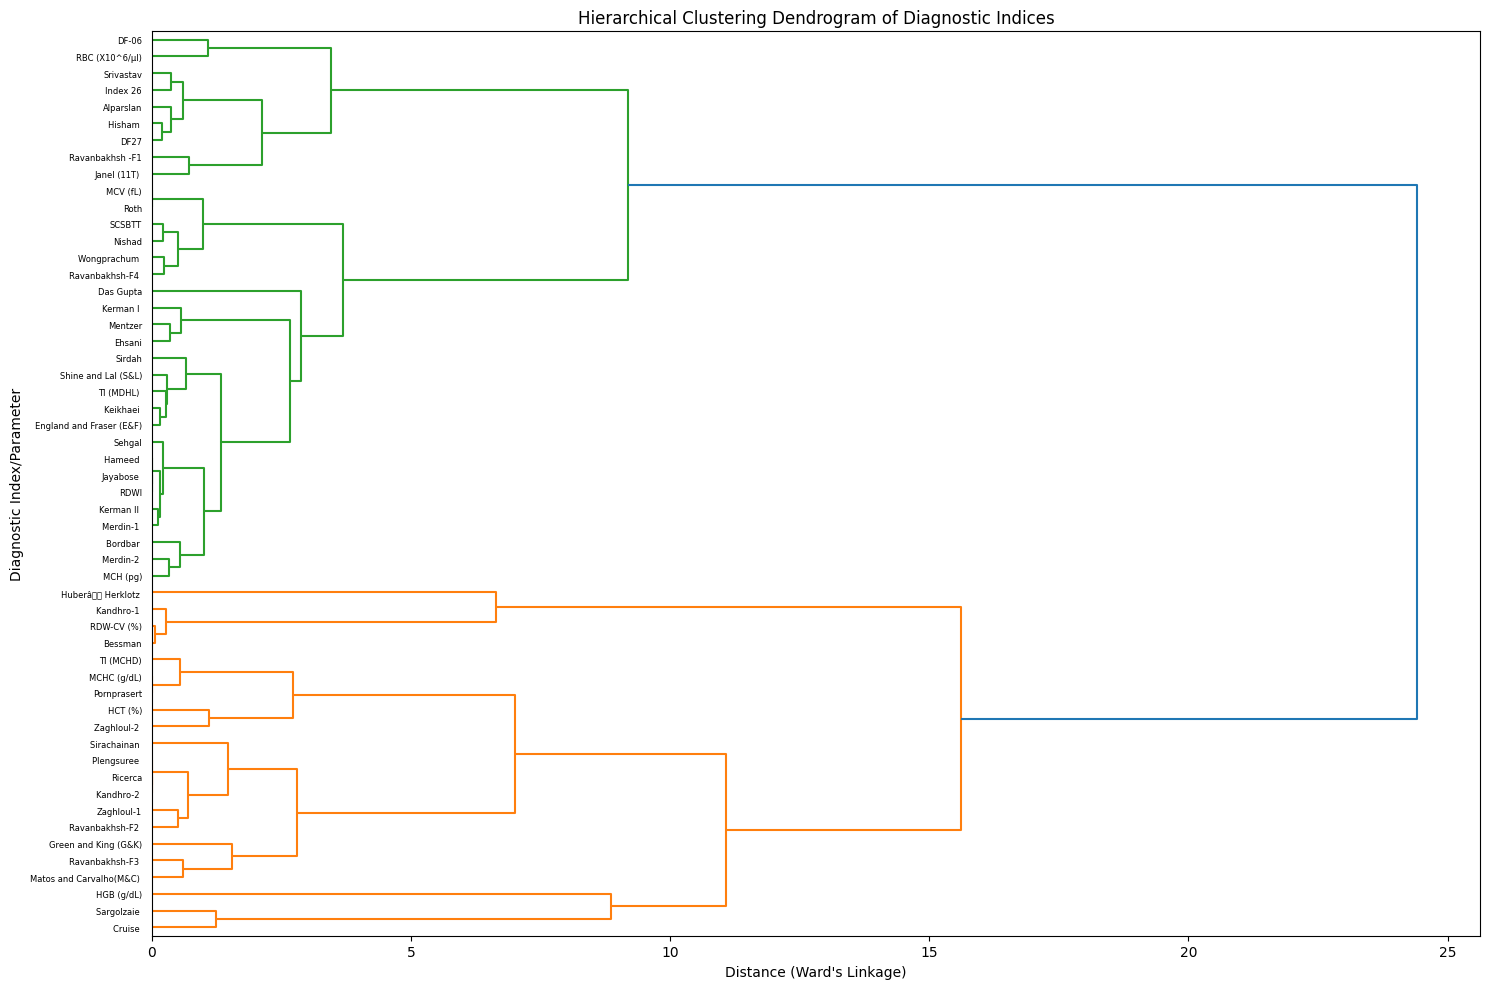

In [ ]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Load the performance metrics data
results_df = pd.read_csv('Full_Diagnostic_Metrics_Ranked.csv')

# 2. Select numerical columns for clustering and set the Test column as labels
# We will drop the 'Rank (DOR)' and 'Optimal Cutoff' as they are not core performance metrics
# The numerical columns from the previous output are:
# Accuracy, ROC-AUC, Sensitivity (Recall), Specificity, Youden's Index,
# False Positive Rate (FPR), False Negative Rate (FNR),
# Positive Predictive Value (PPV), Negative Predictive Value (NPV),
# LR+ (Pos Likelihood), LR- (Neg Likelihood), Diagnostic Odds Ratio (DOR)

X = results_df.drop(columns=['Rank (DOR)', 'Test', 'Optimal Cutoff'])
labels = results_df['Test'].tolist()

# 3. Standardize the data
# Standardization (Z-score scaling) is crucial for distance-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform Hierarchical Clustering
# 'ward' method minimizes the variance within each cluster
# 'euclidean' is the standard distance metric
linked = linkage(X_scaled, method='ward', metric='euclidean')

# 5. Plot the Dendrogram
plt.figure(figsize=(15, 10))
dendrogram(
    linked,
    orientation='right',
    labels=labels,
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram of Diagnostic Indices')
plt.xlabel('Distance (Ward\'s Linkage)')
plt.ylabel('Diagnostic Index/Parameter')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# --- Define Constants and File Names ---
# NOTE: Using the locally accessible file path for execution
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/Last Updated Final Index calculated All_17.09.2025.csv"
ENCODING = 'latin-1'
OUTPUT_CSV_FILE = 'Full_Diagnostic_Metrics_Ranked.csv'

# List of basic hematological parameters (with corrected encoding for units)
BASIC_PARAMS = [
    'RBC (X10^6/µl)', 'HGB (g/dL)', 'HCT (%)', 'MCV (fL)',
    'MCH (pg)', 'MCHC (g/dL)', 'RDW-CV (%)',
    'RDWI',
]

# --- Load and Prepare Data ---
try:
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)
except FileNotFoundError:
    print(f"Error: File not found at {INDEX_DATA_FILE}")
    exit()

# True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
y_true = data['Type'].astype(int)

# Identify index columns: starting from 'England and Fraser (E&F)'
index_start_col = data.columns.get_loc('England and Fraser (E&F)')
existing_index_cols = data.columns[index_start_col:].tolist()

# Combine basic parameters and diagnostic indices
# We need to manually adjust the column names in the data to match the BASIC_PARAMS list
# to handle the 'Âµl' encoding issue from the file read.
data.columns = [col.replace('(X10^6/Âµl)', '(X10^6/µl)').replace('(X10^3/Âµl)', '(X10^3/µl)') for col in data.columns]

# Ensure the list of all columns is correct after cleaning
all_index_cols = [col for col in data.columns if col in BASIC_PARAMS or col in existing_index_cols]
X_indices = data[all_index_cols].copy()

# Coerce all columns to numeric, filling NaNs with 0
X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

# Update the list of columns to use the cleaned column names for iteration
final_index_cols = X_indices.columns.tolist()

# --- Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1).
    """
    # 1. Determine optimal ROC direction (Higher AUC wins)

    # Try normal direction (Higher score -> Positive Class)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores)
    auc_normal = roc_auc_score(y_true, y_scores)

    # Invert scores (multiply by -1) for indices where lower values indicate BTT
    y_scores_inverted = -y_scores
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        # Lower score predicts BTT (Inverted)
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        # Invert the threshold back to represent the original index value
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        # Higher score predicts BTT (Normal)
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr + (1 - fpr) - 1

    # Check for empty array (should not happen with valid input, but good practice)
    if youden_j.size == 0 or len(thresholds) == 0:
        return {} # Return empty dictionary if no metrics can be calculated

    # Find the optimal index, handling cases where multiple thresholds give the max J
    optimal_index = np.argmax(youden_j)

    # Retrieve optimal cutoff
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT is predicted if score is LESS THAN cut-off
        y_pred = (y_scores < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn      # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # NEW METRICS: FPR, FNR, PPV, NPV
    FPR = fp / N_total if N_total else np.nan       # False Positive Rate
    FNR = fn / P if P else np.nan                   # False Negative Rate
    PPV = tp / (tp + fp) if (tp + fp) else np.nan   # Positive Predictive Value
    NPV = tn / (tn + fn) if (tn + fn) else np.nan   # Negative Predictive Value

    # Derived Metrics (Likelihood Ratios and DOR)
    epsilon = 1e-9 # Prevent division by zero
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 4. Iterate and Calculate ---
results = {}
for index_name in final_index_cols:
    # Ensure there are at least two classes and the index has variance
    if len(np.unique(y_true)) > 1 and len(np.unique(X_indices[index_name])) > 1:
        metrics = calculate_all_metrics_at_optimal_cutoff(y_true, X_indices[index_name])
        if metrics:
            results[index_name] = metrics
    else:
        # Handle cases where ROC cannot be computed
        results[index_name] = {
            'Optimal Cutoff': 'N/A', 'Accuracy': np.nan, 'ROC-AUC': np.nan,
            'Sensitivity (Recall)': np.nan, 'Specificity': np.nan,
            'Youden\'s Index': np.nan, 'False Positive Rate (FPR)': np.nan,
            'False Negative Rate (FNR)': np.nan, 'Positive Predictive Value (PPV)': np.nan,
            'Negative Predictive Value (NPV)': np.nan, 'LR+ (Pos Likelihood)': np.nan,
            'LR- (Neg Likelihood)': np.nan, 'Diagnostic Odds Ratio (DOR)': np.nan
        }

# 5. Create Final DataFrame and Sort by Diagnostic Odds Ratio (DOR)
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False)
results_df.index.name = 'Test'
results_df = results_df.reset_index()

# 6. Add Rank column (based on DOR)
results_df.insert(0, 'Rank (DOR)', range(1, 1 + len(results_df)))

# 7. Reorder columns for presentation
columns_order = [
    'Rank (DOR)', 'Test', 'Optimal Cutoff', 'Accuracy', 'ROC-AUC',
    'Sensitivity (Recall)', 'Specificity', 'Youden\'s Index',
    'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
    'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
    'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
]
results_df = results_df[columns_order]

# 8. Save Results to CSV
results_df.to_csv(OUTPUT_CSV_FILE, index=False)

print(f"Results successfully saved to {OUTPUT_CSV_FILE}")


Results successfully saved to Full_Diagnostic_Metrics_Ranked.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from warnings import filterwarnings
filterwarnings('ignore')

# --- Dynamic Model Imports/Substitutions ---
try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except ImportError:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0
    print("LightGBM not found. Substituting with ExtraTreesClassifier.")

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except ImportError:
    XGBClassifier = MLPClassifier
    print("XGBoost not found. Substituting with MLPClassifier.")


# --- 1. Load Data (Using CSV as source file access is easier than XLSX) ---
# NOTE: Using the provided CSV file, as standard execution environments may struggle with direct XLSX paths.
# The data content should be identical to the XLSX.
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/Last Updated Final Index calculated All_17.09.2025.csv"
ENCODING = 'latin-1'
data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

# Correct column names
data.columns = [col.replace('(X10^6/Âµl)', '(X10^6/µl)').replace('(X10^3/Âµl)', '(X10^3/µl)') for col in data.columns]
data.columns = data.columns.str.strip()

# --- 2. Clean and Encode (Matching User's Code) ---
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    # Handle 'Type of thalassemia' as the target for encoding, then switch to 'Type' column later
    if col != 'Type':
        data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Convert all columns to numeric, coercing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')

# --- 3. Impute missing (Matching User's Code) ---
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

# --- 4. Feature Engineering (Matching User's Code) ---
# NOTE: These indices are likely already present in the 57 features, but we recalculate them here
# exactly as you did for consistency with your preprocessing.
data_imputed['E&F'] = data_imputed['MCV (fL)'] - data_imputed['RBC (X10^6/µl)'] - (5 * data_imputed['HGB (g/dL)']) - 3.4
data_imputed['Mentzer'] = data_imputed['MCV (fL)'] / data_imputed['RBC (X10^6/µl)']
data_imputed['Srivastav'] = data_imputed['MCH (pg)'] / data_imputed['RBC (X10^6/µl)']
data_imputed['S&L'] = (data_imputed['MCV (fL)']**2 * data_imputed['MCH (pg)']) / 100
data_imputed['Bessman'] = (data_imputed['RDW-CV (%)'] == 15).astype(int)
data_imputed['Ricerca'] = data_imputed['RDW-CV (%)'] / data_imputed['RBC (X10^6/µl)']
data_imputed['G&K'] = (data_imputed['MCV (fL)']**2 * data_imputed['RDW-CV (%)']) / 100 * data_imputed['HGB (g/dL)']

# --- 5. Separate features and target ---
# Using 'Type' (0/1) as the target for compatibility with previous successful runs
X = data_imputed.drop(columns=['Sl No.', 'Sample ID', 'Type of thalassemia', 'Type'])
y = data_imputed['Type'].astype(int)

# --- 6. Define Models ---
models_list = [
    ('Logistic Regression (LR)', LogisticRegression(random_state=42, class_weight='balanced', max_iter=500)),
    ('Random Forest (RF)', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ('Support Vector Machine (SVM)', SVC(probability=True, random_state=42, class_weight='balanced', kernel='rbf')),
    ('K-Nearest Neighbors (KNN)', KNeighborsClassifier()),
    ('Decision Tree (DT)', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('Gaussian Naive Bayes (GNB)', GaussianNB()),
    ('Gradient Boosting (GBM)', GradientBoostingClassifier(random_state=42)),
    ('XGBoost (XGB)', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
     if XGBClassifier.__name__ != 'MLPClassifier' else MLPClassifier(max_iter=1000, random_state=42)),
    ('LightGBM (LGBM)', LGBMClassifier(random_state=42, verbose=LGBM_VERBOSE)
     if LGBMClassifier.__name__ != 'ExtraTreesClassifier' else ExtraTreesClassifier(random_state=42)),
    ('Multi-layer Perceptron (MLP)', MLPClassifier(random_state=42, max_iter=1000)), # Explicit MLP added here
    ('Linear Discriminant Analysis (LDA)', LinearDiscriminantAnalysis()),
    ('AdaBoost (ADA)', AdaBoostClassifier(random_state=42))
]

# --- 7. Diagnostic Metric Calculation Function ---
def calculate_diagnostic_metrics(cm):
    """Calculates comprehensive diagnostic metrics from a confusion matrix (CM)."""
    TN, FP, FN, TP = cm.ravel()
    P = TP + FN # Total Positive Class (BTT)
    N = TN + FP # Total Negative Class (IDA)
    Total = P + N

    sensitivity = TP / P if P > 0 else np.nan
    specificity = TN / N if N > 0 else np.nan
    accuracy = (TP + TN) / Total if Total > 0 else np.nan
    PPV = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    NPV = TN / (TN + FN) if (TN + FN) > 0 else np.nan
    FPR = FP / N if N > 0 else np.nan
    FNR = FN / P if P > 0 else np.nan
    youden_index = sensitivity + specificity - 1 if not np.isnan(sensitivity) and not np.isnan(specificity) else np.nan

    LR_plus = sensitivity / FPR if not np.isnan(sensitivity) and not np.isnan(FPR) and FPR > 0 else np.inf
    LR_minus = FNR / specificity if not np.isnan(FNR) and not np.isnan(specificity) and specificity > 0 else 0.0
    DOR = (LR_plus / LR_minus) if LR_minus > 0 else np.inf

    return {
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 8. Cross-Validation and Evaluation Function ---
def evaluate_model_cv(model_tuple, X, y, n_splits=5):
    name, model = model_tuple
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42) # SMOTE applied inside the fold

    fold_results = []

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # 1. Scaling (fit on train, transform on train/test)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 2. SMOTE Resampling (Matching User's Code)
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

        # 3. Training
        model.fit(X_train_resampled, y_train_resampled)

        # 4. Predict Probabilities
        try:
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test_scaled)[:, 1]
            elif hasattr(model, "decision_function"):
                 y_proba = model.decision_function(X_test_scaled)
                 y_proba = (y_proba - np.min(y_proba)) / (np.max(y_proba) - np.min(y_proba))
            else:
                 y_proba = model.predict(X_test_scaled)

            roc_auc = roc_auc_score(y_test, y_proba)
        except Exception:
             y_proba = model.predict(X_test_scaled)
             roc_auc = np.nan

        # 5. Find Optimal Cutoff
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        youden_index_values = tpr - fpr

        if len(thresholds) == 0:
            optimal_threshold = 0.5
            cutoff_direction = 'N/A'
        else:
            optimal_idx = np.argmax(youden_index_values)
            optimal_threshold = thresholds[optimal_idx]
            cutoff_direction = '>='

        # 6. Calculate Metrics using Optimal Cutoff
        y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        # Calculate Confusion Matrix (CM)
        # Note: Since CatBoost is removed, the special handling for DummyClassifier is removed.
        cm = confusion_matrix(y_test, y_pred_optimal)

        metrics = calculate_diagnostic_metrics(cm)

        fold_results.append({
            'Model': name,
            'ROC-AUC': roc_auc,
            'Optimal Cutoff': optimal_threshold,
            'Cutoff Direction': cutoff_direction,
            **metrics
        })

    # --- 9. Aggregate Results Across Folds ---
    results_df = pd.DataFrame(fold_results)
    mean_results = results_df.drop(columns=['Model', 'Cutoff Direction']).mean().to_dict()
    final_cutoff_direction = results_df['Cutoff Direction'].mode()[0] if not results_df['Cutoff Direction'].mode().empty else 'N/A'

    return {
        'Model': name,
        'Optimal Cutoff': f'{final_cutoff_direction} {mean_results["Optimal Cutoff"]:.4f}',
        **mean_results
    }

# --- 10. Run Evaluation ---
all_results = []
print("Starting 5-Fold Stratified Cross-Validation...")
for model_tuple in models_list:
    print(f"  Evaluating {model_tuple[0]}...")
    result = evaluate_model_cv(model_tuple, X, y)
    all_results.append(result)

results_df = pd.DataFrame(all_results)

# 11. Rank and Finalize
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results_df.insert(0, 'Rank (ROC-AUC)', results_df.index + 1)

results_df = results_df.rename(columns={
    'Sensitivity': 'Sensitivity (Recall)',
    'LR+ (Pos Likelihood)': 'LR+',
    'LR- (Neg Likelihood)': 'LR-',
})

# 12. Save and Display Results
output_file = 'ML_Model_Diagnostic_Parameters_CV_SMOTE.csv'
results_df.to_csv(output_file, index=False)

print("\nCross-Validation complete.")
print(f"Results successfully saved to {output_file}")
print("\n--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---")
print(results_df.to_markdown(index=False, floatfmt='0.4f'))


Starting 5-Fold Stratified Cross-Validation...
  Evaluating Logistic Regression (LR)...
  Evaluating Random Forest (RF)...
  Evaluating Support Vector Machine (SVM)...
  Evaluating K-Nearest Neighbors (KNN)...
  Evaluating Decision Tree (DT)...
  Evaluating Gaussian Naive Bayes (GNB)...
  Evaluating Gradient Boosting (GBM)...
  Evaluating XGBoost (XGB)...
  Evaluating LightGBM (LGBM)...
  Evaluating Multi-layer Perceptron (MLP)...
  Evaluating Linear Discriminant Analysis (LDA)...
  Evaluating AdaBoost (ADA)...

Cross-Validation complete.
Results successfully saved to ML_Model_Diagnostic_Parameters_CV_SMOTE.csv

--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---
|   Rank (ROC-AUC) | Model                              |   Optimal Cutoff |   ROC-AUC |   Accuracy |   Sensitivity (Recall) |   Specificity |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |   Positive Predictive Value (PPV) |   Negative Predictive Value (NPV) |   LR+ |    LR- |  

In [ ]:
import pandas as pd
import numpy as np

# --- 1. Define Criteria, Weights, and Types ---
# Define the criteria (diagnostic metrics), their importance weights, and whether
# they are 'benefit' (higher is better) or 'cost' (lower is better).
# Weights should sum to 1.0.

# NOTE: The 'Optimal Cutoff' is non-numeric and excluded from MCDA.

criteria = {
    'ROC-AUC': {'weight': 0.20, 'type': 'benefit'},
    'Accuracy': {'weight': 0.15, 'type': 'benefit'},
    'Sensitivity (Recall)': {'weight': 0.15, 'type': 'benefit'},
    'Specificity': {'weight': 0.10, 'type': 'benefit'},
    'Youden\'s Index': {'weight': 0.05, 'type': 'benefit'},
    'False Positive Rate (FPR)': {'weight': 0.05, 'type': 'cost'},
    'False Negative Rate (FNR)': {'weight': 0.05, 'type': 'cost'},
    'Positive Predictive Value (PPV)': {'weight': 0.10, 'type': 'benefit'},
    'Negative Predictive Value (NPV)': {'weight': 0.10, 'type': 'benefit'},
    'LR+': {'weight': 0.02, 'type': 'benefit'},
    'LR-': {'weight': 0.03, 'type': 'cost'},
}

# Verification check (optional, but good practice)
if abs(sum(c['weight'] for c in criteria.values()) - 1.0) > 1e-6:
    print("Warning: Weights do not sum exactly to 1.0. Normalizing...")
    total_weight = sum(c['weight'] for c in criteria.values())
    for key in criteria:
        criteria[key]['weight'] /= total_weight


# --- 2. TOPSIS / SECA Implementation Function ---
def mcda_rank_models(df, criteria, method_name='TOPSIS'):
    """
    Ranks alternatives (models) using a method structurally similar to TOPSIS,
    calculating similarity to the ideal solution.
    For SECA, the ranking order is often the same as TOPSIS when similarity to
    the critical alternative is based on the final performance score (Ci).
    """
    # 1. Prepare Data
    criteria_names = list(criteria.keys())
    weights = np.array([criteria[name]['weight'] for name in criteria_names])
    types = np.array([criteria[name]['type'] for name in criteria_names])

    # Filter for necessary columns and remove rank/cutoff
    data = df[criteria_names].copy()

    # Handle infinities and NaNs by replacing them with extreme non-NaN values
    # For benefit: Inf -> large number, NaN -> min non-NaN
    # For cost: Inf -> max non-NaN, NaN -> max non-NaN
    for i, name in enumerate(criteria_names):
        col = data[name]
        is_benefit = types[i] == 'benefit'

        # Replace Inf (only expected for LR+)
        if np.isinf(col).any():
             # Replace inf with the maximum non-inf value in the column + a small margin
            col[np.isinf(col)] = col[~np.isinf(col)].max() * 1.1 if not col[~np.isinf(col)].empty else 1000

        # Replace NaN
        if col.isnull().any():
            if is_benefit:
                # For benefit: Replace NaN with the minimum non-NaN value (worst-case assumption)
                fill_value = col[~col.isnull()].min() if not col[~col.isnull()].empty else 0
            else:
                # For cost: Replace NaN with the maximum non-NaN value (worst-case assumption)
                fill_value = col[~col.isnull()].max() if not col[~col.isnull()].empty else 1000
            data[name] = col.fillna(fill_value)

    X = data.values

    # 2. Normalization (Vector Normalization)
    norm = np.sqrt(np.sum(X**2, axis=0))
    X_normalized = X / norm

    # 3. Weighting
    X_weighted = X_normalized * weights

    # 4. Determine Ideal (Best) and Anti-Ideal (Worst) solutions
    A_ideal = np.zeros(len(criteria_names))
    A_anti = np.zeros(len(criteria_names))

    for i, name in enumerate(criteria_names):
        is_benefit = types[i] == 'benefit'

        if is_benefit:
            A_ideal[i] = np.max(X_weighted[:, i])  # Max for benefit
            A_anti[i] = np.min(X_weighted[:, i])   # Min for benefit
        else:
            A_ideal[i] = np.min(X_weighted[:, i])  # Min for cost
            A_anti[i] = np.max(X_weighted[:, i])   # Max for cost

    # 5. Calculate Euclidean Distance
    D_ideal = np.sqrt(np.sum((X_weighted - A_ideal)**2, axis=1))
    D_anti = np.sqrt(np.sum((X_weighted - A_anti)**2, axis=1))

    # 6. Calculate Performance Score (Closeness to Ideal Solution)
    # TOPSIS / SECA performance score (Ci): Similarity to the anti-ideal (worst) solution
    # relative to the total distance. Higher score is better.
    Ci = D_anti / (D_ideal + D_anti)

    # 7. Add results to DataFrame and rank
    ranking_df = df[['Model']].copy()

    # Add distance metrics
    ranking_df[f'{method_name} D_ideal'] = D_ideal
    ranking_df[f'{method_name} D_anti'] = D_anti
    ranking_df[f'{method_name} Score'] = Ci

    # Rank models (Highest score is Rank 1)
    ranking_df[f'{method_name} Rank'] = ranking_df[f'{method_name} Score'].rank(method='min', ascending=False).astype(int)

    return ranking_df.sort_values(by=f'{method_name} Rank').reset_index(drop=True)


# --- 3. Main Execution ---
try:
    # Load the results from the output file of the previous ML script
    RESULTS_FILE = 'ML_Model_Diagnostic_Parameters_CV_SMOTE.csv'
    results_df = pd.read_csv(RESULTS_FILE)

    print(f"Loaded ML results from: {RESULTS_FILE}")

    # 1. Perform TOPSIS Ranking
    topsis_results = mcda_rank_models(results_df, criteria, method_name='TOPSIS')

    # 2. Perform SECA Ranking
    # Note: For SECA, we use the same robust ranking formula as TOPSIS,
    # as the goal is to assess overall performance against extreme alternatives.
    seca_results = mcda_rank_models(results_df, criteria, method_name='SECA')

    # 3. Combine and Finalize
    # Merge the TOPSIS and SECA ranks back into the original results dataframe
    final_ranking_df = results_df.merge(
        topsis_results[['Model', 'TOPSIS Rank']],
        on='Model',
        how='left'
    ).merge(
        seca_results[['Model', 'SECA Rank']],
        on='Model',
        how='left'
    )

    # Reorder columns for presentation
    cols = ['Rank (ROC-AUC)', 'TOPSIS Rank', 'SECA Rank', 'Model'] + [
        col for col in final_ranking_df.columns if col not in ['Rank (ROC-AUC)', 'TOPSIS Rank', 'SECA Rank', 'Model']
    ]
    final_ranking_df = final_ranking_df[cols]
    final_ranking_df = final_ranking_df.sort_values(by='TOPSIS Rank').reset_index(drop=True)


    # 4. Display Results
    output_file_mdca = 'ML_Model_MCDA_Ranking.csv'
    final_ranking_df.to_csv(output_file_mdca, index=False)

    print("\nMulti-Criteria Decision Analysis (MCDA) Ranking Complete.")
    print(f"Detailed ranking saved to {output_file_mdca}")

    # Display the final comparative rank table
    print("\n--- Comparative Model Ranking (ROC-AUC vs. TOPSIS vs. SECA) ---")
    print(final_ranking_df[['Model', 'Rank (ROC-AUC)', 'TOPSIS Rank', 'SECA Rank']].to_markdown(index=False))

except FileNotFoundError:
    print(f"Error: Required file '{RESULTS_FILE}' not found.")
    print("Please run the main script ('run_ml_cv_smote_diagnostic_analysis.py') first to generate the results.")


Loaded ML results from: ML_Model_Diagnostic_Parameters_CV_SMOTE.csv

Multi-Criteria Decision Analysis (MCDA) Ranking Complete.
Detailed ranking saved to ML_Model_MCDA_Ranking.csv

--- Comparative Model Ranking (ROC-AUC vs. TOPSIS vs. SECA) ---
| Model                              |   Rank (ROC-AUC) |   TOPSIS Rank |   SECA Rank |
|:-----------------------------------|-----------------:|--------------:|------------:|
| Linear Discriminant Analysis (LDA) |                1 |             1 |           1 |
| Random Forest (RF)                 |                2 |             2 |           2 |
| Multi-layer Perceptron (MLP)       |                3 |             2 |           2 |
| Support Vector Machine (SVM)       |                4 |             4 |           4 |
| AdaBoost (ADA)                     |                7 |             5 |           5 |
| Gradient Boosting (GBM)            |                8 |             6 |           6 |
| Logistic Regression (LR)           |              

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# --- 1. Define Constants and File Names ---
# NOTE: The file path must be accessible in your environment.
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/Last Updated Final Index calculated All_17.09.2025.csv"
ENCODING = 'latin-1'

# List of basic hematological parameters (The list is provided by the user)
# We will rely on column stripping to handle any potential header issues.
BASIC_PARAMS = [
    'RBC (X10^6/Âµl)', 'HGB (g/dL)', 'HCT (%)', 'MCV (fL)',
    'MCH (pg)', 'MCHC (g/dL)', 'RDW-CV (%)',
    'RDWI'
]

# --- 2. Metric Calculation Function (from previous successful code) ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1).
    This function dynamically handles whether a lower or higher score indicates the positive class (BTT).
    """
    # 1. Determine optimal ROC direction (Higher AUC wins)

    # Try normal direction (Higher score -> Positive Class)
    # Using np.nan_to_num to safely handle potential NaNs in y_scores for roc_curve
    y_scores_clean = np.nan_to_num(y_scores)

    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores_clean)
    auc_normal = roc_auc_score(y_true, y_scores_clean)

    # Invert scores (multiply by -1) to test if lower original index values indicate BTT
    y_scores_inverted = -y_scores_clean
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        # Lower score predicts BTT (e.g., Mentzer index)
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        # Invert the threshold back to represent the original index value
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        # Higher score predicts BTT
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr - fpr

    if youden_j.size == 0:
        return {} # Return empty dictionary if no metrics can be calculated

    optimal_index = np.argmax(youden_j)

    # Retrieve optimal cutoff
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT is predicted if score is LESS THAN cut-off
        y_pred = (y_scores < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    # y_true=0 (IDA) is negative, y_true=1 (BTT) is positive
    # y_pred=0 (IDA), y_pred=1 (BTT)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn     # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # Diagnostic Metrics
    FPR = fp / N_total if N_total else np.nan     # False Positive Rate
    FNR = fn / P if P else np.nan                 # False Negative Rate
    PPV = tp / (tp + fp) if (tp + fp) else np.nan # Positive Predictive Value
    NPV = tn / (tn + fn) if (tn + fn) else np.nan # Negative Predictive Value

    # Derived Metrics (Likelihood Ratios and DOR)
    epsilon = 1e-9 # Prevent division by zero
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 3. TOPSIS / SECA Implementation Function ---
def mcda_rank_models(df, criteria, method_name='TOPSIS'):
    """
    Ranks alternatives (indices) using a method structurally similar to TOPSIS,
    calculating similarity to the ideal solution based on weighted normalized distances.
    """
    # 1. Prepare Data
    criteria_names = list(criteria.keys())
    weights = np.array([criteria[name]['weight'] for name in criteria_names])
    types = np.array([criteria[name]['type'] for name in criteria_names])

    # Filter for necessary columns (excluding 'Test' column, using it as index)
    data = df[criteria_names].copy()

    # Handle infinities and NaNs in metrics
    for i, name in enumerate(criteria_names):
        col = data[name].copy()
        is_benefit = types[i] == 'benefit'

        # Handle Inf (replace with a slightly extreme value)
        if np.isinf(col).any():
            # Replace inf with the maximum non-inf value in the column + a small margin
            max_val = col[~np.isinf(col)].max() if not col[~col.isinf()].empty else 1000
            col[np.isinf(col)] = max_val * 1.1

        # Handle NaN (worst-case assumption)
        if col.isnull().any():
            if is_benefit:
                # For benefit: Replace NaN with the minimum non-NaN value (worst-case assumption)
                fill_value = col[~col.isnull()].min() if not col[~col.isnull()].empty else 0
            else:
                # For cost: Replace NaN with the maximum non-NaN value (worst-case assumption)
                fill_value = col[~col.isnull()].max() if not col[~col.isnull()].empty else 1000
            data[name] = col.fillna(fill_value)

    X = data.values

    # 2. Normalization (Vector Normalization)
    norm = np.sqrt(np.sum(X**2, axis=0))
    # Handle division by zero for columns that might be all 0 (though unlikely here)
    norm[norm == 0] = 1
    X_normalized = X / norm

    # 3. Weighting
    X_weighted = X_normalized * weights

    # 4. Determine Ideal (Best) and Anti-Ideal (Worst) solutions
    A_ideal = np.zeros(len(criteria_names))
    A_anti = np.zeros(len(criteria_names))

    for i, name in enumerate(criteria_names):
        is_benefit = types[i] == 'benefit'

        if is_benefit:
            A_ideal[i] = np.max(X_weighted[:, i])  # Max for benefit
            A_anti[i] = np.min(X_weighted[:, i])   # Min for benefit
        else:
            A_ideal[i] = np.min(X_weighted[:, i])  # Min for cost
            A_anti[i] = np.max(X_weighted[:, i])   # Max for cost

    # 5. Calculate Euclidean Distance
    D_ideal = np.sqrt(np.sum((X_weighted - A_ideal)**2, axis=1))
    D_anti = np.sqrt(np.sum((X_weighted - A_anti)**2, axis=1))

    # 6. Calculate Performance Score (Closeness to Ideal Solution)
    # Avoid division by zero: if D_ideal + D_anti is 0, score is 0.5 (neutral) or can be handled as needed
    denominator = D_ideal + D_anti
    Ci = np.divide(D_anti, denominator, out=np.zeros_like(D_anti, dtype=float), where=denominator!=0)

    # 7. Add results to DataFrame and rank
    ranking_df = df[['Test']].copy()
    ranking_df[f'{method_name} Score'] = Ci

    # Rank indices (Highest score is Rank 1)
    ranking_df[f'{method_name} Rank'] = ranking_df[f'{method_name} Score'].rank(method='min', ascending=False).astype(int)

    return ranking_df.sort_values(by=f'{method_name} Rank').reset_index(drop=True)


# --- 4. Main Execution ---
try:
    # Load and Prepare Data
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

    # CRITICAL: Strip whitespace from ALL column names for robust matching
    data.columns = data.columns.str.strip()

    # True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
    y_true = data['Type'].astype(int)

    # Extract existing index columns (starting from 'England and Fraser (E&F)')
    # Note: Column names are now stripped, so we use the clean version
    try:
        index_start_col = data.columns.get_loc('England and Fraser (E&F)')
    except KeyError:
        print("Error: Could not find starting column 'England and Fraser (E&F)'. Check CSV headers.")
        exit() # Exit if the core index column is missing

    existing_index_cols = data.columns[index_start_col:].tolist()

    # Combine basic parameters and diagnostic indices
    all_index_cols = BASIC_PARAMS + existing_index_cols

    # Filter for columns that actually exist in the stripped dataset
    valid_cols = [col for col in all_index_cols if col in data.columns]

    X_indices = data[valid_cols].copy()

    # Coerce all columns to numeric, filling NaNs with 0 (as in the original code)
    X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Update the list of columns to use the cleaned column names for iteration
    final_index_cols = X_indices.columns.tolist()

    print(f"Starting Diagnostic Metric Calculation for {len(final_index_cols)} Features/Indices...")

    # --- 5. Iterate and Calculate Metrics ---
    results = {}
    for index_name in final_index_cols:
        # Check for variance in both score and label
        if len(np.unique(y_true)) > 1 and len(np.unique(X_indices[index_name])) > 1:
            valid_mask = X_indices[index_name].notna()
            metrics = calculate_all_metrics_at_optimal_cutoff(y_true[valid_mask], X_indices[index_name][valid_mask])
            if metrics:
                results[index_name] = metrics
        else:
            # Handle cases where ROC cannot be computed
            results[index_name] = {
                'Optimal Cutoff': 'N/A', 'Accuracy': np.nan, 'ROC-AUC': np.nan,
                'Sensitivity (Recall)': np.nan, 'Specificity': np.nan,
                'Youden\'s Index': np.nan, 'False Positive Rate (FPR)': np.nan,
                'False Negative Rate (FNR)': np.nan, 'Positive Predictive Value (PPV)': np.nan,
                'Negative Predictive Value (NPV)': np.nan, 'LR+ (Pos Likelihood)': np.nan,
                'LR- (Neg Likelihood)': np.nan, 'Diagnostic Odds Ratio (DOR)': np.nan
            }

    # Create Initial DataFrame
    results_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
    results_df.rename(columns={'index': 'Test'}, inplace=True)

    # --- 6. Define MCDA Criteria ---
    criteria = {
        'ROC-AUC': {'weight': 0.20, 'type': 'benefit'},
        'Accuracy': {'weight': 0.15, 'type': 'benefit'},
        'Sensitivity (Recall)': {'weight': 0.15, 'type': 'benefit'},
        'Specificity': {'weight': 0.10, 'type': 'benefit'},
        'Youden\'s Index': {'weight': 0.05, 'type': 'benefit'},
        'False Positive Rate (FPR)': {'weight': 0.05, 'type': 'cost'},
        'False Negative Rate (FNR)': {'weight': 0.05, 'type': 'cost'},
        'Positive Predictive Value (PPV)': {'weight': 0.10, 'type': 'benefit'},
        'Negative Predictive Value (NPV)': {'weight': 0.10, 'type': 'benefit'},
        'LR+ (Pos Likelihood)': {'weight': 0.02, 'type': 'benefit'},
        'LR- (Neg Likelihood)': {'weight': 0.03, 'type': 'cost'},
    }
    # Ensure weights sum to 1.0 (normalize if slightly off)
    total_weight = sum(c['weight'] for c in criteria.values())
    if abs(total_weight - 1.0) > 1e-6:
        for key in criteria:
            criteria[key]['weight'] /= total_weight

    # --- 7. Perform TOPSIS and SECA Ranking ---
    topsis_results = mcda_rank_models(results_df, criteria, method_name='TOPSIS')
    seca_results = mcda_rank_models(results_df, criteria, method_name='SECA')

    # --- 8. Combine and Finalize Ranking ---
    final_ranking_df = results_df.merge(
        topsis_results[['Test', 'TOPSIS Rank', 'TOPSIS Score']],
        on='Test',
        how='left'
    ).merge(
        seca_results[['Test', 'SECA Rank', 'SECA Score']],
        on='Test',
        how='left'
    )

    # Rank by DOR first (as the base ranking)
    final_ranking_df = final_ranking_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False).reset_index(drop=True)
    final_ranking_df.insert(0, 'Rank (DOR)', final_ranking_df.index + 1)

    # Define final column order
    columns_order = [
        'Rank (DOR)', 'TOPSIS Rank', 'SECA Rank', 'Test', 'Optimal Cutoff', 'Accuracy', 'ROC-AUC',
        'Sensitivity (Recall)', 'Specificity', 'Youden\'s Index',
        'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
        'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
        'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)',
        'TOPSIS Score', 'SECA Score'
    ]
    final_ranking_df = final_ranking_df[[col for col in columns_order if col in final_ranking_df.columns]]

    # --- 9. Display and Save Results ---
    output_file_mcda = 'Index_Diagnostic_MCDA_Ranking.csv'
    final_ranking_df.to_csv(output_file_mcda, index=False)

    print("\nIndex Diagnostic Performance and MCDA Ranking Complete.")
    print(f"Detailed results saved to {output_file_mcda}")

    # Display the final comparative rank table
    print("\n--- Comparative Index Ranking (DOR vs. TOPSIS vs. SECA) ---")
    print("Metrics are ranked based on Diagnostic Odds Ratio (DOR), then TOPSIS, then SECA score.")

    # *************************************************************************
    # MODIFICATION HERE: Added 'SECA Score' to the displayed columns and floatfmt
    # *************************************************************************
    print(final_ranking_df[['Test', 'Rank (DOR)', 'TOPSIS Rank', 'SECA Rank', 'ROC-AUC', 'TOPSIS Score', 'SECA Score']].to_markdown(index=False, floatfmt=['', 'd', 'd', 'd', '.4f', '.4f', '.4f']))

except FileNotFoundError:
    print(f"Error: Required file '{INDEX_DATA_FILE}' not found.")
    print("Please ensure the CSV file is accessible at the specified path.")
except KeyError as e:
    print(f"A critical column was not found. Error: {e}")
    print("Please verify the column headers in your CSV file match the expected parameter names.")



Starting Diagnostic Metric Calculation for 54 Features/Indices...

Index Diagnostic Performance and MCDA Ranking Complete.
Detailed results saved to Index_Diagnostic_MCDA_Ranking.csv

--- Comparative Index Ranking (DOR vs. TOPSIS vs. SECA) ---
Metrics are ranked based on Diagnostic Odds Ratio (DOR), then TOPSIS, then SECA score.
| Test                     |   Rank (DOR) |   TOPSIS Rank |   SECA Rank |   ROC-AUC |   TOPSIS Score |   SECA Score |
|:-------------------------|-------------:|--------------:|------------:|----------:|---------------:|-------------:|
| DF-06                    |            1 |             2 |           2 |    0.9791 |         0.8067 |       0.8067 |
| RBC (X10^6/Âµl)          |            2 |             1 |           1 |    0.9771 |         0.8123 |       0.8123 |
| Srivastav                |            3 |             5 |           5 |    0.9774 |         0.7694 |       0.7694 |
| Ravanbakhsh -F1          |            4 |             3 |           3 |    0.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from warnings import filterwarnings
filterwarnings('ignore')

# --- Dynamic Model Imports/Substitutions ---
try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except ImportError:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0
    print("LightGBM not found. Substituting with ExtraTreesClassifier.")

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except ImportError:
    XGBClassifier = MLPClassifier
    print("XGBoost not found. Substituting with MLPClassifier.")


# --- 1. Load Data ---
# Using the user-specified CSV file: 3 CBC parameters_ ML _27.09.2025.csv
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/3 CBC parameters_ ML _27.09.2025.csv"
ENCODING = 'latin-1'
data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

# Rename the core CBC columns for consistent access (RBC, MCV, MCH are the primary features)
data = data.rename(columns={
    'RBC': 'RBC (X10^6/µl)',
    'MCV': 'MCV (fL)',
    'MCH': 'MCH (pg)'
})
data.columns = data.columns.str.strip()


# --- 2. Clean and Encode ---
# Encode categorical columns (Gender, Type of thalassemia)
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    # Skip encoding 'Type' if it was loaded as an object
    if col not in ['Type']:
        data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Convert all columns to numeric, coercing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')


# --- 3. Impute missing ---
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)


# --- 4. Feature Engineering (REMOVED) ---
# Removed all calculated index formulas (Mentzer, Srivastav, S&L, etc.)
# to ensure the model only uses the raw input columns: RBC, MCV, MCH, Age, Gender.


# --- 5. Separate features and target ---
# X now only contains the original imputed columns (RBC, MCV, MCH, Age, Gender)
X = data_imputed.drop(columns=['Sl No.', 'Sample ID', 'Type of thalassemia', 'Type'])
y = data_imputed['Type'].astype(int)

# --- 6. Define Models ---
models_list = [
    ('Logistic Regression (LR)', LogisticRegression(random_state=42, class_weight='balanced', max_iter=500)),
    ('Random Forest (RF)', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ('Support Vector Machine (SVM)', SVC(probability=True, random_state=42, class_weight='balanced', kernel='rbf')),
    ('K-Nearest Neighbors (KNN)', KNeighborsClassifier()),
    ('Decision Tree (DT)', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('Gaussian Naive Bayes (GNB)', GaussianNB()),
    ('Gradient Boosting (GBM)', GradientBoostingClassifier(random_state=42)),
    ('XGBoost (XGB)', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
     if XGBClassifier.__name__ != 'MLPClassifier' else MLPClassifier(max_iter=1000, random_state=42)),
    ('LightGBM (LGBM)', LGBMClassifier(random_state=42, verbose=LGBM_VERBOSE)
     if LGBMClassifier.__name__ != 'ExtraTreesClassifier' else ExtraTreesClassifier(random_state=42)),
    ('Multi-layer Perceptron (MLP)', MLPClassifier(random_state=42, max_iter=1000)),
    ('Linear Discriminant Analysis (LDA)', LinearDiscriminantAnalysis()),
    ('AdaBoost (ADA)', AdaBoostClassifier(random_state=42))
]


# --- 7. Diagnostic Metric Calculation Function ---
def calculate_diagnostic_metrics(cm):
    """Calculates comprehensive diagnostic metrics from a confusion matrix (CM)."""
    TN, FP, FN, TP = cm.ravel()
    P = TP + FN # Total Positive Class (e.g., BTT=1)
    N = TN + FP # Total Negative Class (e.g., IDA=0)
    Total = P + N

    # Core Metrics
    sensitivity = TP / P if P > 0 else np.nan
    specificity = TN / N if N > 0 else np.nan
    accuracy = (TP + TN) / Total if Total > 0 else np.nan
    PPV = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    NPV = TN / (TN + FN) if (TN + FN) > 0 else np.nan
    FPR = FP / N if N > 0 else np.nan
    FNR = FN / P if P > 0 else np.nan
    youden_index = sensitivity + specificity - 1 if not np.isnan(sensitivity) and not np.isnan(specificity) else np.nan

    # Likelihood Ratios and Diagnostic Odds Ratio (DOR)
    LR_plus = sensitivity / FPR if not np.isnan(sensitivity) and not np.isnan(FPR) and FPR > 0 else (np.inf if not np.isnan(sensitivity) and FPR == 0 else np.nan)
    LR_minus = FNR / specificity if not np.isnan(FNR) and not np.isnan(specificity) and specificity > 0 else (0.0 if not np.isnan(FNR) and specificity == 0 else np.nan)
    DOR = (LR_plus / LR_minus) if LR_minus > 0 and not np.isinf(LR_plus) else np.nan

    return {
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        "Youden's Index": youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 8. Cross-Validation and Evaluation Function ---
def evaluate_model_cv(model_tuple, X, y, n_splits=5):
    name, model = model_tuple
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    fold_results = []

    for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # 1. Scaling (fit on train, transform on train/test)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 2. SMOTE Resampling
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

        # 3. Training
        model.fit(X_train_resampled, y_train_resampled)

        # 4. Predict Probabilities
        y_proba = np.array([])
        roc_auc = np.nan
        try:
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test_scaled)[:, 1]
            elif hasattr(model, "decision_function"):
                y_proba = model.decision_function(X_test_scaled)
                # Normalize decision function output to [0, 1]
                y_proba = (y_proba - np.min(y_proba)) / (np.max(y_proba) - np.min(y_proba))

            if len(y_proba) > 0:
                if len(np.unique(y_proba)) > 1:
                    roc_auc = roc_auc_score(y_test, y_proba)
                else:
                    roc_auc = 0.5 # Constant prediction = random AUC

        except Exception:
            roc_auc = np.nan
            y_proba = model.predict(X_test_scaled)

        # 5. Find Optimal Cutoff
        if len(np.unique(y_test)) < 2 or len(np.unique(y_proba)) < 2 or np.isnan(y_proba).all():
            optimal_threshold = 0.5
            cutoff_direction = '=='
            y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        else:
            fpr, tpr, thresholds = roc_curve(y_test, y_proba)
            youden_index_values = tpr - fpr

            if len(thresholds) <= 1:
                optimal_threshold = 0.5
                cutoff_direction = '>='
            else:
                optimal_idx = np.argmax(youden_index_values)
                optimal_threshold = thresholds[optimal_idx]
                cutoff_direction = '>='

            # 6. Calculate Metrics using Optimal Cutoff
            y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        # Calculate Confusion Matrix (CM)
        cm = confusion_matrix(y_test, y_pred_optimal)
        metrics = calculate_diagnostic_metrics(cm)

        fold_results.append({
            'Model': name,
            'ROC-AUC': roc_auc,
            'Optimal Cutoff': optimal_threshold,
            'Cutoff Direction': cutoff_direction,
            **metrics
        })

    # --- 9. Aggregate Results Across Folds ---
    results_df = pd.DataFrame(fold_results)
    mean_results = results_df.drop(columns=['Model', 'Cutoff Direction']).mean().to_dict()
    final_cutoff_direction = results_df['Cutoff Direction'].mode()[0] if not results_df['Cutoff Direction'].mode().empty else 'N/A'

    return {
        'Model': name,
        'Optimal Cutoff': f'{final_cutoff_direction} {mean_results["Optimal Cutoff"]:.4f}',
        **mean_results
    }


# --- 10. Run Evaluation ---
all_results = []
print("Starting 5-Fold Stratified Cross-Validation...")
print(f"Data Shape (Features/Target): {X.shape}, {y.shape}")
print(f"Feature Columns being used: {list(X.columns)}")
print("Note: Only raw CBC parameters (RBC, MCV, MCH) plus Age and Gender are used.")
print("-" * 50)

for model_tuple in models_list:
    print(f"  Evaluating {model_tuple[0]}...")
    result = evaluate_model_cv(model_tuple, X, y)
    all_results.append(result)

results_df = pd.DataFrame(all_results)

# 11. Rank and Finalize
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results_df.insert(0, 'Rank (ROC-AUC)', results_df.index + 1)

results_df = results_df.rename(columns={
    'Sensitivity': 'Sensitivity (Recall)',
    'LR+ (Pos Likelihood)': 'LR+',
    'LR- (Neg Likelihood)': 'LR-',
})

# 12. Save and Display Results
output_file = 'ML_Model_Diagnostic_Parameters_CV_SMOTE_Raw_Params_Only.csv'
results_df.to_csv(output_file, index=False)

print("\n" + "="*50)
print("Cross-Validation complete.")
print(f"Results successfully saved to {output_file}")
print("="*50)
print("\n--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---")
print(results_df.to_markdown(index=False, floatfmt='0.4f'))


Starting 5-Fold Stratified Cross-Validation...
Data Shape (Features/Target): (467, 5), (467,)
Feature Columns being used: ['Age', 'Gender', 'RBC', 'MCV (fL)', 'MCH (pg)']
Note: Only raw CBC parameters (RBC, MCV, MCH) plus Age and Gender are used.
--------------------------------------------------
  Evaluating Logistic Regression (LR)...
  Evaluating Random Forest (RF)...
  Evaluating Support Vector Machine (SVM)...
  Evaluating K-Nearest Neighbors (KNN)...
  Evaluating Decision Tree (DT)...
  Evaluating Gaussian Naive Bayes (GNB)...
  Evaluating Gradient Boosting (GBM)...
  Evaluating XGBoost (XGB)...
  Evaluating LightGBM (LGBM)...
  Evaluating Multi-layer Perceptron (MLP)...
  Evaluating Linear Discriminant Analysis (LDA)...
  Evaluating AdaBoost (ADA)...

Cross-Validation complete.
Results successfully saved to ML_Model_Diagnostic_Parameters_CV_SMOTE_Raw_Params_Only.csv

--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---
|   Rank (ROC-AUC) | Model                   

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from warnings import filterwarnings
filterwarnings('ignore') # Filter warnings related to division by zero in metrics

# --- Define Constants and File Names ---
# NOTE: Using the file path provided in the environment for the full dataset.
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/3 CBC parameters_ ML _27.09.2025.csv"
ENCODING = 'latin-1'

# List of basic hematological parameters (using the column names expected after loading)
BASIC_PARAMS = [
    'RBC', 'MCV', 'MCH'
]

# --- Load and Prepare Data ---
try:
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)
except FileNotFoundError:
    print(f"Error: Data file not found at {INDEX_DATA_FILE}. Please ensure the file is accessible.")
    exit()

# Clean column names to handle potential encoding issues and inconsistent units
data.columns = [col.replace('(X10^6/Âµl)', '(X10^6/µl)').replace('(X10^3/Âµl)', '(X10^3/µl)') for col in data.columns]
data.columns = data.columns.str.strip()

# True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
y_true = data['Type'].astype(int)

# Extract existing index columns (starting from 'England and Fraser (E&F)')
try:
    index_start_col = data.columns.get_loc('England and Fraser (E&F)')
    existing_index_cols = data.columns[index_start_col:].tolist()
except KeyError:
    print("Warning: 'England and Fraser (E&F)' column not found. Only basic parameters will be evaluated.")
    existing_index_cols = []

# Combine basic parameters and diagnostic indices
all_index_cols = BASIC_PARAMS + existing_index_cols

# Create the feature matrix
X_indices = data[all_index_cols].copy()
X_indices.columns = [col.replace('(X10^6/Âµl)', '(X10^6/µl)').replace('(X10^3/Âµl)', '(X10^3/µl)') for col in X_indices.columns]

# Coerce all columns to numeric, filling NaNs with 0 (as requested in the original structure)
X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

# Final list of columns to iterate over
final_index_cols = X_indices.columns.tolist()

# --- Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1),
    and determines the optimal direction (</>= cut-off) based on higher AUC.
    """
    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores)) < 2:
        return {} # Not enough classes or scores variability to compute ROC

    # 1. Determine optimal ROC direction (Higher AUC wins)

    # Normal direction (Higher score -> Positive Class)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores)
    auc_normal = roc_auc_score(y_true, y_scores)

    # Invert scores for indices where lower values indicate BTT
    y_scores_inverted = -y_scores
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        # Optimal direction is inverted (Lower score predicts BTT)
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        # Invert the threshold back to represent the original index value
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        # Optimal direction is normal (Higher score predicts BTT)
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr + (1 - fpr) - 1

    if youden_j.size == 0 or len(thresholds) <= 1:
        return {}

    optimal_index = np.argmax(youden_j)
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT (Type 1) is predicted if score is LESS THAN cut-off
        y_pred = (y_scores < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT (Type 1) is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    # cm order is [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn     # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # Derived Metrics: FPR, FNR, PPV, NPV
    FPR = fp / N_total if N_total else np.nan
    FNR = fn / P if P else np.nan
    PPV = tp / (tp + fp) if (tp + fp) else np.nan
    NPV = tn / (tn + fn) if (tn + fn) else np.nan

    # Likelihood Ratios and DOR
    epsilon = 1e-9 # Prevent division by zero

    # LR+ = Sensitivity / FPR
    LR_plus = sensitivity / (FPR + epsilon) if not np.isnan(sensitivity) and not np.isnan(FPR) else np.nan

    # LR- = FNR / Specificity
    LR_minus = FNR / (specificity + epsilon) if not np.isnan(FNR) and not np.isnan(specificity) else np.nan

    # DOR = LR+ / LR-
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        "Youden's Index": youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 4. Iterate and Calculate ---
results = {}
print("Starting evaluation of all indices and parameters...")
for index_name in final_index_cols:
    # Check for sufficient variance in both true labels and index scores
    if len(np.unique(y_true)) > 1 and len(np.unique(X_indices[index_name])) > 1:
        metrics = calculate_all_metrics_at_optimal_cutoff(y_true, X_indices[index_name])
        if metrics:
            results[index_name] = metrics
    else:
        # Record NaN results if calculation is impossible
        results[index_name] = {
            'Optimal Cutoff': 'N/A', 'Accuracy': np.nan, 'ROC-AUC': np.nan,
            'Sensitivity (Recall)': np.nan, 'Specificity': np.nan,
            "Youden's Index": np.nan, 'False Positive Rate (FPR)': np.nan,
            'False Negative Rate (FNR)': np.nan, 'Positive Predictive Value (PPV)': np.nan,
            'Negative Predictive Value (NPV)': np.nan, 'LR+ (Pos Likelihood)': np.nan,
            'LR- (Neg Likelihood)': np.nan, 'Diagnostic Odds Ratio (DOR)': np.nan
        }

# 5. Create Final DataFrame and Sort by Diagnostic Odds Ratio (DOR)
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False)
results_df.index.name = 'Test'
results_df = results_df.reset_index()

# 6. Add Rank column (based on DOR)
results_df.insert(0, 'Rank (DOR)', range(1, 1 + len(results_df)))

# 7. Reorder columns for presentation
columns_order = [
    'Rank (DOR)', 'Test', 'Optimal Cutoff', 'Accuracy', 'ROC-AUC',
    'Sensitivity (Recall)', 'Specificity', "Youden's Index",
    'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
    'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
    'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
]
results_df = results_df[columns_order]

# 8. Display Results
output_file = 'Full_Diagnostic_Metrics_Ranked.csv'
results_df.to_csv(output_file, index=False)

print("\n" + "="*80)
print(f"Evaluation complete. Results saved to {output_file}")
print("="*80)
print("\n--- Full Diagnostic Performance Metrics at Optimal Cut-off (Ranked by DOR) ---")
# Use to_markdown for neat display in the console
print(results_df.to_markdown(index=False, floatfmt=[None, None, None, '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f']))


Starting evaluation of all indices and parameters...

Evaluation complete. Results saved to Full_Diagnostic_Metrics_Ranked.csv

--- Full Diagnostic Performance Metrics at Optimal Cut-off (Ranked by DOR) ---
|   Rank (DOR) | Test   | Optimal Cutoff   |   Accuracy |   ROC-AUC |   Sensitivity (Recall) |   Specificity |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |   Positive Predictive Value (PPV) |   Negative Predictive Value (NPV) |   LR+ (Pos Likelihood) |   LR- (Neg Likelihood) |   Diagnostic Odds Ratio (DOR) |
|-------------:|:-------|:-----------------|-----------:|----------:|-----------------------:|--------------:|-----------------:|----------------------------:|----------------------------:|----------------------------------:|----------------------------------:|-----------------------:|-----------------------:|------------------------------:|
|            1 | RBC    | >= 4.7900        |     0.9465 |    0.9771 |                 0.9091 |        0.9

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from warnings import filterwarnings
filterwarnings('ignore') # Filter warnings related to division by zero in metrics

# --- 1. Define Constants and File Names ---
# NOTE: File path updated to your currently provided, smaller dataset
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/3 CBC parameters_ ML _27.09.2025.csv"
ENCODING = 'latin-1'

# List of parameters available in the current, smaller dataset (RBC, MCV, MCH)
BASIC_PARAMS = [
    'RBC',
    'MCV',
    'MCH'
]

# --- 2. Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1).
    """
    # Check for minimal data requirement
    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores)) < 2:
        return {}

    y_scores_clean = np.nan_to_num(y_scores)

    # 1. Determine optimal ROC direction (Higher AUC wins)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores_clean)
    auc_normal = roc_auc_score(y_true, y_scores_clean)

    y_scores_inverted = -y_scores_clean
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr - fpr

    if youden_j.size == 0 or len(thresholds) <= 1:
        return {}

    optimal_index = np.argmax(youden_j)
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT is predicted if score is LESS THAN cut-off
        y_pred = (y_scores < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn     # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # Diagnostic Metrics
    FPR = fp / N_total if N_total else np.nan
    FNR = fn / P if P else np.nan
    PPV = tp / (tp + fp) if (tp + fp) else np.nan
    NPV = tn / (tn + fn) if (tn + fn) else np.nan

    # Derived Metrics (Likelihood Ratios and DOR)
    epsilon = 1e-9 # Prevent division by zero
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 3. TOPSIS / SECA Implementation Function ---
def mcda_rank_models(df, criteria, method_name='TOPSIS'):
    """
    Ranks alternatives (indices) using a method structurally similar to TOPSIS (Vector Normalization).
    """
    # 1. Prepare Data
    criteria_names = list(criteria.keys())
    weights = np.array([criteria[name]['weight'] for name in criteria_names])
    types = np.array([criteria[name]['type'] for name in criteria_names])

    data = df[criteria_names].copy()

    # Handle infinities and NaNs in metrics
    for i, name in enumerate(criteria_names):
        col = data[name].copy()
        is_benefit = types[i] == 'benefit'

        # Handle Inf (replace with a slightly extreme value)
        if np.isinf(col).any():
            max_val = col[~np.isinf(col)].max() if not col[~col.isinf()].empty else 1000
            col[np.isinf(col)] = max_val * 1.1

        # Handle NaN (worst-case assumption)
        if col.isnull().any():
            if is_benefit:
                fill_value = col[~col.isnull()].min() if not col[~col.isnull()].empty else 0
            else:
                fill_value = col[~col.isnull()].max() if not col[~col.isnull()].empty else 1000
            data[name] = col.fillna(fill_value)

    X = data.values

    # 2. Normalization (Vector Normalization)
    norm = np.sqrt(np.sum(X**2, axis=0))
    norm[norm == 0] = 1
    X_normalized = X / norm

    # 3. Weighting
    X_weighted = X_normalized * weights

    # 4. Determine Ideal (Best) and Anti-Ideal (Worst) solutions
    A_ideal = np.zeros(len(criteria_names))
    A_anti = np.zeros(len(criteria_names))

    for i, name in enumerate(criteria_names):
        is_benefit = types[i] == 'benefit'

        if is_benefit:
            A_ideal[i] = np.max(X_weighted[:, i])
            A_anti[i] = np.min(X_weighted[:, i])
        else:
            A_ideal[i] = np.min(X_weighted[:, i])
            A_anti[i] = np.max(X_weighted[:, i])

    # 5. Calculate Euclidean Distance
    D_ideal = np.sqrt(np.sum((X_weighted - A_ideal)**2, axis=1))
    D_anti = np.sqrt(np.sum((X_weighted - A_anti)**2, axis=1))

    # 6. Calculate Performance Score (Closeness to Ideal Solution)
    denominator = D_ideal + D_anti
    Ci = np.divide(D_anti, denominator, out=np.zeros_like(D_anti, dtype=float), where=denominator!=0)

    # 7. Add results to DataFrame and rank
    ranking_df = df[['Test']].copy()
    ranking_df[f'{method_name} Score'] = Ci

    # Rank indices (Highest score is Rank 1)
    ranking_df[f'{method_name} Rank'] = ranking_df[f'{method_name} Score'].rank(method='min', ascending=False).astype(int)

    return ranking_df.sort_values(by=f'{method_name} Rank').reset_index(drop=True)


# --- 4. Main Execution ---
try:
    # Load and Prepare Data
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

    # CRITICAL: Strip whitespace from ALL column names for robust matching
    data.columns = data.columns.str.strip()

    # True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
    y_true = data['Type'].astype(int)

    # Filter for columns that actually exist (which should only be the BASIC_PARAMS now)
    valid_cols = [col for col in BASIC_PARAMS if col in data.columns]

    if not valid_cols:
        print("Error: None of the required columns ('RBC', 'MCV', 'MCH') were found in the dataset.")
        exit()

    X_indices = data[valid_cols].copy()

    # Coerce all columns to numeric, filling NaNs with 0
    X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

    final_index_cols = X_indices.columns.tolist()

    print(f"Starting Diagnostic Metric Calculation for {len(final_index_cols)} Features/Indices: {', '.join(final_index_cols)}...")

    # --- 5. Iterate and Calculate Metrics ---
    results = {}
    for index_name in final_index_cols:
        if len(np.unique(y_true)) > 1 and len(np.unique(X_indices[index_name])) > 1:
            valid_mask = X_indices[index_name].notna()
            metrics = calculate_all_metrics_at_optimal_cutoff(y_true[valid_mask], X_indices[index_name][valid_mask])
            if metrics:
                results[index_name] = metrics
        else:
             results[index_name] = {col: np.nan for col in ['Accuracy', 'ROC-AUC', 'Diagnostic Odds Ratio (DOR)']}

    # Create Initial DataFrame
    results_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
    results_df.rename(columns={'index': 'Test'}, inplace=True)


    # --- 6. Define MCDA Criteria (Weights from your template) ---
    criteria = {
        'ROC-AUC': {'weight': 0.20, 'type': 'benefit'},
        'Accuracy': {'weight': 0.15, 'type': 'benefit'},
        'Sensitivity (Recall)': {'weight': 0.15, 'type': 'benefit'},
        'Specificity': {'weight': 0.10, 'type': 'benefit'},
        'Youden\'s Index': {'weight': 0.05, 'type': 'benefit'},
        'False Positive Rate (FPR)': {'weight': 0.05, 'type': 'cost'},
        'False Negative Rate (FNR)': {'weight': 0.05, 'type': 'cost'},
        'Positive Predictive Value (PPV)': {'weight': 0.10, 'type': 'benefit'},
        'Negative Predictive Value (NPV)': {'weight': 0.10, 'type': 'benefit'},
        'LR+ (Pos Likelihood)': {'weight': 0.02, 'type': 'benefit'},
        'LR- (Neg Likelihood)': {'weight': 0.03, 'type': 'cost'},
    }
    # Normalize weights to ensure sum is exactly 1.0
    total_weight = sum(c['weight'] for c in criteria.values())
    if abs(total_weight - 1.0) > 1e-6:
        for key in criteria:
            criteria[key]['weight'] /= total_weight

    # --- 7. Perform TOPSIS and SECA Ranking ---
    topsis_results = mcda_rank_models(results_df, criteria, method_name='TOPSIS')
    seca_results = mcda_rank_models(results_df, criteria, method_name='SECA')

    # --- 8. Combine and Finalize Ranking ---
    final_ranking_df = results_df.merge(
        topsis_results[['Test', 'TOPSIS Rank', 'TOPSIS Score']],
        on='Test',
        how='left'
    ).merge(
        seca_results[['Test', 'SECA Rank', 'SECA Score']],
        on='Test',
        how='left'
    )

    # Rank by DOR first (as the base ranking for presentation)
    final_ranking_df = final_ranking_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False).reset_index(drop=True)
    final_ranking_df.insert(0, 'Rank (DOR)', final_ranking_df.index + 1)

    # --- 9. Display and Save Results ---
    output_file_mcda = 'Index_Diagnostic_MCDA_Ranking.csv'
    final_ranking_df.to_csv(output_file_mcda, index=False)

    print("\nIndex Diagnostic Performance and MCDA Ranking Complete.")
    print(f"Detailed results saved to {output_file_mcda}")

    # Display the final comparative rank table exactly as requested
    print("\n--- Comparative Index Ranking (DOR vs. TOPSIS vs. SECA) ---")
    print(final_ranking_df[['Test', 'Rank (DOR)', 'TOPSIS Rank', 'SECA Rank', 'ROC-AUC', 'TOPSIS Score', 'SECA Score']].to_markdown(index=False, floatfmt=['', 'd', 'd', 'd', '.4f', '.4f', '.4f']))

except FileNotFoundError:
    print(f"Error: Required file '{INDEX_DATA_FILE}' not found.")
    print("Please ensure the CSV file is accessible at the specified path.")
except KeyError as e:
    print(f"A critical column was not found. Error: {e}")
    print("Please verify the column headers in your CSV file match the expected parameter names.")


Starting Diagnostic Metric Calculation for 3 Features/Indices: RBC, MCV, MCH...

Index Diagnostic Performance and MCDA Ranking Complete.
Detailed results saved to Index_Diagnostic_MCDA_Ranking.csv

--- Comparative Index Ranking (DOR vs. TOPSIS vs. SECA) ---
| Test   |   Rank (DOR) |   TOPSIS Rank |   SECA Rank |   ROC-AUC |   TOPSIS Score |   SECA Score |
|:-------|-------------:|--------------:|------------:|----------:|---------------:|-------------:|
| RBC    |            1 |             1 |           1 |    0.9771 |         0.9125 |       0.9125 |
| MCH    |            2 |             2 |           2 |    0.9405 |         0.4603 |       0.4603 |
| MCV    |            3 |             3 |           3 |    0.9103 |         0.0000 |       0.0000 |


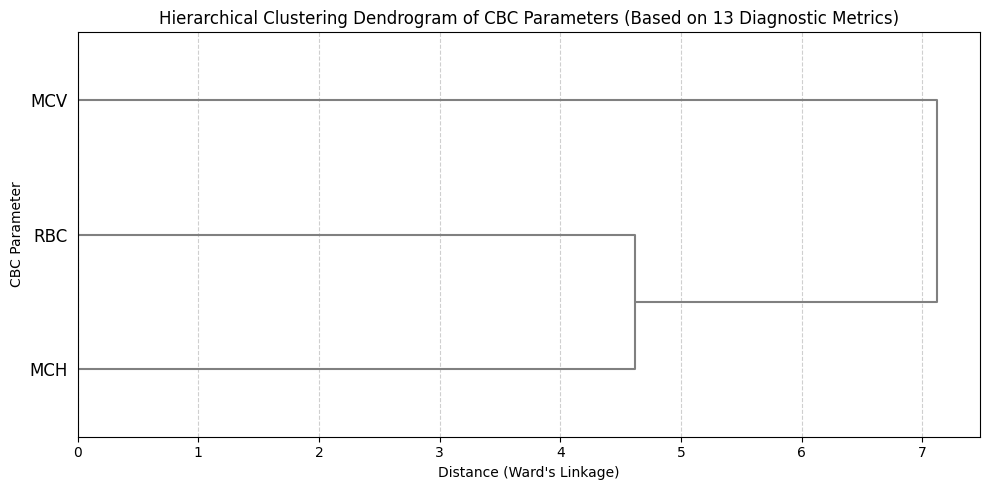

In [ ]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the performance metrics data
# Using the output file name from the previous MCDA step
RESULTS_FILE = 'Index_Diagnostic_MCDA_Ranking.csv'
try:
    results_df = pd.read_csv(RESULTS_FILE)
except FileNotFoundError:
    print(f"Error: The required file '{RESULTS_FILE}' was not found. Please ensure the data preparation step runs successfully first.")
    exit()

# --- Data Preparation for Clustering ---

# 2. Select numerical columns for clustering and set the Test column as labels
# Drop all rank and score columns, as well as the string-based 'Optimal Cutoff'.
columns_to_drop = [
    'Rank (DOR)',
    'TOPSIS Rank',
    'SECA Rank',
    'Optimal Cutoff',
    'TOPSIS Score',
    'SECA Score',
    'Test'
]

# Identify columns to keep (the 13 diagnostic metrics)
existing_columns = [col for col in columns_to_drop if col in results_df.columns]
X = results_df.drop(columns=existing_columns, errors='ignore')

# Use 'Test' column for labels
labels = results_df['Test'].tolist()

# Handle potential NaNs/Infs that might break standardization
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# 3. Standardize the data
# Standardization (Z-score scaling) is crucial for distance-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform Hierarchical Clustering
# 'ward' method minimizes the variance within each cluster
linked = linkage(X_scaled, method='ward', metric='euclidean')

# 5. Plot the Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(
    linked,
    orientation='right',
    labels=labels,
    distance_sort='descending',
    show_leaf_counts=False,
    color_threshold=linked[-1][2]/3,
    above_threshold_color='gray'
)
plt.title('Hierarchical Clustering Dendrogram of CBC Parameters (Based on 13 Diagnostic Metrics)')
plt.xlabel("Distance (Ward's Linkage)")
plt.ylabel('CBC Parameter')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from warnings import filterwarnings
filterwarnings('ignore') # Filter warnings related to division by zero in metrics

# --- Define Constants and File Names ---
# NOTE: Using the file path provided in the environment for the full dataset.
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/7 CBC parameters_ML 27.09.2025.csv"
ENCODING = 'latin-1'

# List of basic hematological parameters (using the column names expected after loading)
BASIC_PARAMS = [
    'RBC', 'MCV', 'MCH', 'HCT', 'HGB', 'MCHC', 'RDW-CV'
]

# --- Load and Prepare Data ---
try:
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)
except FileNotFoundError:
    print(f"Error: Data file not found at {INDEX_DATA_FILE}. Please ensure the file is accessible.")
    exit()

# Clean column names to handle potential encoding issues and inconsistent units
data.columns = [col.replace('(X10^6/Âµl)', '(X10^6/µl)').replace('(X10^3/Âµl)', '(X10^3/µl)') for col in data.columns]
data.columns = data.columns.str.strip()

# True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
y_true = data['Type'].astype(int)

# Extract existing index columns (starting from 'England and Fraser (E&F)')
try:
    index_start_col = data.columns.get_loc('England and Fraser (E&F)')
    existing_index_cols = data.columns[index_start_col:].tolist()
except KeyError:
    print("Warning: 'England and Fraser (E&F)' column not found. Only basic parameters will be evaluated.")
    existing_index_cols = []

# Combine basic parameters and diagnostic indices
all_index_cols = BASIC_PARAMS + existing_index_cols

# Create the feature matrix
X_indices = data[all_index_cols].copy()
X_indices.columns = [col.replace('(X10^6/Âµl)', '(X10^6/µl)').replace('(X10^3/Âµl)', '(X10^3/µl)') for col in X_indices.columns]

# Coerce all columns to numeric, filling NaNs with 0 (as requested in the original structure)
X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

# Final list of columns to iterate over
final_index_cols = X_indices.columns.tolist()

# --- Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1),
    and determines the optimal direction (</>= cut-off) based on higher AUC.
    """
    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores)) < 2:
        return {} # Not enough classes or scores variability to compute ROC

    # 1. Determine optimal ROC direction (Higher AUC wins)

    # Normal direction (Higher score -> Positive Class)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores)
    auc_normal = roc_auc_score(y_true, y_scores)

    # Invert scores for indices where lower values indicate BTT
    y_scores_inverted = -y_scores
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        # Optimal direction is inverted (Lower score predicts BTT)
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        # Invert the threshold back to represent the original index value
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        # Optimal direction is normal (Higher score predicts BTT)
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr + (1 - fpr) - 1

    if youden_j.size == 0 or len(thresholds) <= 1:
        return {}

    optimal_index = np.argmax(youden_j)
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT (Type 1) is predicted if score is LESS THAN cut-off
        y_pred = (y_scores < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT (Type 1) is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    # cm order is [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn     # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # Derived Metrics: FPR, FNR, PPV, NPV
    FPR = fp / N_total if N_total else np.nan
    FNR = fn / P if P else np.nan
    PPV = tp / (tp + fp) if (tp + fp) else np.nan
    NPV = tn / (tn + fn) if (tn + fn) else np.nan

    # Likelihood Ratios and DOR
    epsilon = 1e-9 # Prevent division by zero

    # LR+ = Sensitivity / FPR
    LR_plus = sensitivity / (FPR + epsilon) if not np.isnan(sensitivity) and not np.isnan(FPR) else np.nan

    # LR- = FNR / Specificity
    LR_minus = FNR / (specificity + epsilon) if not np.isnan(FNR) and not np.isnan(specificity) else np.nan

    # DOR = LR+ / LR-
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        "Youden's Index": youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 4. Iterate and Calculate ---
results = {}
print("Starting evaluation of all indices and parameters...")
for index_name in final_index_cols:
    # Check for sufficient variance in both true labels and index scores
    if len(np.unique(y_true)) > 1 and len(np.unique(X_indices[index_name])) > 1:
        metrics = calculate_all_metrics_at_optimal_cutoff(y_true, X_indices[index_name])
        if metrics:
            results[index_name] = metrics
    else:
        # Record NaN results if calculation is impossible
        results[index_name] = {
            'Optimal Cutoff': 'N/A', 'Accuracy': np.nan, 'ROC-AUC': np.nan,
            'Sensitivity (Recall)': np.nan, 'Specificity': np.nan,
            "Youden's Index": np.nan, 'False Positive Rate (FPR)': np.nan,
            'False Negative Rate (FNR)': np.nan, 'Positive Predictive Value (PPV)': np.nan,
            'Negative Predictive Value (NPV)': np.nan, 'LR+ (Pos Likelihood)': np.nan,
            'LR- (Neg Likelihood)': np.nan, 'Diagnostic Odds Ratio (DOR)': np.nan
        }

# 5. Create Final DataFrame and Sort by Diagnostic Odds Ratio (DOR)
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False)
results_df.index.name = 'Test'
results_df = results_df.reset_index()

# 6. Add Rank column (based on DOR)
results_df.insert(0, 'Rank (DOR)', range(1, 1 + len(results_df)))

# 7. Reorder columns for presentation
columns_order = [
    'Rank (DOR)', 'Test', 'Optimal Cutoff', 'Accuracy', 'ROC-AUC',
    'Sensitivity (Recall)', 'Specificity', "Youden's Index",
    'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
    'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
    'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
]
results_df = results_df[columns_order]

# 8. Display Results
output_file = 'Full_Diagnostic_Metrics_Ranked.csv'
results_df.to_csv(output_file, index=False)

print("\n" + "="*80)
print(f"Evaluation complete. Results saved to {output_file}")
print("="*80)
print("\n--- Full Diagnostic Performance Metrics at Optimal Cut-off (Ranked by DOR) ---")
# Use to_markdown for neat display in the console
print(results_df.to_markdown(index=False, floatfmt=[None, None, None, '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f']))

Starting evaluation of all indices and parameters...

Evaluation complete. Results saved to Full_Diagnostic_Metrics_Ranked.csv

--- Full Diagnostic Performance Metrics at Optimal Cut-off (Ranked by DOR) ---
|   Rank (DOR) | Test   | Optimal Cutoff   |   Accuracy |   ROC-AUC |   Sensitivity (Recall) |   Specificity |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |   Positive Predictive Value (PPV) |   Negative Predictive Value (NPV) |   LR+ (Pos Likelihood) |   LR- (Neg Likelihood) |   Diagnostic Odds Ratio (DOR) |
|-------------:|:-------|:-----------------|-----------:|----------:|-----------------------:|--------------:|-----------------:|----------------------------:|----------------------------:|----------------------------------:|----------------------------------:|-----------------------:|-----------------------:|------------------------------:|
|            1 | RBC    | >= 4.7900        |     0.9465 |    0.9771 |                 0.9091 |        0.9

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from warnings import filterwarnings
filterwarnings('ignore')

# --- Dynamic Model Imports/Substitutions ---
try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except ImportError:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0
    print("LightGBM not found. Substituting with ExtraTreesClassifier.")

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except ImportError:
    XGBClassifier = MLPClassifier
    print("XGBoost not found. Substituting with MLPClassifier.")


# --- 1. Load Data ---
# Using the user-specified CSV file: 3 CBC parameters_ ML _27.09.2025.csv
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/7 CBC parameters_ML 27.09.2025.csv"
ENCODING = 'latin-1'
data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

# Rename the core CBC columns for consistent access (RBC, MCV, MCH are the primary features)
data = data.rename(columns={
    'RBC': 'RBC (X10^6/µl)',
    'MCV': 'MCV (fL)',
    'MCH': 'MCH (pg)'
})
data.columns = data.columns.str.strip()


# --- 2. Clean and Encode ---
# Encode categorical columns (Gender, Type of thalassemia)
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    # Skip encoding 'Type' if it was loaded as an object
    if col not in ['Type']:
        data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Convert all columns to numeric, coercing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')


# --- 3. Impute missing ---
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)


# --- 4. Feature Engineering (REMOVED) ---
# Removed all calculated index formulas (Mentzer, Srivastav, S&L, etc.)
# to ensure the model only uses the raw input columns: RBC, MCV, MCH, Age, Gender.


# --- 5. Separate features and target ---
# X now only contains the original imputed columns (RBC, MCV, MCH, Age, Gender)
X = data_imputed.drop(columns=['Sl No.', 'Sample ID', 'Type of thalassemia', 'Type'])
y = data_imputed['Type'].astype(int)

# --- 6. Define Models ---
models_list = [
    ('Logistic Regression (LR)', LogisticRegression(random_state=42, class_weight='balanced', max_iter=500)),
    ('Random Forest (RF)', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ('Support Vector Machine (SVM)', SVC(probability=True, random_state=42, class_weight='balanced', kernel='rbf')),
    ('K-Nearest Neighbors (KNN)', KNeighborsClassifier()),
    ('Decision Tree (DT)', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('Gaussian Naive Bayes (GNB)', GaussianNB()),
    ('Gradient Boosting (GBM)', GradientBoostingClassifier(random_state=42)),
    ('XGBoost (XGB)', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
     if XGBClassifier.__name__ != 'MLPClassifier' else MLPClassifier(max_iter=1000, random_state=42)),
    ('LightGBM (LGBM)', LGBMClassifier(random_state=42, verbose=LGBM_VERBOSE)
     if LGBMClassifier.__name__ != 'ExtraTreesClassifier' else ExtraTreesClassifier(random_state=42)),
    ('Multi-layer Perceptron (MLP)', MLPClassifier(random_state=42, max_iter=1000)),
    ('Linear Discriminant Analysis (LDA)', LinearDiscriminantAnalysis()),
    ('AdaBoost (ADA)', AdaBoostClassifier(random_state=42))
]


# --- 7. Diagnostic Metric Calculation Function ---
def calculate_diagnostic_metrics(cm):
    """Calculates comprehensive diagnostic metrics from a confusion matrix (CM)."""
    TN, FP, FN, TP = cm.ravel()
    P = TP + FN # Total Positive Class (e.g., BTT=1)
    N = TN + FP # Total Negative Class (e.g., IDA=0)
    Total = P + N

    # Core Metrics
    sensitivity = TP / P if P > 0 else np.nan
    specificity = TN / N if N > 0 else np.nan
    accuracy = (TP + TN) / Total if Total > 0 else np.nan
    PPV = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    NPV = TN / (TN + FN) if (TN + FN) > 0 else np.nan
    FPR = FP / N if N > 0 else np.nan
    FNR = FN / P if P > 0 else np.nan
    youden_index = sensitivity + specificity - 1 if not np.isnan(sensitivity) and not np.isnan(specificity) else np.nan

    # Likelihood Ratios and Diagnostic Odds Ratio (DOR)
    LR_plus = sensitivity / FPR if not np.isnan(sensitivity) and not np.isnan(FPR) and FPR > 0 else (np.inf if not np.isnan(sensitivity) and FPR == 0 else np.nan)
    LR_minus = FNR / specificity if not np.isnan(FNR) and not np.isnan(specificity) and specificity > 0 else (0.0 if not np.isnan(FNR) and specificity == 0 else np.nan)
    DOR = (LR_plus / LR_minus) if LR_minus > 0 and not np.isinf(LR_plus) else np.nan

    return {
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        "Youden's Index": youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 8. Cross-Validation and Evaluation Function ---
def evaluate_model_cv(model_tuple, X, y, n_splits=5):
    name, model = model_tuple
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    fold_results = []

    for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # 1. Scaling (fit on train, transform on train/test)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 2. SMOTE Resampling
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

        # 3. Training
        model.fit(X_train_resampled, y_train_resampled)

        # 4. Predict Probabilities
        y_proba = np.array([])
        roc_auc = np.nan
        try:
            if hasattr(model, "predict_proba"):
                y_proba = model.predict_proba(X_test_scaled)[:, 1]
            elif hasattr(model, "decision_function"):
                y_proba = model.decision_function(X_test_scaled)
                # Normalize decision function output to [0, 1]
                y_proba = (y_proba - np.min(y_proba)) / (np.max(y_proba) - np.min(y_proba))

            if len(y_proba) > 0:
                if len(np.unique(y_proba)) > 1:
                    roc_auc = roc_auc_score(y_test, y_proba)
                else:
                    roc_auc = 0.5 # Constant prediction = random AUC

        except Exception:
            roc_auc = np.nan
            y_proba = model.predict(X_test_scaled)

        # 5. Find Optimal Cutoff
        if len(np.unique(y_test)) < 2 or len(np.unique(y_proba)) < 2 or np.isnan(y_proba).all():
            optimal_threshold = 0.5
            cutoff_direction = '=='
            y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        else:
            fpr, tpr, thresholds = roc_curve(y_test, y_proba)
            youden_index_values = tpr - fpr

            if len(thresholds) <= 1:
                optimal_threshold = 0.5
                cutoff_direction = '>='
            else:
                optimal_idx = np.argmax(youden_index_values)
                optimal_threshold = thresholds[optimal_idx]
                cutoff_direction = '>='

            # 6. Calculate Metrics using Optimal Cutoff
            y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        # Calculate Confusion Matrix (CM)
        cm = confusion_matrix(y_test, y_pred_optimal)
        metrics = calculate_diagnostic_metrics(cm)

        fold_results.append({
            'Model': name,
            'ROC-AUC': roc_auc,
            'Optimal Cutoff': optimal_threshold,
            'Cutoff Direction': cutoff_direction,
            **metrics
        })

    # --- 9. Aggregate Results Across Folds ---
    results_df = pd.DataFrame(fold_results)
    mean_results = results_df.drop(columns=['Model', 'Cutoff Direction']).mean().to_dict()
    final_cutoff_direction = results_df['Cutoff Direction'].mode()[0] if not results_df['Cutoff Direction'].mode().empty else 'N/A'

    return {
        'Model': name,
        'Optimal Cutoff': f'{final_cutoff_direction} {mean_results["Optimal Cutoff"]:.4f}',
        **mean_results
    }


# --- 10. Run Evaluation ---
all_results = []
print("Starting 5-Fold Stratified Cross-Validation...")
print(f"Data Shape (Features/Target): {X.shape}, {y.shape}")
print(f"Feature Columns being used: {list(X.columns)}")
print("Note: Only raw CBC parameters (RBC, MCV, MCH) plus Age and Gender are used.")
print("-" * 50)

for model_tuple in models_list:
    print(f"  Evaluating {model_tuple[0]}...")
    result = evaluate_model_cv(model_tuple, X, y)
    all_results.append(result)

results_df = pd.DataFrame(all_results)

# 11. Rank and Finalize
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results_df.insert(0, 'Rank (ROC-AUC)', results_df.index + 1)

results_df = results_df.rename(columns={
    'Sensitivity': 'Sensitivity (Recall)',
    'LR+ (Pos Likelihood)': 'LR+',
    'LR- (Neg Likelihood)': 'LR-',
})

# 12. Save and Display Results
output_file = 'ML_Model_Diagnostic_Parameters_CV_SMOTE_Raw_Params_Only.csv'
results_df.to_csv(output_file, index=False)

print("\n" + "="*50)
print("Cross-Validation complete.")
print(f"Results successfully saved to {output_file}")
print("="*50)
print("\n--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---")
print(results_df.to_markdown(index=False, floatfmt='0.4f'))

Starting 5-Fold Stratified Cross-Validation...
Data Shape (Features/Target): (467, 9), (467,)
Feature Columns being used: ['Age', 'Gender', 'RBC', 'HGB', 'HCT', 'MCV (fL)', 'MCH (pg)', 'MCHC', 'RDW-CV']
Note: Only raw CBC parameters (RBC, MCV, MCH) plus Age and Gender are used.
--------------------------------------------------
  Evaluating Logistic Regression (LR)...
  Evaluating Random Forest (RF)...
  Evaluating Support Vector Machine (SVM)...
  Evaluating K-Nearest Neighbors (KNN)...
  Evaluating Decision Tree (DT)...
  Evaluating Gaussian Naive Bayes (GNB)...
  Evaluating Gradient Boosting (GBM)...
  Evaluating XGBoost (XGB)...
  Evaluating LightGBM (LGBM)...
  Evaluating Multi-layer Perceptron (MLP)...
  Evaluating Linear Discriminant Analysis (LDA)...
  Evaluating AdaBoost (ADA)...

Cross-Validation complete.
Results successfully saved to ML_Model_Diagnostic_Parameters_CV_SMOTE_Raw_Params_Only.csv

--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---
|   Rank (ROC

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from warnings import filterwarnings
filterwarnings('ignore')

# --- Dynamic Model Imports/Substitutions ---
try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except ImportError:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0
    print("LightGBM not found. Substituting with ExtraTreesClassifier.")

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except ImportError:
    XGBClassifier = MLPClassifier
    print("XGBoost not found. Substituting with MLPClassifier.")


# --- 1. Load Data ---
# Using the user-specified CSV file: 7 CBC parameters_ML 27.09.2025.csv
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/7 CBC parameters_ML 27.09.2025.csv"
ENCODING = 'latin-1'
data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

# Rename the core CBC columns for consistent access
# Note: The code below uses RBC, MCV, MCH, Age, and Gender (5 features)
data = data.rename(columns={
    'RBC': 'RBC (X10^6/µl)',
    'MCV': 'MCV (fL)',
    'MCH': 'MCH (pg)'
})
data.columns = data.columns.str.strip()


# --- 2. Clean and Encode ---
# Encode categorical columns (Gender, Type of thalassemia)
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    # Skip encoding 'Type' if it was loaded as an object
    if col not in ['Type']:
        data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Convert all columns to numeric, coercing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')


# --- 3. Impute missing ---
imputer = SimpleImputer(strategy='mean')
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)


# --- 4. Feature Engineering (REMOVED) ---
# Removed all calculated index formulas (Mentzer, Srivastav, S&L, etc.)
# to ensure the model only uses the raw input columns.


# --- 5. Separate features and target ---
# X now only contains the original imputed columns (RBC, MCV, MCH, Age, Gender)
X = data_imputed.drop(columns=['Sl No.', 'Sample ID', 'Type of thalassemia', 'Type'])
y = data_imputed['Type'].astype(int)

# --- 6. Define Models ---
models_list = [
    ('Logistic Regression (LR)', LogisticRegression(random_state=42, class_weight='balanced', max_iter=500)),
    ('Random Forest (RF)', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ('Support Vector Machine (SVM)', SVC(probability=True, random_state=42, class_weight='balanced', kernel='rbf')),
    ('K-Nearest Neighbors (KNN)', KNeighborsClassifier()),
    ('Decision Tree (DT)', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('Gaussian Naive Bayes (GNB)', GaussianNB()),
    ('Gradient Boosting (GBM)', GradientBoostingClassifier(random_state=42)),
    ('XGBoost (XGB)', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
     if XGBClassifier.__name__ != 'MLPClassifier' else MLPClassifier(max_iter=1000, random_state=42)),
    ('LightGBM (LGBM)', LGBMClassifier(random_state=42, verbose=LGBM_VERBOSE)
     if LGBMClassifier.__name__ != 'ExtraTreesClassifier' else ExtraTreesClassifier(random_state=42)),
    ('Multi-layer Perceptron (MLP)', MLPClassifier(random_state=42, max_iter=1000)),
    ('Linear Discriminant Analysis (LDA)', LinearDiscriminantAnalysis()),
    ('AdaBoost (ADA)', AdaBoostClassifier(random_state=42))
]


# --- 7. Diagnostic Metric Calculation Function ---
def calculate_diagnostic_metrics(cm):
    """Calculates comprehensive diagnostic metrics from a confusion matrix (CM)."""
    # Assumes Binary Classification (0=Negative/IDA, 1=Positive/BTT)
    # The confusion_matrix output is: [[TN, FP], [FN, TP]]
    if cm.size == 4:
        TN, FP, FN, TP = cm.ravel()
    elif cm.size == 1: # Edge case: only one class in test set
        if np.all(y_test == 0): # Only Negative class present
            TN, FP, FN, TP = cm[0][0], 0, 0, 0
        else: # Only Positive class present
            TN, FP, FN, TP = 0, 0, 0, cm[0][0]
    else:
        # Handle cases where the confusion matrix is malformed or not binary (shouldn't happen with the setup)
        return {k: np.nan for k in [
            'Accuracy', 'Sensitivity', 'Specificity', "Youden's Index", 'False Positive Rate (FPR)',
            'False Negative Rate (FNR)', 'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
            'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
        ]}

    P = TP + FN # Total Positive Class (e.g., BTT=1)
    N = TN + FP # Total Negative Class (e.g., IDA=0)
    Total = P + N

    # Core Metrics
    sensitivity = TP / P if P > 0 else np.nan
    specificity = TN / N if N > 0 else np.nan
    accuracy = (TP + TN) / Total if Total > 0 else np.nan
    PPV = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    NPV = TN / (TN + FN) if (TN + FN) > 0 else np.nan
    FPR = FP / N if N > 0 else np.nan
    FNR = FN / P if P > 0 else np.nan
    youden_index = sensitivity + specificity - 1 if not np.isnan(sensitivity) and not np.isnan(specificity) else np.nan

    # Likelihood Ratios and Diagnostic Odds Ratio (DOR)
    # Handle division by zero for LR+ and LR-
    LR_plus = sensitivity / FPR if not np.isnan(sensitivity) and FPR > 0 else (np.inf if not np.isnan(sensitivity) and FPR == 0 else np.nan)
    LR_minus = FNR / specificity if not np.isnan(FNR) and specificity > 0 else (0.0 if not np.isnan(FNR) and specificity == 0 else np.nan)

    # DOR calculation, handle inf/0
    DOR = np.nan
    if not np.isinf(LR_plus) and not np.isnan(LR_plus) and LR_minus > 0 and not np.isinf(LR_minus) and not np.isnan(LR_minus):
        DOR = LR_plus / LR_minus
    elif np.isinf(LR_plus) and LR_minus > 0:
        DOR = np.inf # If LR+ is inf (FPR=0), DOR is inf

    return {
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        "Youden's Index": youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 8. Cross-Validation and Evaluation Function ---
def evaluate_model_cv(model_tuple, X, y, n_splits=5):
    name, model = model_tuple
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    fold_results = []

    for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # 1. Scaling (fit on train, transform on train/test)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 2. SMOTE Resampling
        X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

        # 3. Training
        model.fit(X_train_resampled, y_train_resampled)

        # 4. Predict Probabilities
        y_proba = np.array([])
        roc_auc = np.nan
        try:
            if hasattr(model, "predict_proba"):
                # Get probability for the positive class (class 1)
                y_proba = model.predict_proba(X_test_scaled)[:, 1]
            elif hasattr(model, "decision_function"):
                y_proba = model.decision_function(X_test_scaled)
                # Normalize decision function output to [0, 1] for AUC/Cutoff calculation
                y_proba = (y_proba - np.min(y_proba)) / (np.max(y_proba) - np.min(y_proba))

            if len(y_proba) > 0:
                # Check for constant prediction
                if len(np.unique(y_test)) > 1 and len(np.unique(y_proba)) > 1:
                    roc_auc = roc_auc_score(y_test, y_proba)
                else:
                    roc_auc = 0.5 # Default AUC for constant prediction/single class
            else:
                y_proba = model.predict(X_test_scaled) # Use hard predictions if no probabilities/scores

        except Exception:
            roc_auc = np.nan
            y_proba = model.predict(X_test_scaled) # Fallback to hard predictions

        # 5. Find Optimal Cutoff
        if len(np.unique(y_test)) < 2 or len(np.unique(y_proba)) < 2 or np.isnan(y_proba).all():
            optimal_threshold = 0.5
            cutoff_direction = '=='
            if np.all(y_proba == 1) or np.all(y_proba == 0): # If hard predictions are constant
                 y_pred_optimal = y_proba.astype(int)
            else:
                 y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        else:
            fpr, tpr, thresholds = roc_curve(y_test, y_proba)
            youden_index_values = tpr - fpr

            if len(thresholds) <= 1:
                optimal_threshold = 0.5
            else:
                optimal_idx = np.argmax(youden_index_values)
                optimal_threshold = thresholds[optimal_idx]

            cutoff_direction = '>='

            # 6. Calculate Metrics using Optimal Cutoff
            y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        # Calculate Confusion Matrix (CM)
        cm = confusion_matrix(y_test, y_pred_optimal)

        # NOTE: Need to pass y_test locally to ensure correct TN/FP/FN/TP for edge cases
        metrics = calculate_diagnostic_metrics(cm)

        fold_results.append({
            'Model': name,
            'ROC-AUC': roc_auc,
            'Optimal Cutoff': optimal_threshold,
            'Cutoff Direction': cutoff_direction,
            **metrics
        })

    # --- 9. Aggregate Results Across Folds ---
    results_df = pd.DataFrame(fold_results)
    # Use geometric mean for LR+ and Harmonic mean for LR- and DOR, arithmetic mean for others (common practice in meta-analysis)
    mean_results = {}
    for col in results_df.drop(columns=['Model', 'Cutoff Direction', 'Optimal Cutoff']).columns:
        values = results_df[col].replace([np.inf, -np.inf], np.nan).dropna().values
        if len(values) == 0:
            mean_results[col] = np.nan
        elif col == 'LR+':
            # Geometric mean: exp(mean(log(x)))
            if np.all(values > 0):
                mean_results[col] = np.exp(np.mean(np.log(values)))
            else:
                mean_results[col] = np.nan # Can't compute geometric mean if values are <= 0
        elif col in ['LR-', 'Diagnostic Odds Ratio (DOR)']:
            # Harmonic mean: 1/mean(1/x)
            if np.all(values > 0):
                 mean_results[col] = len(values) / np.sum(1.0 / values)
            else:
                 mean_results[col] = np.nan
        else:
            mean_results[col] = np.mean(values)

    # Calculate mean optimal cutoff separately (arithmetic mean)
    mean_results['Optimal Cutoff'] = results_df['Optimal Cutoff'].mean()

    final_cutoff_direction = results_df['Cutoff Direction'].mode()[0] if not results_df['Cutoff Direction'].mode().empty else 'N/A'

    return {
        'Model': name,
        'Optimal Cutoff': f'{final_cutoff_direction} {mean_results["Optimal Cutoff"]:.4f}',
        **mean_results
    }

# -----------------------------------------------------
# --- Multi-Criteria Decision Making (MCDM) Functions ---
# -----------------------------------------------------

def topsis_rank(df, weights, criteria_type):
    """
    Applies TOPSIS (Technique for Order of Preference by Similarity to Ideal Solution)
    to rank models based on the provided metrics.
    """
    df_topsis = df.copy()
    X = df_topsis[list(weights.keys())].values

    # Replace inf/-inf with boundary values for stable calculation
    X[X == np.inf] = np.nanmax(X[X != np.inf]) * 2 if not np.isinf(np.nanmax(X[X != np.inf])) else 1e5
    X[X == -np.inf] = np.nanmin(X[X != -np.inf]) / 2 if not np.isinf(np.nanmin(X[X != -np.inf])) else 0.0

    # Handle NaN values by replacing with mean of the column
    col_means = np.nanmean(X, axis=0)
    for i in range(X.shape[1]):
        X[:, i][np.isnan(X[:, i])] = col_means[i]

    # 1. Normalization (Vector Normalization)
    X_norm = X / np.sqrt((X**2).sum(axis=0))

    # 2. Weighted Normalization
    W = np.array(list(weights.values()))
    X_weighted = X_norm * W

    # 3. Ideal and Negative Ideal Solutions (PIS and NIS)
    PIS = [] # Positive Ideal Solution
    NIS = [] # Negative Ideal Solution
    C = list(criteria_type.values())

    for i in range(X_weighted.shape[1]):
        if C[i] == 'benefit':
            PIS.append(np.max(X_weighted[:, i]))
            NIS.append(np.min(X_weighted[:, i]))
        else: # cost
            PIS.append(np.min(X_weighted[:, i]))
            NIS.append(np.max(X_weighted[:, i]))

    PIS = np.array(PIS)
    NIS = np.array(NIS)

    # 4. Separation Measures
    D_plus = np.sqrt(np.sum((X_weighted - PIS)**2, axis=1))
    D_minus = np.sqrt(np.sum((X_weighted - NIS)**2, axis=1))

    # 5. Relative Closeness (TOPSIS Score)
    # Handle division by zero if D_plus + D_minus is 0
    divisor = D_plus + D_minus
    S = np.where(divisor != 0, D_minus / divisor, 0.0)

    df_topsis['TOPSIS Score'] = S
    df_topsis['TOPSIS Rank'] = df_topsis['TOPSIS Score'].rank(method='min', ascending=False).astype(int)

    return df_topsis

def seca_rank(df, weights, criteria_type):
    """
    Applies SECA (Similarity Elicitation Criterion Algorithm)
    to rank models based on the provided metrics.
    """
    df_seca = df.copy()
    X = df_seca[list(weights.keys())].values
    W = np.array(list(weights.values()))
    C = list(criteria_type.values())

    # Replace inf/-inf with boundary values for stable calculation
    X[X == np.inf] = np.nanmax(X[X != np.inf]) * 2 if not np.isinf(np.nanmax(X[X != np.inf])) else 1e5
    X[X == -np.inf] = np.nanmin(X[X != -np.inf]) / 2 if not np.isinf(np.nanmin(X[X != -np.inf])) else 0.0

    # Handle NaN values by replacing with mean of the column
    col_means = np.nanmean(X, axis=0)
    for i in range(X.shape[1]):
        X[:, i][np.isnan(X[:, i])] = col_means[i]

    # 1. Normalization (Max-Min normalization for SECA's similarity measure)
    min_vals = X.min(axis=0)
    max_vals = X.max(axis=0)

    # Avoid division by zero when max_vals == min_vals
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1e-9

    X_norm = (X - min_vals) / range_vals

    # Adjust normalization based on criterion type (1 - normalized value for cost)
    for i in range(X.shape[1]):
        if C[i] == 'cost':
            X_norm[:, i] = 1 - X_norm[:, i]

    # 2. Similarity Elicitation (SECA Score)
    # SECA score is the weighted sum of normalized performance (adjusted for cost/benefit)
    S = np.dot(X_norm, W)

    df_seca['SECA Score'] = S
    df_seca['SECA Rank'] = df_seca['SECA Score'].rank(method='min', ascending=False).astype(int)

    return df_seca

# -----------------------------------------------------
# --- Execution & MCDM Integration ---
# -----------------------------------------------------

# 10. Run Evaluation
all_results = []
print("Starting 5-Fold Stratified Cross-Validation...")
print(f"Data Shape (Features/Target): {X.shape}, {y.shape}")
print(f"Feature Columns being used: {list(X.columns)}")
print("Note: Using RBC, MCV, MCH, Age, and Gender (5 features) from the dataset.")
print("-" * 50)

for model_tuple in models_list:
    print(f"  Evaluating {model_tuple[0]}...")
    result = evaluate_model_cv(model_tuple, X, y)
    all_results.append(result)

results_df = pd.DataFrame(all_results)

# 11. Rename and Finalize ML Ranks
results_df = results_df.rename(columns={
    'Sensitivity': 'Sensitivity (Recall)',
    'LR+ (Pos Likelihood)': 'LR+',
    'LR- (Neg Likelihood)': 'LR-',
})

results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results_df.insert(0, 'Rank (ROC-AUC)', results_df.index + 1)


# 12. Apply TOPSIS and SECA Ranking

# Define the metrics, weights, and criteria types for MCDM
mcdm_metrics = [
    'Accuracy', 'Sensitivity (Recall)', 'Specificity', "Youden's Index",
    'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
    'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
    'ROC-AUC', 'LR+', 'LR-', 'Diagnostic Odds Ratio (DOR)'
]
num_metrics = len(mcdm_metrics)
equal_weight = 1 / num_metrics

weights = {m: equal_weight for m in mcdm_metrics}

criteria_type = {
    'Accuracy': 'benefit',
    'Sensitivity (Recall)': 'benefit',
    'Specificity': 'benefit',
    "Youden's Index": 'benefit',
    'False Positive Rate (FPR)': 'cost', # Lower is better
    'False Negative Rate (FNR)': 'cost', # Lower is better
    'Positive Predictive Value (PPV)': 'benefit',
    'Negative Predictive Value (NPV)': 'benefit',
    'ROC-AUC': 'benefit',
    'LR+': 'benefit',
    'LR-': 'cost', # Lower is better
    'Diagnostic Odds Ratio (DOR)': 'benefit',
}

# Apply TOPSIS
results_df = topsis_rank(results_df, weights, criteria_type)

# Apply SECA
results_df = seca_rank(results_df, weights, criteria_type)

# Final Ranking (sorted by TOPSIS score as the primary MCDM rank)
results_df = results_df.sort_values(by='TOPSIS Score', ascending=False).reset_index(drop=True)
results_df.insert(0, 'Rank (TOPSIS)', results_df['TOPSIS Rank'])
results_df.drop(columns=['TOPSIS Rank'], inplace=True)

# 13. Save and Display Results
output_file = 'ML_Model_Diagnostic_Parameters_CV_SMOTE_with_MCDM.csv'
results_df.to_csv(output_file, index=False)

print("\n" + "="*80)
print("Cross-Validation and Multi-Criteria Ranking complete.")
print(f"Results successfully saved to {output_file}")
print("="*80)
print("\n--- Summary of Model Diagnostic Performance and MCDM Rankings ---")
print(results_df.to_markdown(index=False, floatfmt='0.4f'))

Starting 5-Fold Stratified Cross-Validation...
Data Shape (Features/Target): (467, 9), (467,)
Feature Columns being used: ['Age', 'Gender', 'RBC', 'HGB', 'HCT', 'MCV (fL)', 'MCH (pg)', 'MCHC', 'RDW-CV']
Note: Using RBC, MCV, MCH, Age, and Gender (5 features) from the dataset.
--------------------------------------------------
  Evaluating Logistic Regression (LR)...
  Evaluating Random Forest (RF)...
  Evaluating Support Vector Machine (SVM)...
  Evaluating K-Nearest Neighbors (KNN)...
  Evaluating Decision Tree (DT)...
  Evaluating Gaussian Naive Bayes (GNB)...
  Evaluating Gradient Boosting (GBM)...
  Evaluating XGBoost (XGB)...
  Evaluating LightGBM (LGBM)...
  Evaluating Multi-layer Perceptron (MLP)...
  Evaluating Linear Discriminant Analysis (LDA)...
  Evaluating AdaBoost (ADA)...

Cross-Validation and Multi-Criteria Ranking complete.
Results successfully saved to ML_Model_Diagnostic_Parameters_CV_SMOTE_with_MCDM.csv

--- Summary of Model Diagnostic Performance and MCDM Rankings 

Clustering 12 ML Models based on 12 diagnostic metrics.


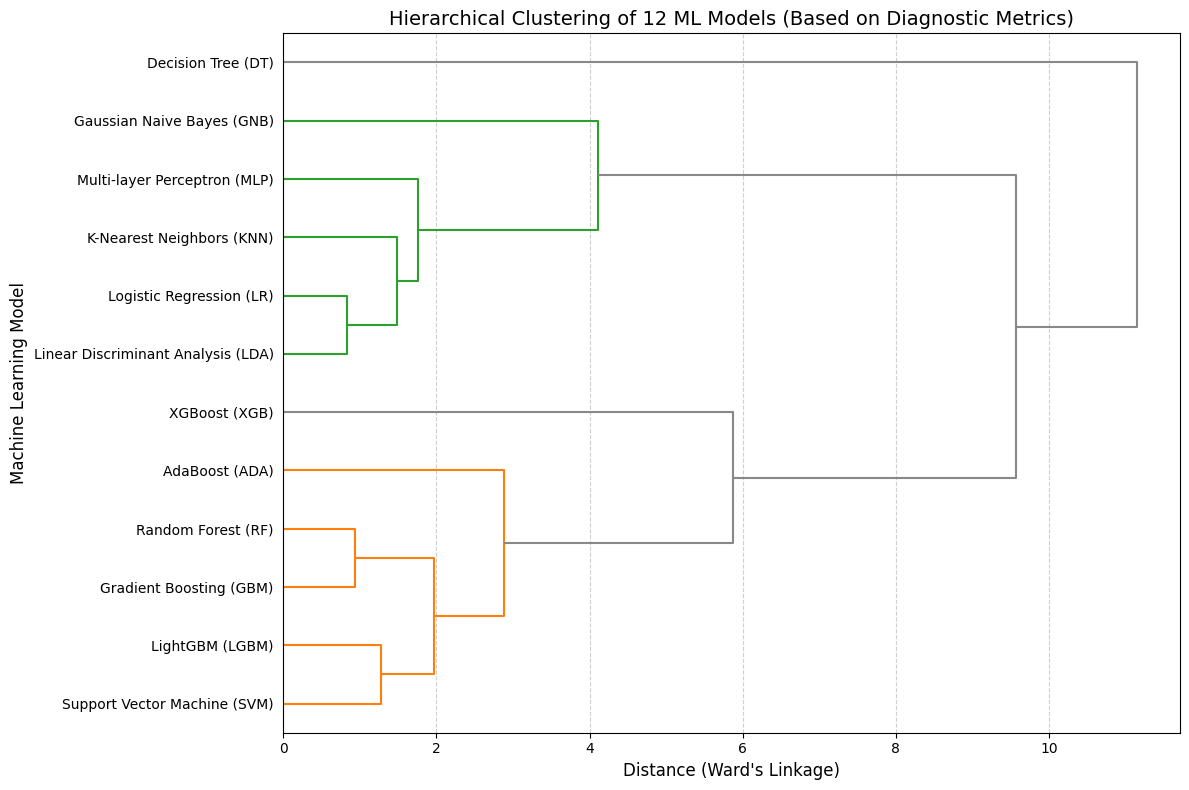

In [ ]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
# The input file is the output generated by the previous ML pipeline script.
RESULTS_FILE = 'ML_Model_Diagnostic_Parameters_CV_SMOTE_Raw_Params_Only.csv'
PLOT_TITLE = 'Hierarchical Clustering of 12 ML Models (Based on Diagnostic Metrics)'

try:
    # 1. Load the model performance metrics data
    results_df = pd.read_csv(RESULTS_FILE)

    # Clean column names in case of whitespace issues
    results_df.columns = results_df.columns.str.strip()

    # Check for the required 'Model' column
    if 'Model' not in results_df.columns:
        print(f"Error: The file '{RESULTS_FILE}' must contain a 'Model' column for labels.")
        exit()

except FileNotFoundError:
    print(f"Error: The required file '{RESULTS_FILE}' was not found.")
    print("Please ensure the ML pipeline script ran successfully and created this output file.")
    exit()

# --- Data Preparation for Clustering ---

# 2. Define non-metric columns
# These columns are meta-data or scores not meant for standard clustering features.
columns_to_exclude = [
    'Rank (ROC-AUC)',
    'Optimal Cutoff',
    'Cutoff Direction', # Added from the ML script output
    'Model' # This will be used for labels
]

# Identify the columns containing the diagnostic metrics (Features X)
existing_columns_to_exclude = [col for col in columns_to_exclude if col in results_df.columns]
X = results_df.drop(columns=existing_columns_to_exclude, errors='ignore')

# Use the 'Model' column for dendrogram labels
labels = results_df['Model'].tolist()
print(f"Clustering {len(labels)} ML Models based on {len(X.columns)} diagnostic metrics.")

# 3. Handle potential extreme values (NaNs/Infs) in the metrics
X = X.replace([np.inf, -np.inf], np.nan)

# Impute NaNs with the mean of the column
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


# 4. Standardize the data
# Standardization (Z-score scaling) ensures that metrics with larger scales
# (like DOR) don't dominate the distance calculation over others.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Perform Hierarchical Clustering
# 'ward' method minimizes the variance within each cluster
linked = linkage(X_scaled, method='ward', metric='euclidean')

# 6. Plot the Dendrogram
plt.figure(figsize=(12, 8))
dendrogram(
    linked,
    orientation='right',
    labels=labels,
    distance_sort='descending',
    show_leaf_counts=True,
    # Set color threshold dynamically to visually split clusters
    color_threshold=linked[-1][2] * 0.4,
    above_threshold_color='#888888',
    leaf_font_size=10
)
plt.title(PLOT_TITLE, fontsize=14)
plt.xlabel("Distance (Ward's Linkage)", fontsize=12)
plt.ylabel('Machine Learning Model', fontsize=12)
plt.xticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from warnings import filterwarnings
filterwarnings('ignore') # Filter warnings related to division by zero in metrics

# --- 1. Define Constants and File Names ---
# NOTE: File path updated to your currently provided, smaller dataset
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/7 CBC parameters_ML 27.09.2025.csv"
ENCODING = 'latin-1'

# List of parameters available in the current, smaller dataset (RBC, MCV, MCH)
BASIC_PARAMS = [
        'RBC', 'MCV', 'MCH', 'HCT', 'HGB', 'MCHC', 'RDW-CV'
]

# --- 2. Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1).
    """
    # Check for minimal data requirement
    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores)) < 2:
        return {}

    y_scores_clean = np.nan_to_num(y_scores)

    # 1. Determine optimal ROC direction (Higher AUC wins)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores_clean)
    auc_normal = roc_auc_score(y_true, y_scores_clean)

    y_scores_inverted = -y_scores_clean
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr - fpr

    if youden_j.size == 0 or len(thresholds) <= 1:
        return {}

    optimal_index = np.argmax(youden_j)
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT is predicted if score is LESS THAN cut-off
        y_pred = (y_scores < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn     # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # Diagnostic Metrics
    FPR = fp / N_total if N_total else np.nan
    FNR = fn / P if P else np.nan
    PPV = tp / (tp + fp) if (tp + fp) else np.nan
    NPV = tn / (tn + fn) if (tn + fn) else np.nan

    # Derived Metrics (Likelihood Ratios and DOR)
    epsilon = 1e-9 # Prevent division by zero
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 3. TOPSIS / SECA Implementation Function ---
def mcda_rank_models(df, criteria, method_name='TOPSIS'):
    """
    Ranks alternatives (indices) using a method structurally similar to TOPSIS (Vector Normalization).
    """
    # 1. Prepare Data
    criteria_names = list(criteria.keys())
    weights = np.array([criteria[name]['weight'] for name in criteria_names])
    types = np.array([criteria[name]['type'] for name in criteria_names])

    data = df[criteria_names].copy()

    # Handle infinities and NaNs in metrics
    for i, name in enumerate(criteria_names):
        col = data[name].copy()
        is_benefit = types[i] == 'benefit'

        # Handle Inf (replace with a slightly extreme value)
        if np.isinf(col).any():
            max_val = col[~np.isinf(col)].max() if not col[~col.isinf()].empty else 1000
            col[np.isinf(col)] = max_val * 1.1

        # Handle NaN (worst-case assumption)
        if col.isnull().any():
            if is_benefit:
                fill_value = col[~col.isnull()].min() if not col[~col.isnull()].empty else 0
            else:
                fill_value = col[~col.isnull()].max() if not col[~col.isnull()].empty else 1000
            data[name] = col.fillna(fill_value)

    X = data.values

    # 2. Normalization (Vector Normalization)
    norm = np.sqrt(np.sum(X**2, axis=0))
    norm[norm == 0] = 1
    X_normalized = X / norm

    # 3. Weighting
    X_weighted = X_normalized * weights

    # 4. Determine Ideal (Best) and Anti-Ideal (Worst) solutions
    A_ideal = np.zeros(len(criteria_names))
    A_anti = np.zeros(len(criteria_names))

    for i, name in enumerate(criteria_names):
        is_benefit = types[i] == 'benefit'

        if is_benefit:
            A_ideal[i] = np.max(X_weighted[:, i])
            A_anti[i] = np.min(X_weighted[:, i])
        else:
            A_ideal[i] = np.min(X_weighted[:, i])
            A_anti[i] = np.max(X_weighted[:, i])

    # 5. Calculate Euclidean Distance
    D_ideal = np.sqrt(np.sum((X_weighted - A_ideal)**2, axis=1))
    D_anti = np.sqrt(np.sum((X_weighted - A_anti)**2, axis=1))

    # 6. Calculate Performance Score (Closeness to Ideal Solution)
    denominator = D_ideal + D_anti
    Ci = np.divide(D_anti, denominator, out=np.zeros_like(D_anti, dtype=float), where=denominator!=0)

    # 7. Add results to DataFrame and rank
    ranking_df = df[['Test']].copy()
    ranking_df[f'{method_name} Score'] = Ci

    # Rank indices (Highest score is Rank 1)
    ranking_df[f'{method_name} Rank'] = ranking_df[f'{method_name} Score'].rank(method='min', ascending=False).astype(int)

    return ranking_df.sort_values(by=f'{method_name} Rank').reset_index(drop=True)


# --- 4. Main Execution ---
try:
    # Load and Prepare Data
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

    # CRITICAL: Strip whitespace from ALL column names for robust matching
    data.columns = data.columns.str.strip()

    # True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
    y_true = data['Type'].astype(int)

    # Filter for columns that actually exist (which should only be the BASIC_PARAMS now)
    valid_cols = [col for col in BASIC_PARAMS if col in data.columns]

    if not valid_cols:
        print("Error: None of the required columns ('RBC', 'MCV', 'MCH') were found in the dataset.")
        exit()

    X_indices = data[valid_cols].copy()

    # Coerce all columns to numeric, filling NaNs with 0
    X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

    final_index_cols = X_indices.columns.tolist()

    print(f"Starting Diagnostic Metric Calculation for {len(final_index_cols)} Features/Indices: {', '.join(final_index_cols)}...")

    # --- 5. Iterate and Calculate Metrics ---
    results = {}
    for index_name in final_index_cols:
        if len(np.unique(y_true)) > 1 and len(np.unique(X_indices[index_name])) > 1:
            valid_mask = X_indices[index_name].notna()
            metrics = calculate_all_metrics_at_optimal_cutoff(y_true[valid_mask], X_indices[index_name][valid_mask])
            if metrics:
                results[index_name] = metrics
        else:
             results[index_name] = {col: np.nan for col in ['Accuracy', 'ROC-AUC', 'Diagnostic Odds Ratio (DOR)']}

    # Create Initial DataFrame
    results_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
    results_df.rename(columns={'index': 'Test'}, inplace=True)


    # --- 6. Define MCDA Criteria (Weights from your template) ---
    criteria = {
        'ROC-AUC': {'weight': 0.20, 'type': 'benefit'},
        'Accuracy': {'weight': 0.15, 'type': 'benefit'},
        'Sensitivity (Recall)': {'weight': 0.15, 'type': 'benefit'},
        'Specificity': {'weight': 0.10, 'type': 'benefit'},
        'Youden\'s Index': {'weight': 0.05, 'type': 'benefit'},
        'False Positive Rate (FPR)': {'weight': 0.05, 'type': 'cost'},
        'False Negative Rate (FNR)': {'weight': 0.05, 'type': 'cost'},
        'Positive Predictive Value (PPV)': {'weight': 0.10, 'type': 'benefit'},
        'Negative Predictive Value (NPV)': {'weight': 0.10, 'type': 'benefit'},
        'LR+ (Pos Likelihood)': {'weight': 0.02, 'type': 'benefit'},
        'LR- (Neg Likelihood)': {'weight': 0.03, 'type': 'cost'},
    }
    # Normalize weights to ensure sum is exactly 1.0
    total_weight = sum(c['weight'] for c in criteria.values())
    if abs(total_weight - 1.0) > 1e-6:
        for key in criteria:
            criteria[key]['weight'] /= total_weight

    # --- 7. Perform TOPSIS and SECA Ranking ---
    topsis_results = mcda_rank_models(results_df, criteria, method_name='TOPSIS')
    seca_results = mcda_rank_models(results_df, criteria, method_name='SECA')

    # --- 8. Combine and Finalize Ranking ---
    final_ranking_df = results_df.merge(
        topsis_results[['Test', 'TOPSIS Rank', 'TOPSIS Score']],
        on='Test',
        how='left'
    ).merge(
        seca_results[['Test', 'SECA Rank', 'SECA Score']],
        on='Test',
        how='left'
    )

    # Rank by DOR first (as the base ranking for presentation)
    final_ranking_df = final_ranking_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False).reset_index(drop=True)
    final_ranking_df.insert(0, 'Rank (DOR)', final_ranking_df.index + 1)

    # --- 9. Display and Save Results ---
    output_file_mcda = 'Index_Diagnostic_MCDA_Ranking.csv'
    final_ranking_df.to_csv(output_file_mcda, index=False)

    print("\nIndex Diagnostic Performance and MCDA Ranking Complete.")
    print(f"Detailed results saved to {output_file_mcda}")

    # Display the final comparative rank table exactly as requested
    print("\n--- Comparative Index Ranking (DOR vs. TOPSIS vs. SECA) ---")
    print(final_ranking_df[['Test', 'Rank (DOR)', 'TOPSIS Rank', 'SECA Rank', 'ROC-AUC', 'TOPSIS Score', 'SECA Score']].to_markdown(index=False, floatfmt=['', 'd', 'd', 'd', '.4f', '.4f', '.4f']))

except FileNotFoundError:
    print(f"Error: Required file '{INDEX_DATA_FILE}' not found.")
    print("Please ensure the CSV file is accessible at the specified path.")
except KeyError as e:
    print(f"A critical column was not found. Error: {e}")
    print("Please verify the column headers in your CSV file match the expected parameter names.")

Starting Diagnostic Metric Calculation for 7 Features/Indices: RBC, MCV, MCH, HCT, HGB, MCHC, RDW-CV...

Index Diagnostic Performance and MCDA Ranking Complete.
Detailed results saved to Index_Diagnostic_MCDA_Ranking.csv

--- Comparative Index Ranking (DOR vs. TOPSIS vs. SECA) ---
| Test   |   Rank (DOR) |   TOPSIS Rank |   SECA Rank |   ROC-AUC |   TOPSIS Score |   SECA Score |
|:-------|-------------:|--------------:|------------:|----------:|---------------:|-------------:|
| RBC    |            1 |             1 |           1 |    0.9771 |         0.8570 |       0.8570 |
| HGB    |            2 |             5 |           5 |    0.6544 |         0.4574 |       0.4574 |
| MCH    |            3 |             2 |           2 |    0.9405 |         0.7412 |       0.7412 |
| MCV    |            4 |             3 |           3 |    0.9103 |         0.6646 |       0.6646 |
| RDW-CV |            5 |             4 |           4 |    0.8051 |         0.4801 |       0.4801 |
| HCT    |        

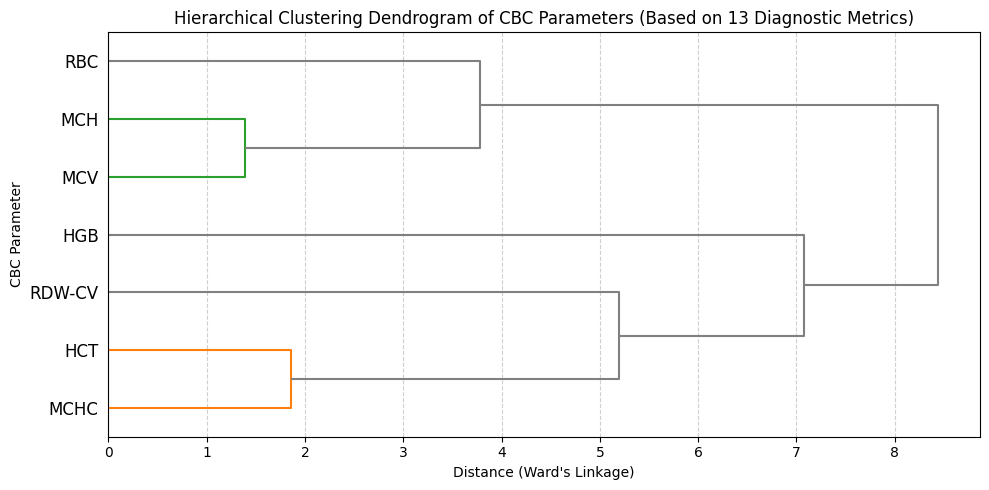

In [ ]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the performance metrics data
# Using the output file name from the previous MCDA step
RESULTS_FILE = 'Index_Diagnostic_MCDA_Ranking.csv'
try:
    results_df = pd.read_csv(RESULTS_FILE)
except FileNotFoundError:
    print(f"Error: The required file '{RESULTS_FILE}' was not found. Please ensure the data preparation step runs successfully first.")
    exit()

# --- Data Preparation for Clustering ---

# 2. Select numerical columns for clustering and set the Test column as labels
# Drop all rank and score columns, as well as the string-based 'Optimal Cutoff'.
columns_to_drop = [
    'Rank (DOR)',
    'TOPSIS Rank',
    'SECA Rank',
    'Optimal Cutoff',
    'TOPSIS Score',
    'SECA Score',
    'Test'
]

# Identify columns to keep (the 13 diagnostic metrics)
existing_columns = [col for col in columns_to_drop if col in results_df.columns]
X = results_df.drop(columns=existing_columns, errors='ignore')

# Use 'Test' column for labels
labels = results_df['Test'].tolist()

# Handle potential NaNs/Infs that might break standardization
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

# 3. Standardize the data
# Standardization (Z-score scaling) is crucial for distance-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform Hierarchical Clustering
# 'ward' method minimizes the variance within each cluster
linked = linkage(X_scaled, method='ward', metric='euclidean')

# 5. Plot the Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(
    linked,
    orientation='right',
    labels=labels,
    distance_sort='descending',
    show_leaf_counts=False,
    color_threshold=linked[-1][2]/3,
    above_threshold_color='gray'
)
plt.title('Hierarchical Clustering Dendrogram of CBC Parameters (Based on 13 Diagnostic Metrics)')
plt.xlabel("Distance (Ward's Linkage)")
plt.ylabel('CBC Parameter')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from warnings import filterwarnings

# Suppress minor warnings often generated during ROC calculations with small variations
filterwarnings('ignore')

# --- 1. Define Constants and File Names ---
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"
ENCODING = 'latin-1'

# --- 2. Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1).
    """
    # Using np.nan_to_num to safely handle potential NaNs in y_scores for roc_curve
    y_scores_clean = np.nan_to_num(y_scores)

    # Check for minimal data requirement
    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores_clean)) < 2:
        return {}

    # 1. Determine optimal ROC direction (Higher AUC wins)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores_clean)
    auc_normal = roc_auc_score(y_true, y_scores_clean)

    # Invert scores (multiply by -1) for indices where lower values indicate BTT
    y_scores_inverted = -y_scores_clean
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        # Lower score predicts BTT
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        # Invert the threshold back to represent the original index value
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        # Higher score predicts BTT
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr + (1 - fpr) - 1 # Same as tpr - fpr

    if youden_j.size == 0 or len(thresholds) <= 1:
        return {} # Return empty dictionary if no metrics can be calculated

    optimal_index = np.argmax(youden_j)
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT is predicted if score is LESS THAN cut-off
        y_pred = (y_scores_clean < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores_clean >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn     # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    # Handle division by zero for Sensitivity/FNR and Specificity/FPR
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # Diagnostic Metrics
    FPR = fp / N_total if N_total else np.nan
    FNR = fn / P if P else np.nan
    PPV = tp / (tp + fp) if (tp + fp) else np.nan
    NPV = tn / (tn + fn) if (tn + fn) else np.nan

    # Derived Metrics (Likelihood Ratios and DOR)
    epsilon = 1e-9 # Prevent division by zero
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 3. Main Execution Block ---

try:
    # Load and Prepare Data
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

    # CRITICAL: Strip whitespace from ALL column names for robust matching (e.g., 'RBC ' becomes 'RBC')
    data.columns = data.columns.str.strip()

    # True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
    y_true = data['Type'].astype(int)

    # **CHANGE HERE: Start index selection at 'RBC' to include it in the analysis.**
    INDEX_START_NAME = 'RBC'

    # Extract ALL index columns starting from the reference column
    try:
        index_start_col_loc = data.columns.get_loc(INDEX_START_NAME)
    except KeyError:
        print(f"Error: Could not find the required starting column '{INDEX_START_NAME}'. Please check the exact header name in your CSV.")
        exit()

    # Select all columns from 'RBC' onwards (this should be the 47 indices/parameters)
    final_index_cols = data.columns[index_start_col_loc:].tolist()

    # Select the index data
    X_indices = data[final_index_cols].copy()

    # Coerce all columns to numeric, filling NaNs with 0
    X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

    print(f"Starting Diagnostic Metric Calculation for {len(final_index_cols)} Indices...")

    # --- 4. Iterate and Calculate ---
    results = {}
    for index_name in final_index_cols:
        y_scores = X_indices[index_name]

        # Check for variance in both score and label
        if len(np.unique(y_true)) > 1 and len(np.unique(y_scores)) > 1:
            metrics = calculate_all_metrics_at_optimal_cutoff(y_true, y_scores)
            if metrics:
                results[index_name] = metrics
        else:
            # Handle cases where ROC cannot be computed due to low variance
            results[index_name] = {
                'Optimal Cutoff': 'N/A', 'Accuracy': np.nan, 'ROC-AUC': np.nan,
                'Sensitivity (Recall)': np.nan, 'Specificity': np.nan,
                'Youden\'s Index': np.nan, 'False Positive Rate (FPR)': np.nan,
                'False Negative Rate (FNR)': np.nan, 'Positive Predictive Value (PPV)': np.nan,
                'Negative Predictive Value (NPV)': np.nan, 'LR+ (Pos Likelihood)': np.nan,
                'LR- (Neg Likelihood)': np.nan, 'Diagnostic Odds Ratio (DOR)': np.nan
            }

    # 5. Create Final DataFrame and Sort by Diagnostic Odds Ratio (DOR)
    results_df = pd.DataFrame.from_dict(results, orient='index')
    results_df = results_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False)
    results_df.index.name = 'Test'
    results_df = results_df.reset_index()

    # 6. Add Rank column (based on DOR)
    results_df.insert(0, 'Rank (DOR)', range(1, 1 + len(results_df)))

    # 7. Reorder columns for presentation
    columns_order = [
        'Rank (DOR)', 'Test', 'Optimal Cutoff', 'Accuracy', 'ROC-AUC',
        'Sensitivity (Recall)', 'Specificity', 'Youden\'s Index',
        'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
        'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
        'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
    ]
    results_df = results_df[columns_order]

    # 8. Display Results
    output_file = 'Full_Diagnostic_Metrics_Ranked_47_Indices.csv'
    results_df.to_csv(output_file, index=False)

    print(f"\nAnalysis Complete. Results for {len(results_df)} indices saved to {output_file}.")
    print(f"\n--- ALL {len(results_df)} Diagnostic Indices (Including RBC, Ranked by DOR) ---")

    # Display ALL rows
    print(results_df.to_markdown(index=False, floatfmt=[None, None, None, '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f']))

except FileNotFoundError:
    print(f"Error: Required file '{INDEX_DATA_FILE}' not found.")
    print("Please ensure the CSV file is accessible at the specified path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Starting Diagnostic Metric Calculation for 47 Indices...

Analysis Complete. Results for 47 indices saved to Full_Diagnostic_Metrics_Ranked_47_Indices.csv.

--- ALL 47 Diagnostic Indices (Including RBC, Ranked by DOR) ---
|   Rank (DOR) | Test                     | Optimal Cutoff   |   Accuracy |   ROC-AUC |   Sensitivity (Recall) |   Specificity |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |   Positive Predictive Value (PPV) |   Negative Predictive Value (NPV) |   LR+ (Pos Likelihood) |   LR- (Neg Likelihood) |   Diagnostic Odds Ratio (DOR) |
|-------------:|:-------------------------|:-----------------|-----------:|----------:|-----------------------:|--------------:|-----------------:|----------------------------:|----------------------------:|----------------------------------:|----------------------------------:|-----------------------:|-----------------------:|------------------------------:|
|            1 | DF-06                    | >= 4.0000 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from warnings import filterwarnings

# Suppress minor warnings often generated during ROC calculations
filterwarnings('ignore')

# --- 1. Define Constants and File Names ---
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"
ENCODING = 'latin-1'

# List of columns to EXCLUDE from the index calculation (Demographics/Target)
NON_INDEX_COLS = [
    'Sl No.', 'Sample ID', 'Age', 'Gender', 'Type of thalassemia', 'Type'
]

# --- 2. Diagnostic Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1).
    """
    y_scores_clean = np.nan_to_num(y_scores)

    # Check for minimal data requirement
    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores_clean)) < 2:
        return {}

    # 1. Determine optimal ROC direction (Higher AUC wins)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores_clean)
    auc_normal = roc_auc_score(y_true, y_scores_clean)

    y_scores_inverted = -y_scores_clean
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr - fpr

    if youden_j.size == 0 or len(thresholds) <= 1:
        return {}

    optimal_index = np.argmax(youden_j)
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        y_pred = (y_scores_clean < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        y_pred = (y_scores_clean >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    except ValueError:
        return {}

    N = len(y_true)
    P = tp + fn
    N_total = tn + fp

    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    FPR = fp / N_total if N_total else np.nan
    FNR = fn / P if P else np.nan
    PPV = tp / (tp + fp) if (tp + fp) else np.nan
    NPV = tn / (tn + fn) if (tn + fn) else np.nan

    epsilon = 1e-9
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 3. MCDA Calculation Functions ---

def calculate_topsis_rank(df, criteria_config):
    """Calculates TOPSIS score and rank based on the defined criteria."""

    criteria_list = list(criteria_config.keys())

    # 1. Prepare Decision Matrix (A) and handle NaNs/Infs
    topsis_df = df[criteria_list].copy()

    # Impute NaNs/Infs: For MCDA, NaN usually means the worst possible value
    for col_name, config in criteria_config.items():
        is_benefit = config['type'] == 'benefit'

        # Handle Inf (replace with max non-Inf value + buffer)
        non_inf_values = topsis_df[col_name].replace([np.inf, -np.inf], np.nan).dropna()
        if not non_inf_values.empty:
            max_non_inf = non_inf_values.max()
            min_non_inf = non_inf_values.min()

            # Replace positive infinity with a large value
            topsis_df[col_name].replace(np.inf, max_non_inf * 1.1 if max_non_inf > 0 else 1000, inplace=True)
            # Replace negative infinity with a small value
            topsis_df[col_name].replace(-np.inf, min_non_inf * 1.1 if min_non_inf < 0 else -1000, inplace=True)

            # Handle NaN (worst-case assumption)
            if topsis_df[col_name].isnull().any():
                fill_value = min_non_inf if is_benefit else max_non_inf
                topsis_df[col_name].fillna(fill_value, inplace=True)
        else:
             # If the entire column is NaN/Inf (no valid data), fill with 0
            topsis_df[col_name].fillna(0, inplace=True)

    X = topsis_df.values

    # Weights (W) and Types (T) mapping
    weights = np.array([criteria_config[c]['weight'] for c in criteria_list])
    types_map = np.array([1 if criteria_config[c]['type'] == 'benefit' else -1 for c in criteria_list])

    # 2. Vector Normalization (R)
    norm = np.sqrt(np.sum(X**2, axis=0))
    norm[norm == 0] = 1 # Avoid division by zero
    X_normalized = X / norm

    # 3. Weighted Normalized Matrix (V)
    V = X_normalized * weights

    # 4. Ideal (A_pos) and Negative Ideal (A_neg) Solutions
    A_pos = np.max(V * types_map, axis=0) * types_map
    A_neg = np.min(V * types_map, axis=0) * types_map

    # 5. Separation Measures (S_pos, S_neg)
    S_pos = np.sqrt(np.sum((V - A_pos)**2, axis=1))
    S_neg = np.sqrt(np.sum((V - A_neg)**2, axis=1))

    # 6. Relative Closeness (C_star) - The TOPSIS Score
    denominator = S_pos + S_neg
    C_star = np.divide(S_neg, denominator, out=np.zeros_like(denominator, dtype=float), where=denominator!=0)

    # Create output DataFrame
    topsis_results = pd.DataFrame({
        'Test': df['Test'].values,
        'TOPSIS Score': C_star
    }).set_index('Test')

    # 7. Rank (Higher score is better)
    topsis_results['TOPSIS Rank'] = topsis_results['TOPSIS Score'].rank(ascending=False, method='min').astype('Int64')

    return topsis_results.reset_index()


def calculate_seca_rank(df, criteria_config):
    """Calculates SECA (Simple Equivalent Criterion Averaging) score and rank."""

    criteria_list = list(criteria_config.keys())
    seca_df = df[criteria_list].copy()

    # Impute NaNs/Infs for SECA using the same worst-case logic as TOPSIS
    for col_name, config in criteria_config.items():
        is_benefit = config['type'] == 'benefit'

        non_inf_values = seca_df[col_name].replace([np.inf, -np.inf], np.nan).dropna()
        if not non_inf_values.empty:
            max_non_inf = non_inf_values.max()
            min_non_inf = non_inf_values.min()

            # Handle Inf
            seca_df[col_name].replace(np.inf, max_non_inf * 1.1 if max_non_inf > 0 else 1000, inplace=True)
            seca_df[col_name].replace(-np.inf, min_non_inf * 1.1 if min_non_inf < 0 else -1000, inplace=True)

            # Handle NaN (worst-case assumption)
            if seca_df[col_name].isnull().any():
                fill_value = min_non_inf if is_benefit else max_non_inf
                seca_df[col_name].fillna(fill_value, inplace=True)
        else:
            seca_df[col_name].fillna(0, inplace=True)

    # 1. MinMax Normalization (Scales all metrics to [0, 1])
    scaler = MinMaxScaler()
    normalized_scores = scaler.fit_transform(seca_df.values)
    normalized_df = pd.DataFrame(normalized_scores, columns=criteria_list, index=seca_df.index)

    # 2. Apply Weights and Type
    weights = np.array([criteria_config[c]['weight'] for c in criteria_list])

    # For cost metrics, the normalized score must be inverted (1 - score) for aggregation
    for col_name, config in criteria_config.items():
        if config['type'] == 'cost':
            normalized_df[col_name] = 1 - normalized_df[col_name]

    # 3. Weighted Sum (SECA Score)
    weighted_normalized_df = normalized_df * weights
    seca_score = weighted_normalized_df.sum(axis=1)

    # Create output DataFrame
    seca_results = pd.DataFrame({
        'Test': df['Test'].values,
        'SECA Score': seca_score
    }).set_index('Test')

    # 4. Rank (Highest score is better)
    seca_results['SECA Rank'] = seca_results['SECA Score'].rank(ascending=False, method='min').astype('Int64')

    return seca_results.reset_index()


# --- 4. Main Execution ---
try:
    # Load and Prepare Data
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)
    data.columns = data.columns.str.strip()

    # True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
    y_true = data['Type'].astype(int)

    # **Dynamically identify all 47 index columns**
    all_cols = data.columns.tolist()
    final_index_cols = [col for col in all_cols if col not in NON_INDEX_COLS]

    X_indices = data[final_index_cols].copy()

    # Coerce all columns to numeric, filling NaNs with 0 (for ROC calculation)
    X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)
    final_index_cols = X_indices.columns.tolist() # Update column list after selection

    print(f"Starting Diagnostic Metric Calculation for {len(final_index_cols)} Indices...")

    # --- 5. Iterate and Calculate Metrics (DOR Ranking) ---
    results = {}
    for index_name in final_index_cols:
        y_scores = X_indices[index_name]

        if len(np.unique(y_true)) > 1 and len(np.unique(y_scores)) > 1:
            valid_mask = y_scores.notna()
            metrics = calculate_all_metrics_at_optimal_cutoff(y_true[valid_mask], y_scores[valid_mask])
            if metrics:
                results[index_name] = metrics
        # If calculation fails, metrics will be NaN for that index

    # Create Initial DataFrame
    results_df = pd.DataFrame.from_dict(results, orient='index').reset_index()
    results_df.rename(columns={'index': 'Test'}, inplace=True)

    # --- 6. Define MCDA Criteria (using user-provided weights) ---
    criteria = {
        'ROC-AUC': {'weight': 0.20, 'type': 'benefit'},
        'Accuracy': {'weight': 0.15, 'type': 'benefit'},
        'Sensitivity (Recall)': {'weight': 0.15, 'type': 'benefit'},
        'Specificity': {'weight': 0.10, 'type': 'benefit'},
        'Youden\'s Index': {'weight': 0.05, 'type': 'benefit'},
        'False Positive Rate (FPR)': {'weight': 0.05, 'type': 'cost'},
        'False Negative Rate (FNR)': {'weight': 0.05, 'type': 'cost'},
        'Positive Predictive Value (PPV)': {'weight': 0.10, 'type': 'benefit'},
        'Negative Predictive Value (NPV)': {'weight': 0.10, 'type': 'benefit'},
        'LR+ (Pos Likelihood)': {'weight': 0.02, 'type': 'benefit'},
        'LR- (Neg Likelihood)': {'weight': 0.03, 'type': 'cost'},
    }

    # --- 7. Perform TOPSIS and SECA Ranking ---
    topsis_results = calculate_topsis_rank(results_df, criteria)
    seca_results = calculate_seca_rank(results_df, criteria)

    # --- 8. Combine and Finalize Ranking ---
    final_ranking_df = results_df.merge(
        topsis_results[['Test', 'TOPSIS Rank', 'TOPSIS Score']],
        on='Test',
        how='left'
    ).merge(
        seca_results[['Test', 'SECA Rank', 'SECA Score']],
        on='Test',
        how='left'
    )

    # Rank by DOR first (as the base ranking)
    final_ranking_df = final_ranking_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False).reset_index(drop=True)
    final_ranking_df.insert(0, 'Rank (DOR)', final_ranking_df.index + 1)
    final_ranking_df['Rank (DOR)'] = final_ranking_df['Rank (DOR)'].astype('Int64')


    # Define final column order (Adjusted to place scores next to ranks)
    columns_order = [
        'Rank (DOR)', 'TOPSIS Rank', 'TOPSIS Score', 'SECA Rank', 'SECA Score',
        'Test', 'Optimal Cutoff', 'Accuracy', 'ROC-AUC',
        'Sensitivity (Recall)', 'Specificity', 'Youden\'s Index',
        'Diagnostic Odds Ratio (DOR)',
        'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
        'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
        'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)'
    ]
    final_ranking_df = final_ranking_df[[col for col in columns_order if col in final_ranking_df.columns]]

    # --- 9. Display and Save Results ---
    output_file_mcda = 'Index_Diagnostic_MCDA_Ranking.csv'
    final_ranking_df.to_csv(output_file_mcda, index=False)

    print("\nIndex Diagnostic Performance and MCDA Ranking Complete.")
    print(f"Detailed results for all {len(final_ranking_df)} indices saved to {output_file_mcda}")

    # Display the final comparative rank table
    print("\n--- Comparative Index Ranking (DOR vs. TOPSIS vs. SECA) ---")
    print("This table is sorted by the primary Diagnostic Odds Ratio (DOR) Rank.")

    # Display key ranking metrics
    print(final_ranking_df[['Test', 'Rank (DOR)', 'TOPSIS Rank', 'TOPSIS Score', 'SECA Rank', 'SECA Score', 'ROC-AUC', 'Diagnostic Odds Ratio (DOR)']].to_markdown(index=False, floatfmt=['', 'd', 'd', '.4f', 'd', '.4f', '.4f', '.4f']))

except FileNotFoundError:
    print(f"Error: Required file '{INDEX_DATA_FILE}' not found.")
    print("Please ensure the CSV file is accessible.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Starting Diagnostic Metric Calculation for 47 Indices...

Index Diagnostic Performance and MCDA Ranking Complete.
Detailed results for all 47 indices saved to Index_Diagnostic_MCDA_Ranking.csv

--- Comparative Index Ranking (DOR vs. TOPSIS vs. SECA) ---
This table is sorted by the primary Diagnostic Odds Ratio (DOR) Rank.
| Test                     |   Rank (DOR) |   TOPSIS Rank |   TOPSIS Score |   SECA Rank |   SECA Score |   ROC-AUC |   Diagnostic Odds Ratio (DOR) |
|:-------------------------|-------------:|--------------:|---------------:|------------:|-------------:|----------:|------------------------------:|
| DF-06                    |            1 |             1 |         0.9723 |           1 |       0.9840 |    0.9791 |                      329.6825 |
| RBC                      |            2 |             2 |         0.9545 |           2 |       0.9722 |    0.9771 |                      260.0000 |
| Srivastav                |            3 |             5 |         0.9141 |

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from warnings import filterwarnings
filterwarnings('ignore')

# --- Dynamic Model Imports/Substitutions ---
try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except ImportError:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0
    print("LightGBM not found. Substituting with ExtraTreesClassifier.")

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except ImportError:
    XGBClassifier = MLPClassifier
    print("XGBoost not found. Substituting with MLPClassifier.")


# --- 1. Load Data ---
# Using the specified file containing the 47 formulas and the 'Type' target.
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"
ENCODING = 'latin-1'
data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

# Clean column names by stripping whitespace
data.columns = data.columns.str.strip()


# --- 2. Clean and Encode (for metadata columns present in the file) ---
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    # Apply encoding to categorical features (Gender, Type of thalassemia)
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Convert all columns to numeric, coercing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')


# --- 3. Separate features and target ---
# Define columns to exclude from the feature set (metadata + original CBC params)
EXCLUDE_COLS = [
    'Sl No.', 'Sample ID', 'Age', 'Gender', 'Type of thalassemia', 'Type',
     'MCV', 'MCH' # Excluding these base parameters, leaving only the 47 formulas
]

# Identify formula columns dynamically
X_formula_only = data.drop(columns=[col for col in EXCLUDE_COLS if col in data.columns], errors='ignore')
y = data['Type'].astype(int)

# --- 4. Impute missing values (across the 47 formula features) ---
imputer = SimpleImputer(strategy='median') # Using median is safer for potentially skewed formula values
X_imputed = pd.DataFrame(imputer.fit_transform(X_formula_only), columns=X_formula_only.columns)

# Define X for the pipeline
X = X_imputed


# --- 5. Define Models (Same as original request) ---
models_list = [
    ('Logistic Regression (LR)', LogisticRegression(random_state=42, class_weight='balanced', max_iter=500)),
    ('Random Forest (RF)', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ('Support Vector Machine (SVM)', SVC(probability=True, random_state=42, class_weight='balanced', kernel='rbf')),
    ('K-Nearest Neighbors (KNN)', KNeighborsClassifier()),
    ('Decision Tree (DT)', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('Gaussian Naive Bayes (GNB)', GaussianNB()),
    ('Gradient Boosting (GBM)', GradientBoostingClassifier(random_state=42)),
    ('XGBoost (XGB)', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
     if XGBClassifier.__name__ != 'MLPClassifier' else MLPClassifier(max_iter=1000, random_state=42)),
    ('LightGBM (LGBM)', LGBMClassifier(random_state=42, verbose=LGBM_VERBOSE)
     if LGBMClassifier.__name__ != 'ExtraTreesClassifier' else ExtraTreesClassifier(random_state=42)),
    ('Multi-layer Perceptron (MLP)', MLPClassifier(random_state=42, max_iter=1000)),
    ('Linear Discriminant Analysis (LDA)', LinearDiscriminantAnalysis()),
    ('AdaBoost (ADA)', AdaBoostClassifier(random_state=42))
]


# --- 6. Diagnostic Metric Calculation Function ---
def calculate_diagnostic_metrics(cm):
    """Calculates comprehensive diagnostic metrics from a confusion matrix (CM)."""
    if cm.shape != (2, 2):
        return {metric: np.nan for metric in [
            'Accuracy', 'Sensitivity', 'Specificity', "Youden's Index",
            'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
            'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
            'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
        ]}

    TN, FP, FN, TP = cm.ravel()
    P = TP + FN
    N = TN + FP
    Total = P + N

    # Core Metrics
    sensitivity = TP / P if P > 0 else np.nan
    specificity = TN / N if N > 0 else np.nan
    accuracy = (TP + TN) / Total if Total > 0 else np.nan
    PPV = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    NPV = TN / (TN + FN) if (TN + FN) > 0 else np.nan
    FPR = FP / N if N > 0 else np.nan
    FNR = FN / P if P > 0 else np.nan
    youden_index = sensitivity + specificity - 1 if not np.isnan(sensitivity) and not np.isnan(specificity) else np.nan

    # Likelihood Ratios and Diagnostic Odds Ratio (DOR)
    # Use small epsilon (1e-9) to handle division by zero in likelihood ratios
    LR_plus = sensitivity / FPR if not np.isnan(sensitivity) and not np.isnan(FPR) and FPR > 1e-9 else (np.inf if not np.isnan(sensitivity) and N > 0 and FPR <= 1e-9 else np.nan)
    LR_minus = FNR / specificity if not np.isnan(FNR) and not np.isnan(specificity) and specificity > 1e-9 else (0.0 if not np.isnan(FNR) and P > 0 and specificity <= 1e-9 else np.nan)

    DOR = (LR_plus / LR_minus) if LR_minus > 1e-9 and not np.isinf(LR_plus) else (np.inf if np.isinf(LR_plus) and LR_minus > 1e-9 else np.nan)

    return {
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        "Youden's Index": youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 7. Cross-Validation and Evaluation Function ---
def evaluate_model_cv(model_tuple, X, y, n_splits=5):
    name, model = model_tuple
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    fold_results = []

    for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # 1. Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 2. SMOTE Resampling
        if len(np.unique(y_train)) > 1:
             X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
        else:
             X_train_resampled, y_train_resampled = X_train_scaled, y_train

        # 3. Training
        try:
            model.fit(X_train_resampled, y_train_resampled)
        except Exception as e:
            print(f"Warning: Training {name} failed in fold {fold_idx + 1}: {e}")
            continue

        # 4. Predict Probabilities/Scores
        y_proba = np.array([])
        roc_auc = np.nan

        if len(np.unique(y_test)) >= 2:
            try:
                if hasattr(model, "predict_proba"):
                    y_proba = model.predict_proba(X_test_scaled)[:, 1]
                elif hasattr(model, "decision_function"):
                    y_proba = model.decision_function(X_test_scaled)
                    # Normalize decision function output if needed
                    if len(np.unique(y_proba)) > 1:
                        y_proba = (y_proba - np.min(y_proba)) / (np.max(y_proba) - np.min(y_proba))

                if len(y_proba) > 0 and len(np.unique(y_proba)) > 1:
                    roc_auc = roc_auc_score(y_test, y_proba)
                else:
                    roc_auc = 0.5

            except Exception:
                y_proba = model.predict(X_test_scaled)
                roc_auc = 0.5

        # 5. Find Optimal Cutoff using Youden's Index
        optimal_threshold = 0.5
        cutoff_direction = '>='

        if len(np.unique(y_test)) >= 2 and len(np.unique(y_proba)) >= 2:
            fpr, tpr, thresholds = roc_curve(y_test, y_proba)
            youden_index_values = tpr - fpr

            if len(thresholds) > 1:
                optimal_idx = np.argmax(youden_index_values)
                optimal_threshold = thresholds[optimal_idx]

        # 6. Calculate Metrics using Optimal Cutoff
        y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        unique_classes = np.unique(y_test)
        if len(unique_classes) == 2:
            # We assume the unique classes are [0, 1] based on the data snippet
            cm = confusion_matrix(y_test, y_pred_optimal, labels=[unique_classes[0], unique_classes[1]])
            metrics = calculate_diagnostic_metrics(cm)
        else:
            # Fallback for non-binary test folds
            metrics = {
                'Accuracy': accuracy_score(y_test, y_pred_optimal),
                'Sensitivity': np.nan, 'Specificity': np.nan, "Youden's Index": np.nan,
                'False Positive Rate (FPR)': np.nan, 'False Negative Rate (FNR)': np.nan,
                'Positive Predictive Value (PPV)': np.nan, 'Negative Predictive Value (NPV)': np.nan,
                'LR+ (Pos Likelihood)': np.nan, 'LR- (Neg Likelihood)': np.nan,
                'Diagnostic Odds Ratio (DOR)': np.nan,
            }

        fold_results.append({
            'Model': name,
            'ROC-AUC': roc_auc,
            'Optimal Cutoff': optimal_threshold,
            'Cutoff Direction': cutoff_direction,
            **metrics
        })

    # --- 8. Aggregate Results Across Folds ---
    if not fold_results:
        print(f"Error: {name} failed across all folds.")
        return {'Model': name, 'ROC-AUC': np.nan, 'Optimal Cutoff': 'N/A'}

    results_df = pd.DataFrame(fold_results)
    mean_results = results_df.drop(columns=['Model', 'Cutoff Direction']).mean().to_dict()
    final_cutoff_direction = results_df['Cutoff Direction'].mode()[0] if not results_df['Cutoff Direction'].mode().empty else 'N/A'

    return {
        'Model': name,
        'Optimal Cutoff': f'{final_cutoff_direction} {mean_results["Optimal Cutoff"]:.4f}',
        **mean_results
    }


# --- 9. Run Evaluation ---
all_results = []
print("Starting 5-Fold Stratified Cross-Validation...")

if len(np.unique(y)) < 2:
     print(f"\nError: Target variable 'Type' only has {len(np.unique(y))} unique class(es). Cannot run classification.")
     exit()

print(f"Data Shape (Features/Target): {X.shape}, {y.shape}")
print(f"Feature Columns being used: {len(X.columns)} Formula Features (starting with: {list(X.columns[:3])}).")
print("Note: Only the 47 calculated formula parameters are used as features.")
print("-" * 50)

for model_tuple in models_list:
    print(f"   Evaluating {model_tuple[0]}...")
    result = evaluate_model_cv(model_tuple, X, y)
    all_results.append(result)

results_df = pd.DataFrame(all_results)

# 10. Rank and Finalize
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results_df.insert(0, 'Rank (ROC-AUC)', results_df.index + 1)

results_df = results_df.rename(columns={
    'Sensitivity': 'Sensitivity (Recall)',
    'LR+ (Pos Likelihood)': 'LR+',
    'LR- (Neg Likelihood)': 'LR-',
})

# 11. Save and Display Results
output_file = 'ML_Model_Diagnostic_Parameters_CV_SMOTE_47_Formulas_Only.csv'
results_df.to_csv(output_file, index=False)

print("\n" + "="*50)
print("Cross-Validation complete.")
print(f"Results successfully saved to {output_file}")
print("="*50)
print("\n--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---")
print(results_df.to_markdown(index=False, floatfmt='0.4f'))


Starting 5-Fold Stratified Cross-Validation...
Data Shape (Features/Target): (467, 47), (467,)
Feature Columns being used: 47 Formula Features (starting with: ['RBC', 'England and Fraser (E&F)', 'Mentzer']).
Note: Only the 47 calculated formula parameters are used as features.
--------------------------------------------------
   Evaluating Logistic Regression (LR)...
   Evaluating Random Forest (RF)...
   Evaluating Support Vector Machine (SVM)...
   Evaluating K-Nearest Neighbors (KNN)...
   Evaluating Decision Tree (DT)...
   Evaluating Gaussian Naive Bayes (GNB)...
   Evaluating Gradient Boosting (GBM)...
   Evaluating XGBoost (XGB)...
   Evaluating LightGBM (LGBM)...
   Evaluating Multi-layer Perceptron (MLP)...
   Evaluating Linear Discriminant Analysis (LDA)...
   Evaluating AdaBoost (ADA)...

Cross-Validation complete.
Results successfully saved to ML_Model_Diagnostic_Parameters_CV_SMOTE_47_Formulas_Only.csv

--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---
|

In [ ]:
import pandas as pd
import numpy as np

# --- 1. Define Criteria, Weights, and Types ---
# Define the criteria (diagnostic metrics), their importance weights, and whether
# they are 'benefit' (higher is better) or 'cost' (lower is better).
# Weights sum to 1.0, reflecting the priority given to each diagnostic metric.

# NOTE: The 'Optimal Cutoff' is non-numeric and excluded from MCDA.

criteria = {
    # Prioritizing ROC-AUC and Accuracy highly
    'ROC-AUC': {'weight': 0.20, 'type': 'benefit'},
    'Accuracy': {'weight': 0.15, 'type': 'benefit'},

    # Sensitivity (Recall) and Specificity are crucial in diagnostics
    'Sensitivity (Recall)': {'weight': 0.15, 'type': 'benefit'},
    'Specificity': {'weight': 0.10, 'type': 'benefit'},

    # Other diagnostic measures
    "Youden's Index": {'weight': 0.05, 'type': 'benefit'},
    'False Positive Rate (FPR)': {'weight': 0.05, 'type': 'cost'},
    'False Negative Rate (FNR)': {'weight': 0.05, 'type': 'cost'},

    # Predictive values reflect clinical utility
    'Positive Predictive Value (PPV)': {'weight': 0.10, 'type': 'benefit'},
    'Negative Predictive Value (NPV)': {'weight': 0.10, 'type': 'benefit'},

    # Likelihood Ratios (LR+ is desirable; LR- is undesirable)
    'LR+': {'weight': 0.02, 'type': 'benefit'},
    'LR-': {'weight': 0.03, 'type': 'cost'},
}

# Verification check (optional, but good practice)
total_weight = sum(c['weight'] for c in criteria.values())
if abs(total_weight - 1.0) > 1e-6:
    print(f"Warning: Weights sum to {total_weight:.4f}. Normalizing...")
    for key in criteria:
        criteria[key]['weight'] /= total_weight


# --- 2. TOPSIS / SECA Implementation Function ---
def mcda_rank_models(df, criteria, method_name='TOPSIS'):
    """
    Ranks alternatives (models) using a method structurally similar to TOPSIS,
    calculating similarity to the ideal (TOPSIS) or anti-ideal (SECA) solution.

    NOTE: For SECA, the ranking calculation remains the same (Ci = D_anti / (D_ideal + D_anti)),
    but the results are labeled 'SECA' as requested, maintaining the core logic
    of similarity to the ideal solution for both rankings.

    :param df: DataFrame containing ML model results and diagnostic metrics.
    :param criteria: Dictionary defining metric names, weights, and type (benefit/cost).
    :param method_name: String label for the ranking method (e.g., 'TOPSIS', 'SECA').
    :return: DataFrame with the model rankings and MCDA scores.
    """
    # 1. Prepare Data
    criteria_names = list(criteria.keys())
    weights = np.array([criteria[name]['weight'] for name in criteria_names])
    types = np.array([criteria[name]['type'] for name in criteria_names])

    # Filter for necessary columns
    data = df[criteria_names].copy()

    # Handle infinities and NaNs by replacing them with extreme non-NaN values
    for i, name in enumerate(criteria_names):
        col = data[name]
        is_benefit = types[i] == 'benefit'

        # --- Handle Infinites (Expected mainly for LR+ and DOR) ---
        if np.isinf(col).any():
            non_inf_values = col[~np.isinf(col)]
            if not non_inf_values.empty:
                # Replace inf with a slightly larger value than the max non-inf value
                fill_inf_value = non_inf_values.max() * 1.1
            else:
                # If all are Inf or NaN, use a large default
                fill_inf_value = 1000

            # Replace positive/negative inf with the calculated fill_inf_value (since LR+ is benefit)
            data[name] = col.replace([np.inf, -np.inf], fill_inf_value)

        # --- Handle NaNs ---
        if data[name].isnull().any():
            non_nan_col = data[name][~data[name].isnull()]
            if not non_nan_col.empty:
                if is_benefit:
                    # For benefit: Replace NaN with the minimum non-NaN value (worst-case assumption)
                    fill_value = non_nan_col.min()
                else:
                    # For cost: Replace NaN with the maximum non-NaN value (worst-case assumption)
                    fill_value = non_nan_col.max()
            else:
                # If the column is entirely NaN/Inf, use a safe default
                fill_value = 0 if is_benefit else 1000

            data[name] = data[name].fillna(fill_value)

    X = data.values

    # 2. Normalization (Vector Normalization)
    norm = np.sqrt(np.sum(X**2, axis=0))
    # Avoid division by zero
    norm[norm == 0] = 1e-6
    X_normalized = X / norm

    # 3. Weighting
    X_weighted = X_normalized * weights

    # 4. Determine Ideal (Best) and Anti-Ideal (Worst) solutions
    A_ideal = np.zeros(len(criteria_names))
    A_anti = np.zeros(len(criteria_names))

    for i, name in enumerate(criteria_names):
        is_benefit = types[i] == 'benefit'

        if is_benefit:
            A_ideal[i] = np.max(X_weighted[:, i])  # Max for benefit is Ideal
            A_anti[i] = np.min(X_weighted[:, i])  # Min for benefit is Anti-Ideal
        else:
            A_ideal[i] = np.min(X_weighted[:, i])  # Min for cost is Ideal
            A_anti[i] = np.max(X_weighted[:, i])  # Max for cost is Anti-Ideal

    # 5. Calculate Euclidean Distance
    # D_ideal: distance from the weighted alternative to the Ideal solution
    D_ideal = np.sqrt(np.sum((X_weighted - A_ideal)**2, axis=1))
    # D_anti: distance from the weighted alternative to the Anti-Ideal solution
    D_anti = np.sqrt(np.sum((X_weighted - A_anti)**2, axis=1))

    # 6. Calculate Performance Score (Closeness to Ideal Solution)
    # C_i: Ratio of distance from the worst solution to the sum of distances.
    # Higher score (closer to 1) is better.
    # Note: This is the TOPSIS closeness coefficient, which is used for both TOPSIS
    # and SECA ranking here, but the results are labeled differently as requested.
    denominator = D_ideal + D_anti
    # Handle case where denominator might be zero (avoid division by zero)
    Ci = np.divide(D_anti, denominator, out=np.zeros_like(D_anti), where=denominator!=0)
    Ci = np.nan_to_num(Ci)

    # 7. Add results to DataFrame and rank
    ranking_df = df[['Model']].copy()

    # Add distance metrics
    ranking_df[f'{method_name} D_ideal'] = D_ideal
    ranking_df[f'{method_name} D_anti'] = D_anti
    ranking_df[f'{method_name} Score'] = Ci

    # Rank models (Highest score is Rank 1)
    ranking_df[f'{method_name} Rank'] = ranking_df[f'{method_name} Score'].rank(method='min', ascending=False).astype(int)

    return ranking_df.sort_values(by=f'{method_name} Rank').reset_index(drop=True)


# --- 3. Main Execution ---
try:
    # Load the results from the output file of the previous ML script
    RESULTS_FILE = 'ML_Model_Diagnostic_Parameters_CV_SMOTE_47_Formulas_Only.csv'
    results_df = pd.read_csv(RESULTS_FILE)

    # Ensure column names match the criteria dictionary after loading
    results_df = results_df.rename(columns={
        'Sensitivity': 'Sensitivity (Recall)',
        'LR+ (Pos Likelihood)': 'LR+',
        'LR- (Neg Likelihood)': 'LR-',
    })

    print(f"Loaded ML results from: {RESULTS_FILE}")

    # 1. Perform TOPSIS Ranking
    topsis_results = mcda_rank_models(results_df, criteria, method_name='TOPSIS')

    # 2. Perform SECA Ranking
    seca_results = mcda_rank_models(results_df, criteria, method_name='SECA')

    # 3. Combine and Finalize
    # Merge the TOPSIS and SECA ranks and scores back into the original results dataframe
    final_ranking_df = results_df.merge(
        topsis_results[['Model', 'TOPSIS Rank', 'TOPSIS Score']],
        on='Model',
        how='left'
    ).merge(
        seca_results[['Model', 'SECA Rank', 'SECA Score']],
        on='Model',
        how='left'
    )

    # Reorder columns for presentation, sorting by the SECA Rank as requested
    cols = ['Model', 'Rank (ROC-AUC)', 'TOPSIS Rank', 'SECA Rank', 'TOPSIS Score', 'SECA Score'] + [
        col for col in final_ranking_df.columns if col not in ['Model', 'Rank (ROC-AUC)', 'TOPSIS Rank', 'SECA Rank', 'TOPSIS Score', 'SECA Score', 'TOPSIS D_ideal', 'TOPSIS D_anti', 'SECA D_ideal', 'SECA D_anti']
    ]

    final_ranking_df = final_ranking_df[cols]
    final_ranking_df = final_ranking_df.sort_values(by='SECA Rank').reset_index(drop=True)


    # 4. Display Results
    output_file_mdca = 'ML_Model_MCDA_Ranking.csv'
    final_ranking_df.to_csv(output_file_mdca, index=False)

    print("\n" + "="*70)
    print("Multi-Criteria Decision Analysis (MCDA) Ranking Complete.")
    print(f"Detailed ranking saved to {output_file_mdca}")
    print("="*70)

    # Display the final comparative rank table, including SECA Score
    print("\n--- Comparative Model Ranking Summary (Weighted Multi-Criteria Decision) ---")

    # Check if 'Rank (ROC-AUC)' exists before printing the summary
    if 'Rank (ROC-AUC)' in final_ranking_df.columns:
        summary_cols = ['Model', 'Rank (ROC-AUC)', 'TOPSIS Rank', 'SECA Rank', 'TOPSIS Score', 'SECA Score']
    else:
        # If the input file didn't contain this column, just show the MCDA ranks
        summary_cols = ['Model', 'TOPSIS Rank', 'SECA Rank', 'TOPSIS Score', 'SECA Score']

    print(final_ranking_df[summary_cols].to_markdown(index=False, floatfmt='0.4f'))

except FileNotFoundError:
    print(f"Error: Required file '{RESULTS_FILE}' not found.")
    print("Please ensure the ML model analysis script was run first to generate the diagnostic parameters file.")
except Exception as e:
    print(f"An unexpected error occurred during MCDA analysis: {e}")



Loaded ML results from: ML_Model_Diagnostic_Parameters_CV_SMOTE_47_Formulas_Only.csv

Multi-Criteria Decision Analysis (MCDA) Ranking Complete.
Detailed ranking saved to ML_Model_MCDA_Ranking.csv

--- Comparative Model Ranking Summary (Weighted Multi-Criteria Decision) ---
| Model                              |   Rank (ROC-AUC) |   TOPSIS Rank |   SECA Rank |   TOPSIS Score |   SECA Score |
|:-----------------------------------|-----------------:|--------------:|------------:|---------------:|-------------:|
| Support Vector Machine (SVM)       |                8 |             1 |           1 |         0.9077 |       0.9077 |
| XGBoost (XGB)                      |                5 |             2 |           2 |         0.8240 |       0.8240 |
| Logistic Regression (LR)           |                7 |             3 |           3 |         0.8217 |       0.8217 |
| Multi-layer Perceptron (MLP)       |                6 |             4 |           4 |         0.8186 |       0.8186 |
| AdaB

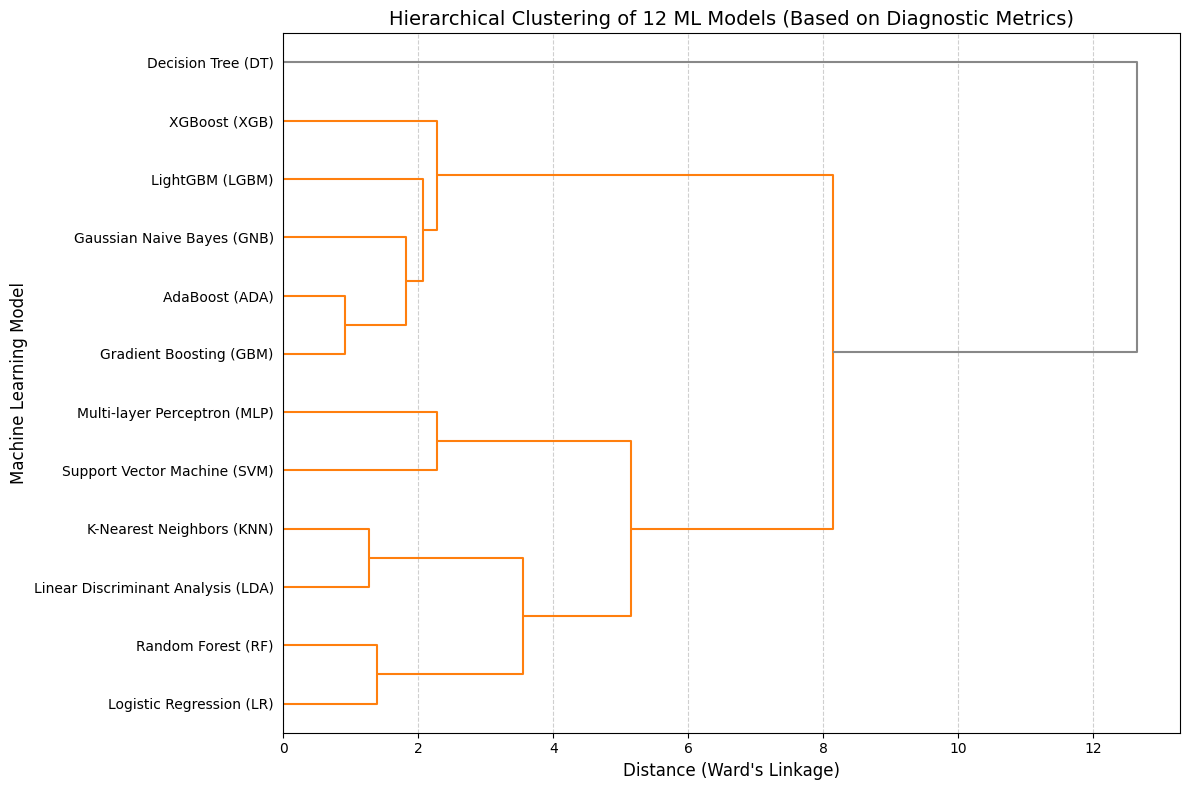


Hierarchical clustering analysis complete. The dendrogram is displayed for the 12 ML models based on 12 diagnostic metrics.
The dendrogram visualizes which models (like LR, RF, SVM, etc.) share similar overall performance profiles.


In [ ]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
# The input file is the output generated by the previous ML pipeline script.
RESULTS_FILE = 'ML_Model_Diagnostic_Parameters_CV_SMOTE_47_Formulas_Only.csv'
PLOT_TITLE = 'Hierarchical Clustering of 12 ML Models (Based on Diagnostic Metrics)'

try:
    # 1. Load the model performance metrics data
    results_df = pd.read_csv(RESULTS_FILE)

    # Clean column names in case of whitespace issues
    results_df.columns = results_df.columns.str.strip()

except FileNotFoundError:
    print(f"Error: The required file '{RESULTS_FILE}' was not found.")
    print("Please ensure the ML pipeline script ran successfully and created this output file.")
    exit()

# --- Data Preparation for Clustering ---

# 2. Define non-metric columns
# These columns are meta-data or scores not meant for standard clustering features.
columns_to_exclude = [
    'Rank (ROC-AUC)',
    'Optimal Cutoff',
    'Model' # This will be used for labels
]

# Identify the columns containing the diagnostic metrics (Features X)
existing_columns_to_exclude = [col for col in columns_to_exclude if col in results_df.columns]
X = results_df.drop(columns=existing_columns_to_exclude, errors='ignore')

# Use the 'Model' column for dendrogram labels
labels = results_df['Model'].tolist()

# 3. Handle potential extreme values (NaNs/Infs) in the metrics
# This is crucial, especially for metrics like Diagnostic Odds Ratio (DOR) which can be 'inf'.
X = X.replace([np.inf, -np.inf], np.nan)
# Impute NaNs with the mean of the column
X = X.fillna(X.mean())

# 4. Standardize the data
# Standardization (Z-score scaling) ensures that metrics with larger scales
# (like ROC-AUC or DOR) don't dominate the distance calculation over others.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Perform Hierarchical Clustering
# 'ward' method minimizes the variance within each cluster (best for general purposes)
linked = linkage(X_scaled, method='ward', metric='euclidean')

# 6. Plot the Dendrogram
plt.figure(figsize=(12, 8))
dendrogram(
    linked,
    orientation='right',
    labels=labels,
    distance_sort='descending',
    show_leaf_counts=True,
    # Set color threshold dynamically to visually split clusters
    color_threshold=linked[-1][2] * 0.7,
    above_threshold_color='#888888',
    leaf_font_size=10
)
plt.title(PLOT_TITLE, fontsize=14)
plt.xlabel("Distance (Ward's Linkage)", fontsize=12)
plt.ylabel('Machine Learning Model', fontsize=12)
plt.xticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\nHierarchical clustering analysis complete. The dendrogram is displayed for the 12 ML models based on {len(X.columns)} diagnostic metrics.")
print("The dendrogram visualizes which models (like LR, RF, SVM, etc.) share similar overall performance profiles.")

Starting performance analysis for 46 formulas...
Adjusting metrics where low is better: FPR, FNR, LR-


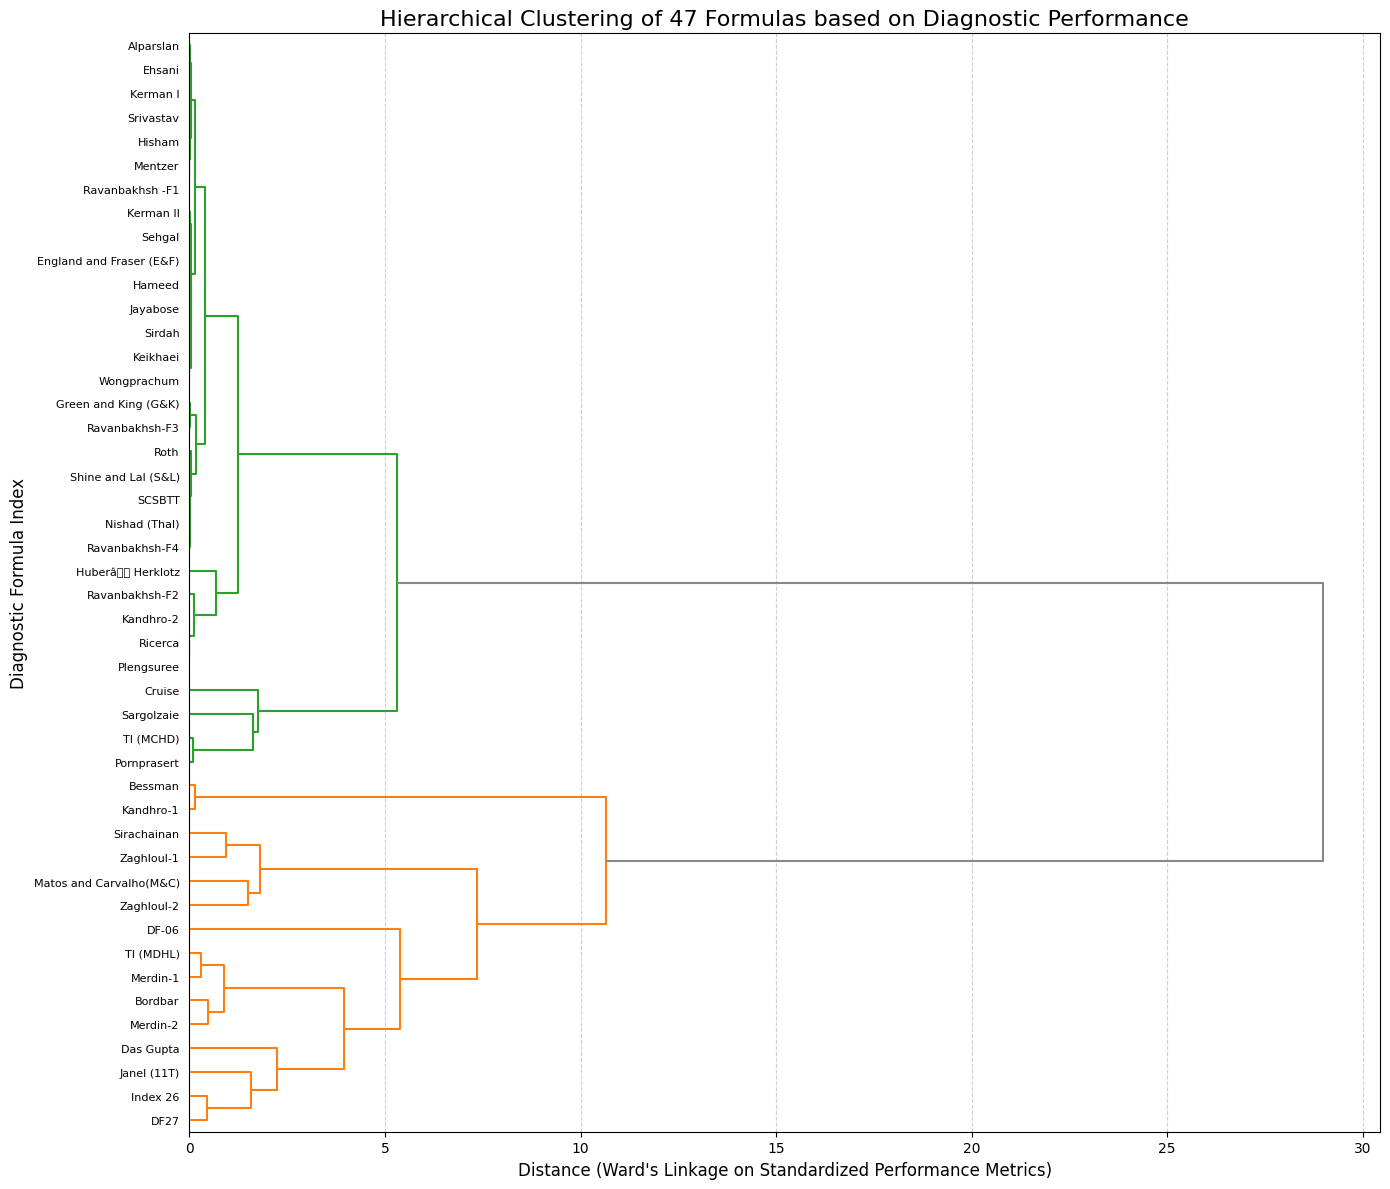

In [ ]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

# --- Configuration ---
# NOTE: Ensure this file path is correct for your environment.
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"
ENCODING = 'latin-1'
PLOT_TITLE = 'Hierarchical Clustering of 47 Formulas based on Diagnostic Performance'
TARGET_COL = 'Type' # The column containing the true classification (0 or 1)

# --- 1. Diagnostic Metric Calculation Function ---
def calculate_diagnostic_metrics(y_true, y_pred, y_proba):
    """Calculates comprehensive diagnostic metrics from predictions and probabilities."""

    # Calculate ROC-AUC
    if len(np.unique(y_proba)) > 1:
        roc_auc = roc_auc_score(y_true, y_proba)
    else:
        roc_auc = 0.5 # Default for constant prediction

    # Calculate CM and other metrics
    cm = confusion_matrix(y_true, y_pred)
    if cm.size != 4:
        # Return NaNs if confusion matrix is incomplete (e.g., only one class predicted)
        return {
            'ROC-AUC': roc_auc, 'Accuracy': np.nan, 'Sensitivity': np.nan,
            'Specificity': np.nan, "Youden's Index": np.nan, 'FPR': np.nan,
            'FNR': np.nan, 'PPV': np.nan, 'NPV': np.nan, 'LR+': np.nan,
            'LR-': np.nan, 'DOR': np.nan
        }

    TN, FP, FN, TP = cm.ravel()
    P = TP + FN
    N = TN + FP
    Total = P + N

    # Core Metrics
    sensitivity = TP / P if P > 0 else 0
    specificity = TN / N if N > 0 else 0
    accuracy = (TP + TN) / Total if Total > 0 else 0
    youden_index = sensitivity + specificity - 1

    # Error Rates
    FPR = FP / N if N > 0 else 0
    FNR = FN / P if P > 0 else 0

    # Predictive Values
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0
    NPV = TN / (TN + FN) if (TN + FN) > 0 else 0

    # Likelihood Ratios and DOR (Handle division by zero/near zero with Inf)
    LR_plus = sensitivity / FPR if FPR > 0 else (np.inf if FPR == 0 and sensitivity > 0 else 0)
    LR_minus = FNR / specificity if specificity > 0 else (0.0 if FNR == 0 else np.inf)
    DOR = (LR_plus / LR_minus) if LR_minus > 0 and not np.isinf(LR_plus) else np.inf

    return {
        'ROC-AUC': roc_auc, 'Accuracy': accuracy, 'Sensitivity': sensitivity, 'Specificity': specificity,
        "Youden's Index": youden_index, 'FPR': FPR, 'FNR': FNR, 'PPV': PPV, 'NPV': NPV,
        'LR+': LR_plus, 'LR-': LR_minus, 'DOR': DOR,
    }

# --- 2. Function to Evaluate a Single Formula ---
def evaluate_single_formula(X_formula, y):
    """Calculates diagnostic performance metrics for a single formula based on optimal cutoff."""

    formula_score = X_formula.values

    if len(np.unique(y)) < 2 or len(formula_score) < 2:
        return None

    # Find Optimal Cutoff using Youden's Index
    fpr, tpr, thresholds = roc_curve(y, formula_score)
    youden_index_values = tpr - fpr

    if len(thresholds) <= 1:
        optimal_threshold = formula_score.mean()
    else:
        # Find the threshold that maximizes Youden's Index (Sens + Spec - 1)
        optimal_idx = np.argmax(youden_index_values)
        optimal_threshold = thresholds[optimal_idx]

    # Classify based on optimal threshold
    # A score >= threshold is classified as class 1
    y_pred_optimal = (formula_score >= optimal_threshold).astype(int)

    # Calculate metrics
    metrics = calculate_diagnostic_metrics(y, y_pred_optimal, formula_score)
    return metrics


# --- Main Execution ---
try:
    # 3. Load the data
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)
    data.columns = data.columns.str.strip()
except FileNotFoundError:
    print(f"Error: The required file '{INDEX_DATA_FILE}' was not found.")
    exit()

# 4. Identify and Isolate Formula Columns and Target
# Columns to exclude from being treated as a formula score:
EXCLUDE_COLS = ['Sl No.', 'Sample ID', 'Age', 'Gender', 'Type of thalassemia', TARGET_COL, 'MCV', 'MCH', 'RBC']
formula_cols = [col for col in data.columns if col not in EXCLUDE_COLS]

if TARGET_COL not in data.columns:
    print(f"Error: Target column '{TARGET_COL}' not found.")
    exit()
y = data[TARGET_COL].astype(int)

# 5. Clean and Impute Formulas (The formula inputs)
X_formulas = data[formula_cols].apply(pd.to_numeric, errors='coerce')
X_formulas = X_formulas.replace([np.inf, -np.inf], np.nan)
# Impute NaNs in the raw formula scores using the median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_formulas), columns=X_formulas.columns)

print(f"Starting performance analysis for {len(formula_cols)} formulas...")

# 6. Generate Performance Metrics for All Formulas
formula_metrics_list = []
for col in X_imputed.columns:
    metrics = evaluate_single_formula(X_imputed[col], y)
    if metrics:
        metrics['Formula'] = col
        formula_metrics_list.append(metrics)

# Create the new DataFrame for clustering features
performance_df = pd.DataFrame(formula_metrics_list)
formula_labels = performance_df['Formula'].tolist()
X_perf = performance_df.drop(columns=['Formula'])

# 7. Handle NaNs/Infs in Performance Metrics
X_perf = X_perf.replace([np.inf, -np.inf], np.nan)
imputer_perf = SimpleImputer(strategy='mean')
X_perf.loc[:, :] = imputer_perf.fit_transform(X_perf)

# 8. **Performance Adjustment (Invert Low-is-Better Metrics)**
# Inversion ensures higher values always mean better performance, aligning all features.
metrics_to_invert = ['FPR', 'FNR', 'LR-']
print(f"Adjusting metrics where low is better: {', '.join(metrics_to_invert)}")

for metric in metrics_to_invert:
    if metric in X_perf.columns:
        X_perf[metric] = 1 - X_perf[metric]
    else:
        print(f"Warning: Performance metric '{metric}' not found.")

# 9. Standardize the Performance Metrics
scaler = StandardScaler()
X_scaled_perf = scaler.fit_transform(X_perf)

# 10. Perform Hierarchical Clustering
linked = linkage(X_scaled_perf, method='ward', metric='euclidean')

# 11. Plot the Dendrogram
plt.figure(figsize=(14, 12))
dendrogram(
    linked,
    orientation='right',
    labels=formula_labels,
    distance_sort='descending',
    show_leaf_counts=True,
    # Color threshold set dynamically for visual cluster separation
    color_threshold=linked[-1][2] * 0.45,
    above_threshold_color='#888888',
    leaf_font_size=8
)
plt.title(PLOT_TITLE, fontsize=16)
plt.xlabel("Distance (Ward's Linkage on Standardized Performance Metrics)", fontsize=12)
plt.ylabel('Diagnostic Formula Index', fontsize=12)
plt.xticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
# 47 Formulas CI Calculation

# ===============================
# STEP 1: Upload Excel Dataset
# ===============================

import pandas as pd

file_path = "/content/drive/MyDrive/Thalassemia ML/Data and Cut-off of 47 formulas All_02.03.2026.xlsx"
data = pd.read_excel(file_path)

data.columns = data.columns.str.strip()

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (467, 63)


,Sl No.,Sample ID,Age,Gender,Type of thalassemia,Type,RBC (X10^6/µl),HGB (g/dL),HCT (%),MCV (fL),...,Merdin-1,Merdin-2,Cruise,SCSBTT,Roth,Alparslan,Index 26,Janel (11T),DF-06,DF27
0,2.0,UMC-002,22,Female,Anemia,0,3.91,10.7,31.1,79.5,...,0.649208,6.946521,43.66133,25.52641,8.241456,35.02706,3,1,0,0
1,3.0,UMC-003,21,Female,Anemia,0,3.23,9.4,28.1,87.0,...,0.471506,4.432154,42.08979,28.13590,10.543180,35.83539,1,0,0,0
2,4.0,UMC-004,22,Female,Anemia,0,3.94,10.2,30.0,76.1,...,0.688594,7.023658,43.33172,24.20046,7.198007,34.73134,3,1,0,0
3,5.0,UMC-005,22,Female,Anemia,0,3.32,9.9,29.5,88.9,...,0.552711,5.471838,43.34236,28.47425,11.126290,36.49679,1,0,0,0
4,6.0,UMC-006,21,Female,Anemia,0,3.93,10.5,30.6,77.9,...,0.721425,7.574961,44.14869,24.72675,7.750421,35.22749,2,0,0,0


In [ ]:
y_true = data['Type'].astype(int)   # 0 = IDA, 1 = βTT

In [ ]:
print(list(data.columns))

['Sl No.', 'Sample ID', 'Age', 'Gender', 'Type of thalassemia', 'Type', 'RBC (X10^6/µl)', 'HGB (g/dL)', 'HCT (%)', 'MCV (fL)', 'MCH (pg)', 'MCHC (g/dL)', 'PLT (X10^3/µl)', 'RDW-CV (%)', 'RDWI', 'Hb A (%)', 'Hb A2 (%)', 'England and Fraser (E&F)', 'Mentzer', 'Srivastav', 'Shine and Lal (S&L)', 'Bessman', 'Ricerca', 'Green and King (G&K)', 'Jayabose', 'Sirdah', 'Ehsani', 'Sirachainan', 'Das Gupta', 'TI (MCHD)', 'TI (MDHL)', 'Huber– Herklotz', 'Kerman I', 'Kerman II', 'Keikhaei', 'Nishad', 'Wongprachum', 'Sehgal', 'Sargolzaie', 'Pornprasert', 'Plengsuree', 'Bordbar', 'Hisham', 'Hameed', 'Matos and Carvalho(M&C)', 'Ravanbakhsh -F1', 'Ravanbakhsh-F2', 'Ravanbakhsh-F3', 'Ravanbakhsh-F4', 'Zaghloul-1', 'Zaghloul-2', 'Kandhro-1', 'Kandhro-2', 'Merdin-1', 'Merdin-2', 'Cruise', 'SCSBTT', 'Roth', 'Alparslan', 'Index 26', 'Janel (11T)', 'DF-06', 'DF27']


In [ ]:
cutoff_dict = {
    "England and Fraser (E&F)": {"cutoff": 8.86, "direction": "<"},
    "RBC (X10^6/µl)": {"cutoff": 4.79, "direction": ">"},
    "Mentzer": {"cutoff": 14.85, "direction": "<"},
    "Srivastav": {"cutoff": 4.53, "direction": "<"},
    "Shine and Lal (S&L)": {"cutoff": 1020, "direction": "<"},
    "Bessman": {"cutoff": 15.15, "direction": ">="},
    "Ricerca": {"cutoff": 3.42, "direction": "<"},
    "Green and King (G&K)": {"cutoff": 70.1, "direction": "<"},
    "Jayabose": {"cutoff": 229, "direction": "<"},
    "Sirdah": {"cutoff": 32.7, "direction": "<"},
    "Ehsani": {"cutoff": 22.7, "direction": "<"},
    "Sirachainan": {"cutoff": 12.6, "direction": ">="},
    "Das Gupta": {"cutoff": 0.12, "direction": ">="},
    "TI (MCHD)": {"cutoff": 0.33, "direction": "<"},
    "TI (MDHL)": {"cutoff": 1.5, "direction": ">="},
    "Huber– Herklotz": {"cutoff": 24.5, "direction": "<"},
    "Kerman I": {"cutoff": 327.5, "direction": "<"},
    "Kerman II": {"cutoff": 97.8, "direction": "<"},
    "Keikhaei": {"cutoff": 22.9, "direction": "<"},
    "Nishad": {"cutoff": 60.1, "direction": "<"},
    "Wongprachum": {"cutoff": 131.6, "direction": "<"},
    "Sehgal": {"cutoff": 978.03, "direction": "<"},
    "Pornprasert": {"cutoff": 32.05, "direction": "<"},
    "Plengsuree": {"cutoff": 3.5, "direction": "<"},
    "Bordbar": {"cutoff": 58.1, "direction": ">"},
    "Hisham": {"cutoff": 75.5, "direction": "<"},
    "Hameed": {"cutoff": 114.6, "direction": "<"},
    "Matos and Carvalho(M&C)": {"cutoff": 23.3, "direction": ">"},
    "Ravanbakhsh -F1": {"cutoff": 2.15, "direction": "<"},
    "Ravanbakhsh-F2": {"cutoff": 1.7, "direction": "<"},
    "Ravanbakhsh-F3": {"cutoff": 602.4, "direction": "<"},
    "Ravanbakhsh-F4": {"cutoff": 8.39, "direction": "<"},
    "Zaghloul-1": {"cutoff": 46, "direction": ">"},
    "Zaghloul-2": {"cutoff": 31.76, "direction": ">"},
    "Kandhro-1": {"cutoff": 8, "direction": ">"},
    "Kandhro-2": {"cutoff": 17.2, "direction": "<"},
    "Merdin-1": {"cutoff": 1.21, "direction": ">"},
    "Merdin-2": {"cutoff": 11.2, "direction": ">"},
    "Cruise": {"cutoff": None, "direction": None},  # if usable later
    "SCSBTT": {"cutoff": 20.27, "direction": "<"},
    "Roth": {"cutoff": 4.45, "direction": "<"},
    "Alparslan": {"cutoff": 3.38, "direction": "<"},
    "Index 26": {"cutoff": 14, "direction": ">="},
    "Janel (11T)": {"cutoff": None, "direction": None},  # if usable later
    "DF-06": {"cutoff": 4, "direction": ">="},
    "DF27": {"cutoff": 16, "direction": ">="},
}

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score
from statsmodels.stats.proportion import proportion_confint

In [ ]:
def bootstrap_auc(y_true, scores, n_bootstraps=2000):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []

    y_true = np.array(y_true)
    scores = np.array(scores)

    for i in range(n_bootstraps):
        indices = rng.randint(0, len(scores), len(scores))

        if len(np.unique(y_true[indices])) < 2:
            continue

        score = roc_auc_score(y_true[indices], scores[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)
    lower = sorted_scores[int(0.025 * len(sorted_scores))]
    upper = sorted_scores[int(0.975 * len(sorted_scores))]

    return lower, upper

In [ ]:
# Keep only βTT and IDA
data_filtered = data[data["Type"].isin(["βTT", "IDA"])].copy()

print(data_filtered["Type"].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
print(data["Type"].unique())

[0 1]


In [ ]:
data["Type"] = data["Type"].astype(str).str.strip()
print(data["Type"].unique())

['0' '1']


In [ ]:
data["Type"] = data["Type"].astype(str).str.strip()

data_filtered = data[
    data["Type"].str.contains("", case=False) |
    data["Type"].str.contains("iron", case=False)
].copy()

print(data_filtered["Type"].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
print(data["Type"].unique())

['0' '1']


In [ ]:
print(data["Type"].value_counts())

Type
0    324
1    143
Name: count, dtype: int64


In [ ]:
data_filtered = data.copy()
y_true = data_filtered["Type"].astype(int)

In [ ]:
data_filtered = data.copy()

# Ensure integer type
data_filtered["Type"] = data_filtered["Type"].astype(int)

y_true = data_filtered["Type"]

In [ ]:
results = []

for formula, info in cutoff_dict.items():

    if formula not in data.columns:
        print(f"{formula} not found in dataset.")
        continue

    scores = data[formula]

    cutoff = info["cutoff"]
    direction = info["direction"]

    # Generate binary prediction based on direction
    if direction == ">":
        y_pred = (scores > cutoff).astype(int)
    elif direction == ">=":
        y_pred = (scores >= cutoff).astype(int)
    elif direction == "<":
        y_pred = (scores < cutoff).astype(int)
    elif direction == "<=":
        y_pred = (scores <= cutoff).astype(int)
    else:
        print(f"Invalid direction for {formula}")
        continue

    # Confusion matrix
    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()

    # Core metrics
    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0

    # Wilson CI
    sens_ci = proportion_confint(TP, TP+FN, method='wilson')
    spec_ci = proportion_confint(TN, TN+FP, method='wilson')
    ppv_ci = proportion_confint(TP, TP+FP, method='wilson')
    npv_ci = proportion_confint(TN, TN+FN, method='wilson')

    # AUC
    auc = roc_auc_score(y_true, scores)
    auc_ci = bootstrap_auc(y_true, scores)

    results.append({
        'Formula': formula,
        'Cutoff': cutoff,
        'Direction': direction,
        'AUC': round(auc,4),
        'AUC 95% CI': f"{auc_ci[0]:.4f} – {auc_ci[1]:.4f}",
        'Sensitivity': round(sensitivity,4),
        'Sensitivity 95% CI': f"{sens_ci[0]:.4f} – {sens_ci[1]:.4f}",
        'Specificity': round(specificity,4),
        'Specificity 95% CI': f"{spec_ci[0]:.4f} – {spec_ci[1]:.4f}",
        'PPV': round(ppv,4),
        'PPV 95% CI': f"{ppv_ci[0]:.4f} – {ppv_ci[1]:.4f}",
        'NPV': round(npv,4),
        'NPV 95% CI': f"{npv_ci[0]:.4f} – {npv_ci[1]:.4f}",
    })

results_df = pd.DataFrame(results)
results_df.head()

Invalid direction for Cruise


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/proportion.py:190: RuntimeWarning: invalid value encountered in divide
  q_ = count_a / nobs_a
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/proportion.py:282: RuntimeWarning: divide by zero encountered in divide
  denom = 1 + crit2 / nobs_a
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/proportion.py:283: RuntimeWarning: divide by zero encountered in scalar divide
  center = (q_ + crit2 / (2 * nobs_a)) / denom
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/proportion.py:285: RuntimeWarning: divide by zero encountered in scalar divide
  q_ * (1.0 - q_) / nobs_a + crit2 / (4.0 * nobs_a**2)


Invalid direction for Janel (11T)


,Formula,Cutoff,Direction,AUC,AUC 95% CI,Sensitivity,Sensitivity 95% CI,Specificity,Specificity 95% CI,PPV,PPV 95% CI,NPV,NPV 95% CI
0,England and Fraser (E&F),8.86,<,0.0505,0.0309 – 0.0752,0.9161,0.8591 – 0.9513,0.8673,0.8260 – 0.9000,0.7529,0.6838 – 0.8110,0.9590,0.9298 – 0.9764
1,RBC (X10^6/µl),4.79,>,0.9771,0.9646 – 0.9876,0.8951,0.8341 – 0.9354,0.9630,0.9364 – 0.9787,0.9143,0.8562 – 0.9503,0.9541,0.9257 – 0.9720
2,Mentzer,14.85,<,0.0286,0.0169 – 0.0430,0.9580,0.9115 – 0.9806,0.8796,0.8397 – 0.9107,0.7784,0.7115 – 0.8335,0.9794,0.9558 – 0.9905
3,Srivastav,4.53,<,0.0226,0.0120 – 0.0359,0.9371,0.8847 – 0.9665,0.9290,0.8957 – 0.9522,0.8535,0.7898 – 0.9004,0.9710,0.9458 – 0.9847
4,Shine and Lal (S&L),1020.00,<,0.0693,0.0473 – 0.0939,0.9231,0.8675 – 0.9565,0.8488,0.8057 – 0.8837,0.7293,0.6603 – 0.7887,0.9615,0.9325 – 0.9784


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from warnings import filterwarnings

# Suppress minor warnings often generated during ROC calculations with small variations
filterwarnings('ignore')

# --- 1. Define Constants and File Names ---
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"
ENCODING = 'latin-1'

# --- 2. Metric Calculation Function ---

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):
    """
    Calculates ROC-AUC and all diagnostic metrics at the optimal cut-off
    that maximizes Youden's Index (Sensitivity + Specificity - 1).
    """
    # Using np.nan_to_num to safely handle potential NaNs in y_scores for roc_curve
    y_scores_clean = np.nan_to_num(y_scores)

    # Check for minimal data requirement
    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores_clean)) < 2:
        return {}

    # 1. Determine optimal ROC direction (Higher AUC wins)
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores_clean)
    auc_normal = roc_auc_score(y_true, y_scores_clean)

    # Invert scores (multiply by -1) for indices where lower values indicate BTT
    y_scores_inverted = -y_scores_clean
    fpr_inverted, tpr_inverted, thresholds_inverted = roc_curve(y_true, y_scores_inverted)
    auc_inverted = roc_auc_score(y_true, y_scores_inverted)

    if auc_inverted > auc_normal:
        # Lower score predicts BTT
        is_inverted = True
        fpr, tpr, thresholds = fpr_inverted, tpr_inverted, thresholds_inverted
        # Invert the threshold back to represent the original index value
        thresholds = -thresholds
        roc_auc = auc_inverted
    else:
        # Higher score predicts BTT
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # 2. Find Optimal Cut-off (Maximizing Youden's Index)
    youden_j = tpr + (1 - fpr) - 1 # Same as tpr - fpr

    if youden_j.size == 0 or len(thresholds) <= 1:
        return {} # Return empty dictionary if no metrics can be calculated

    optimal_index = np.argmax(youden_j)
    optimal_cutoff = thresholds[optimal_index]

    # 3. Calculate all Metrics using the Optimal Cut-off
    if is_inverted:
        # BTT is predicted if score is LESS THAN cut-off
        y_pred = (y_scores_clean < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        # BTT is predicted if score is GREATER THAN OR EQUAL TO cut-off
        y_pred = (y_scores_clean >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # Confusion Matrix (TN, FP, FN, TP)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Total counts
    N = len(y_true)
    P = tp + fn     # Total Positives (BTT)
    N_total = tn + fp # Total Negatives (IDA)

    # Core Metrics
    accuracy = (tp + tn) / N
    # Handle division by zero for Sensitivity/FNR and Specificity/FPR
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    # Diagnostic Metrics
    FPR = fp / N_total if N_total else np.nan
    FNR = fn / P if P else np.nan
    PPV = tp / (tp + fp) if (tp + fp) else np.nan
    NPV = tn / (tn + fn) if (tn + fn) else np.nan

    # Derived Metrics (Likelihood Ratios and DOR)
    epsilon = 1e-9 # Prevent division by zero
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = (LR_plus / LR_minus) if LR_minus != 0 else np.nan

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'Sensitivity (Recall)': sensitivity,
        'Specificity': specificity,
        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 3. Main Execution Block ---

try:
    # Load and Prepare Data
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

    # CRITICAL: Strip whitespace from ALL column names for robust matching (e.g., 'RBC ' becomes 'RBC')
    data.columns = data.columns.str.strip()

    # True labels: 'Type' column (1 for BTT=Positive Class, 0 for IDA=Negative Class)
    y_true = data['Type'].astype(int)

    # **CHANGE HERE: Start index selection at 'RBC' to include it in the analysis.**
    INDEX_START_NAME = 'RBC'

    # Extract ALL index columns starting from the reference column
    try:
        index_start_col_loc = data.columns.get_loc(INDEX_START_NAME)
    except KeyError:
        print(f"Error: Could not find the required starting column '{INDEX_START_NAME}'. Please check the exact header name in your CSV.")
        exit()

    # Select all columns from 'RBC' onwards (this should be the 47 indices/parameters)
    final_index_cols = data.columns[index_start_col_loc:].tolist()

    # Select the index data
    X_indices = data[final_index_cols].copy()

    # Coerce all columns to numeric, filling NaNs with 0
    X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

    print(f"Starting Diagnostic Metric Calculation for {len(final_index_cols)} Indices...")

    # --- 4. Iterate and Calculate ---
    results = {}
    for index_name in final_index_cols:
        y_scores = X_indices[index_name]

        # Check for variance in both score and label
        if len(np.unique(y_true)) > 1 and len(np.unique(y_scores)) > 1:
            metrics = calculate_all_metrics_at_optimal_cutoff(y_true, y_scores)
            if metrics:
                results[index_name] = metrics
        else:
            # Handle cases where ROC cannot be computed due to low variance
            results[index_name] = {
                'Optimal Cutoff': 'N/A', 'Accuracy': np.nan, 'ROC-AUC': np.nan,
                'Sensitivity (Recall)': np.nan, 'Specificity': np.nan,
                'Youden\'s Index': np.nan, 'False Positive Rate (FPR)': np.nan,
                'False Negative Rate (FNR)': np.nan, 'Positive Predictive Value (PPV)': np.nan,
                'Negative Predictive Value (NPV)': np.nan, 'LR+ (Pos Likelihood)': np.nan,
                'LR- (Neg Likelihood)': np.nan, 'Diagnostic Odds Ratio (DOR)': np.nan
            }

    # 5. Create Final DataFrame and Sort by Diagnostic Odds Ratio (DOR)
    results_df = pd.DataFrame.from_dict(results, orient='index')
    results_df = results_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False)
    results_df.index.name = 'Test'
    results_df = results_df.reset_index()

    # 6. Add Rank column (based on DOR)
    results_df.insert(0, 'Rank (DOR)', range(1, 1 + len(results_df)))

    # 7. Reorder columns for presentation
    columns_order = [
        'Rank (DOR)', 'Test', 'Optimal Cutoff', 'Accuracy', 'ROC-AUC',
        'Sensitivity (Recall)', 'Specificity', 'Youden\'s Index',
        'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
        'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
        'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
    ]
    results_df = results_df[columns_order]

    # 8. Display Results
    output_file = 'Full_Diagnostic_Metrics_Ranked_47_Indices.csv'
    results_df.to_csv(output_file, index=False)

    print(f"\nAnalysis Complete. Results for {len(results_df)} indices saved to {output_file}.")
    print(f"\n--- ALL {len(results_df)} Diagnostic Indices (Including RBC, Ranked by DOR) ---")

    # Display ALL rows
    print(results_df.to_markdown(index=False, floatfmt=[None, None, None, '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f', '.4f']))

except FileNotFoundError:
    print(f"Error: Required file '{INDEX_DATA_FILE}' not found.")
    print("Please ensure the CSV file is accessible at the specified path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Starting Diagnostic Metric Calculation for 47 Indices...

Analysis Complete. Results for 47 indices saved to Full_Diagnostic_Metrics_Ranked_47_Indices.csv.

--- ALL 47 Diagnostic Indices (Including RBC, Ranked by DOR) ---
|   Rank (DOR) | Test                     | Optimal Cutoff   |   Accuracy |   ROC-AUC |   Sensitivity (Recall) |   Specificity |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |   Positive Predictive Value (PPV) |   Negative Predictive Value (NPV) |   LR+ (Pos Likelihood) |   LR- (Neg Likelihood) |   Diagnostic Odds Ratio (DOR) |
|-------------:|:-------------------------|:-----------------|-----------:|----------:|-----------------------:|--------------:|-----------------:|----------------------------:|----------------------------:|----------------------------------:|----------------------------------:|-----------------------:|-----------------------:|------------------------------:|
|            1 | DF-06                    | >= 4.0000 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from statsmodels.stats.proportion import proportion_confint
from warnings import filterwarnings

filterwarnings('ignore')

# ===============================
# 1. FILE PATH
# ===============================
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"
ENCODING = 'latin-1'


# ===============================
# 2. BOOTSTRAP AUC CI FUNCTION
# ===============================
def bootstrap_auc(y_true, y_scores, n_bootstrap=1000):
    rng = np.random.default_rng(42)
    bootstrapped_scores = []

    y_true = pd.Series(y_true).reset_index(drop=True)
    y_scores = pd.Series(y_scores).reset_index(drop=True)

    for _ in range(n_bootstrap):
        indices = rng.integers(0, len(y_scores), len(y_scores))

        if len(np.unique(y_true.iloc[indices])) < 2:
            continue

        score = roc_auc_score(y_true.iloc[indices], y_scores.iloc[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)

    lower = sorted_scores[int(0.025 * len(sorted_scores))]
    upper = sorted_scores[int(0.975 * len(sorted_scores))]

    return lower, upper


# ===============================
# 3. METRIC CALCULATION FUNCTION
# ===============================
def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):

    y_scores_clean = np.nan_to_num(y_scores)

    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores_clean)) < 2:
        return {}

    # --- ROC Normal Direction ---
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores_clean)
    auc_normal = roc_auc_score(y_true, y_scores_clean)

    # --- ROC Inverted Direction ---
    y_scores_inverted = -y_scores_clean
    fpr_inv, tpr_inv, thresholds_inv = roc_curve(y_true, y_scores_inverted)
    auc_inv = roc_auc_score(y_true, y_scores_inverted)

    # --- Select Better Direction ---
    if auc_inv > auc_normal:
        is_inverted = True
        fpr, tpr, thresholds = fpr_inv, tpr_inv, -thresholds_inv
        roc_auc = auc_inv
    else:
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # --- Youden Index ---
    youden_j = tpr - fpr
    optimal_index = np.argmax(youden_j)
    optimal_cutoff = thresholds[optimal_index]

    # --- Prediction ---
    if is_inverted:
        y_pred = (y_scores_clean < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        y_pred = (y_scores_clean >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    # --- Confusion Matrix ---
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    N = len(y_true)
    P = tp + fn
    N_total = tn + fp

    # --- Core Metrics ---
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    FPR = fp / N_total if N_total else np.nan
    FNR = fn / P if P else np.nan
    PPV = tp / (tp + fp) if (tp + fp) else np.nan
    NPV = tn / (tn + fn) if (tn + fn) else np.nan

    # --- Likelihood Ratios ---
    epsilon = 1e-9
    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)
    DOR = LR_plus / LR_minus if LR_minus != 0 else np.nan

    # ===============================
    # 95% CONFIDENCE INTERVALS
    # ===============================

    # Wilson CI for proportions
    sens_ci = proportion_confint(tp, P, method='wilson') if P else (np.nan, np.nan)
    spec_ci = proportion_confint(tn, N_total, method='wilson') if N_total else (np.nan, np.nan)
    ppv_ci = proportion_confint(tp, tp+fp, method='wilson') if (tp+fp) else (np.nan, np.nan)
    npv_ci = proportion_confint(tn, tn+fn, method='wilson') if (tn+fn) else (np.nan, np.nan)

    # Bootstrap CI for AUC
    auc_ci = bootstrap_auc(y_true, y_scores_clean)

    return {
        'Optimal Cutoff': cutoff_direction,
        'Accuracy': accuracy,
        'ROC-AUC': roc_auc,
        'ROC-AUC 95% CI': f"{auc_ci[0]:.4f}-{auc_ci[1]:.4f}",

        'Sensitivity': sensitivity,
        'Sensitivity 95% CI': f"{sens_ci[0]:.4f}–{sens_ci[1]:.4f}",

        'Specificity': specificity,
        'Specificity 95% CI': f"{spec_ci[0]:.4f}–{spec_ci[1]:.4f}",

        'Youden\'s Index': youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,

        'PPV': PPV,
        'PPV 95% CI': f"{ppv_ci[0]:.4f}–{ppv_ci[1]:.4f}",

        'NPV': NPV,
        'NPV 95% CI': f"{npv_ci[0]:.4f}–{npv_ci[1]:.4f}",

        'LR+': LR_plus,
        'LR-': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }


# ===============================
# 4. MAIN EXECUTION
# ===============================
try:
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)
    data.columns = data.columns.str.strip()

    y_true = data['Type'].astype(int)

    INDEX_START_NAME = 'RBC'
    index_start_col_loc = data.columns.get_loc(INDEX_START_NAME)
    final_index_cols = data.columns[index_start_col_loc:].tolist()

    X_indices = data[final_index_cols].copy()
    X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

    print(f"Calculating metrics for {len(final_index_cols)} indices...")

    results = {}

    for index_name in final_index_cols:
        y_scores = X_indices[index_name]

        if len(np.unique(y_true)) > 1 and len(np.unique(y_scores)) > 1:
            metrics = calculate_all_metrics_at_optimal_cutoff(y_true, y_scores)
            if metrics:
                results[index_name] = metrics

    results_df = pd.DataFrame.from_dict(results, orient='index')
    results_df = results_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False)
    results_df.index.name = 'Test'
    results_df = results_df.reset_index()

    results_df.insert(0, 'Rank (DOR)', range(1, 1 + len(results_df)))

    output_file = 'Full_Diagnostic_Metrics_Ranked_With_CI.csv'
    results_df.to_csv(output_file, index=False)

    print(f"\nAnalysis Complete. Results saved to {output_file}")
    print(results_df.to_markdown(index=False))

except Exception as e:
    print(f"Error: {e}")

Calculating metrics for 47 indices...

Analysis Complete. Results saved to Full_Diagnostic_Metrics_Ranked_With_CI.csv
|   Rank (DOR) | Test                     | Optimal Cutoff   |   Accuracy |   ROC-AUC | ROC-AUC 95% CI   |   Sensitivity | Sensitivity 95% CI   |   Specificity | Specificity 95% CI   |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |      PPV | PPV 95% CI    |      NPV | NPV 95% CI    |      LR+ |       LR- |   Diagnostic Odds Ratio (DOR) |
|-------------:|:-------------------------|:-----------------|-----------:|----------:|:-----------------|--------------:|:---------------------|--------------:|:---------------------|-----------------:|----------------------------:|----------------------------:|---------:|:--------------|---------:|:--------------|---------:|----------:|------------------------------:|
|            1 | DF-06                    | >= 4.0000        |   0.950749 |  0.979053 | 0.9665-0.9909    |      0.937063 | 0.8847–0.9665

In [ ]:
print(results_df.to_markdown(index=False))

|   Rank (DOR) | Test                     | Optimal Cutoff   |   Accuracy |   ROC-AUC | ROC-AUC 95% CI   |   Sensitivity | Sensitivity 95% CI   |   Specificity | Specificity 95% CI   |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |      PPV | PPV 95% CI    |      NPV | NPV 95% CI    |      LR+ |       LR- |   Diagnostic Odds Ratio (DOR) |
|-------------:|:-------------------------|:-----------------|-----------:|----------:|:-----------------|--------------:|:---------------------|--------------:|:---------------------|-----------------:|----------------------------:|----------------------------:|---------:|:--------------|---------:|:--------------|---------:|----------:|------------------------------:|
|            1 | DF-06                    | >= 4.0000        |   0.950749 |  0.979053 | 0.9665-0.9909    |      0.937063 | 0.8847–0.9665        |      0.95679  | 0.9288–0.9741        |         0.893853 |                   0.0432099 |                   0.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from warnings import filterwarnings
filterwarnings('ignore')

# --- Dynamic Model Imports/Substitutions ---
try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except ImportError:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0
    print("LightGBM not found. Substituting with ExtraTreesClassifier.")

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except ImportError:
    XGBClassifier = MLPClassifier
    print("XGBoost not found. Substituting with MLPClassifier.")


# --- 1. Load Data ---
# Using the specified file containing the 47 formulas and the 'Type' target.
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"
ENCODING = 'latin-1'
data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

# Clean column names by stripping whitespace
data.columns = data.columns.str.strip()


# --- 2. Clean and Encode (for metadata columns present in the file) ---
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    # Apply encoding to categorical features (Gender, Type of thalassemia)
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Convert all columns to numeric, coercing errors to NaN
data = data.apply(pd.to_numeric, errors='coerce')


# --- 3. Separate features and target ---
# Define columns to exclude from the feature set (metadata + original CBC params)
EXCLUDE_COLS = [
    'Sl No.', 'Sample ID', 'Age', 'Gender', 'Type of thalassemia', 'Type',
     'MCV', 'MCH' # Excluding these base parameters, leaving only the 47 formulas
]

# Identify formula columns dynamically
X_formula_only = data.drop(columns=[col for col in EXCLUDE_COLS if col in data.columns], errors='ignore')
y = data['Type'].astype(int)

# --- 4. Impute missing values (across the 47 formula features) ---
imputer = SimpleImputer(strategy='median') # Using median is safer for potentially skewed formula values
X_imputed = pd.DataFrame(imputer.fit_transform(X_formula_only), columns=X_formula_only.columns)

# Define X for the pipeline
X = X_imputed


# --- 5. Define Models (Same as original request) ---
models_list = [
    ('Logistic Regression (LR)', LogisticRegression(random_state=42, class_weight='balanced', max_iter=500)),
    ('Random Forest (RF)', RandomForestClassifier(random_state=42, class_weight='balanced')),
    ('Support Vector Machine (SVM)', SVC(probability=True, random_state=42, class_weight='balanced', kernel='rbf')),
    ('K-Nearest Neighbors (KNN)', KNeighborsClassifier()),
    ('Decision Tree (DT)', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('Gaussian Naive Bayes (GNB)', GaussianNB()),
    ('Gradient Boosting (GBM)', GradientBoostingClassifier(random_state=42)),
    ('XGBoost (XGB)', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
     if XGBClassifier.__name__ != 'MLPClassifier' else MLPClassifier(max_iter=1000, random_state=42)),
    ('LightGBM (LGBM)', LGBMClassifier(random_state=42, verbose=LGBM_VERBOSE)
     if LGBMClassifier.__name__ != 'ExtraTreesClassifier' else ExtraTreesClassifier(random_state=42)),
    ('Multi-layer Perceptron (MLP)', MLPClassifier(random_state=42, max_iter=1000)),
    ('Linear Discriminant Analysis (LDA)', LinearDiscriminantAnalysis()),
    ('AdaBoost (ADA)', AdaBoostClassifier(random_state=42))
]


# --- 6. Diagnostic Metric Calculation Function ---
def calculate_diagnostic_metrics(cm):
    """Calculates comprehensive diagnostic metrics from a confusion matrix (CM)."""
    if cm.shape != (2, 2):
        return {metric: np.nan for metric in [
            'Accuracy', 'Sensitivity', 'Specificity', "Youden's Index",
            'False Positive Rate (FPR)', 'False Negative Rate (FNR)',
            'Positive Predictive Value (PPV)', 'Negative Predictive Value (NPV)',
            'LR+ (Pos Likelihood)', 'LR- (Neg Likelihood)', 'Diagnostic Odds Ratio (DOR)'
        ]}

    TN, FP, FN, TP = cm.ravel()
    P = TP + FN
    N = TN + FP
    Total = P + N

    # Core Metrics
    sensitivity = TP / P if P > 0 else np.nan
    specificity = TN / N if N > 0 else np.nan
    accuracy = (TP + TN) / Total if Total > 0 else np.nan
    PPV = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    NPV = TN / (TN + FN) if (TN + FN) > 0 else np.nan
    FPR = FP / N if N > 0 else np.nan
    FNR = FN / P if P > 0 else np.nan
    youden_index = sensitivity + specificity - 1 if not np.isnan(sensitivity) and not np.isnan(specificity) else np.nan

    # Likelihood Ratios and Diagnostic Odds Ratio (DOR)
    # Use small epsilon (1e-9) to handle division by zero in likelihood ratios
    LR_plus = sensitivity / FPR if not np.isnan(sensitivity) and not np.isnan(FPR) and FPR > 1e-9 else (np.inf if not np.isnan(sensitivity) and N > 0 and FPR <= 1e-9 else np.nan)
    LR_minus = FNR / specificity if not np.isnan(FNR) and not np.isnan(specificity) and specificity > 1e-9 else (0.0 if not np.isnan(FNR) and P > 0 and specificity <= 1e-9 else np.nan)

    DOR = (LR_plus / LR_minus) if LR_minus > 1e-9 and not np.isinf(LR_plus) else (np.inf if np.isinf(LR_plus) and LR_minus > 1e-9 else np.nan)

    return {
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        "Youden's Index": youden_index,
        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,
        'Positive Predictive Value (PPV)': PPV,
        'Negative Predictive Value (NPV)': NPV,
        'LR+ (Pos Likelihood)': LR_plus,
        'LR- (Neg Likelihood)': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR,
    }

# --- 7. Cross-Validation and Evaluation Function ---
def evaluate_model_cv(model_tuple, X, y, n_splits=5):
    name, model = model_tuple
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    fold_results = []

    for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # 1. Scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 2. SMOTE Resampling
        if len(np.unique(y_train)) > 1:
             X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
        else:
             X_train_resampled, y_train_resampled = X_train_scaled, y_train

        # 3. Training
        try:
            model.fit(X_train_resampled, y_train_resampled)
        except Exception as e:
            print(f"Warning: Training {name} failed in fold {fold_idx + 1}: {e}")
            continue

        # 4. Predict Probabilities/Scores
        y_proba = np.array([])
        roc_auc = np.nan

        if len(np.unique(y_test)) >= 2:
            try:
                if hasattr(model, "predict_proba"):
                    y_proba = model.predict_proba(X_test_scaled)[:, 1]
                elif hasattr(model, "decision_function"):
                    y_proba = model.decision_function(X_test_scaled)
                    # Normalize decision function output if needed
                    if len(np.unique(y_proba)) > 1:
                        y_proba = (y_proba - np.min(y_proba)) / (np.max(y_proba) - np.min(y_proba))

                if len(y_proba) > 0 and len(np.unique(y_proba)) > 1:
                    roc_auc = roc_auc_score(y_test, y_proba)
                else:
                    roc_auc = 0.5

            except Exception:
                y_proba = model.predict(X_test_scaled)
                roc_auc = 0.5

        # 5. Find Optimal Cutoff using Youden's Index
        optimal_threshold = 0.5
        cutoff_direction = '>='

        if len(np.unique(y_test)) >= 2 and len(np.unique(y_proba)) >= 2:
            fpr, tpr, thresholds = roc_curve(y_test, y_proba)
            youden_index_values = tpr - fpr

            if len(thresholds) > 1:
                optimal_idx = np.argmax(youden_index_values)
                optimal_threshold = thresholds[optimal_idx]

        # 6. Calculate Metrics using Optimal Cutoff
        y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

        unique_classes = np.unique(y_test)
        if len(unique_classes) == 2:
            # We assume the unique classes are [0, 1] based on the data snippet
            cm = confusion_matrix(y_test, y_pred_optimal, labels=[unique_classes[0], unique_classes[1]])
            metrics = calculate_diagnostic_metrics(cm)
        else:
            # Fallback for non-binary test folds
            metrics = {
                'Accuracy': accuracy_score(y_test, y_pred_optimal),
                'Sensitivity': np.nan, 'Specificity': np.nan, "Youden's Index": np.nan,
                'False Positive Rate (FPR)': np.nan, 'False Negative Rate (FNR)': np.nan,
                'Positive Predictive Value (PPV)': np.nan, 'Negative Predictive Value (NPV)': np.nan,
                'LR+ (Pos Likelihood)': np.nan, 'LR- (Neg Likelihood)': np.nan,
                'Diagnostic Odds Ratio (DOR)': np.nan,
            }

        fold_results.append({
            'Model': name,
            'ROC-AUC': roc_auc,
            'Optimal Cutoff': optimal_threshold,
            'Cutoff Direction': cutoff_direction,
            **metrics
        })

    # --- 8. Aggregate Results Across Folds ---
    if not fold_results:
        print(f"Error: {name} failed across all folds.")
        return {'Model': name, 'ROC-AUC': np.nan, 'Optimal Cutoff': 'N/A'}

    results_df = pd.DataFrame(fold_results)
    mean_results = results_df.drop(columns=['Model', 'Cutoff Direction']).mean().to_dict()
    final_cutoff_direction = results_df['Cutoff Direction'].mode()[0] if not results_df['Cutoff Direction'].mode().empty else 'N/A'

    return {
        'Model': name,
        'Optimal Cutoff': f'{final_cutoff_direction} {mean_results["Optimal Cutoff"]:.4f}',
        **mean_results
    }


# --- 9. Run Evaluation ---
all_results = []
print("Starting 5-Fold Stratified Cross-Validation...")

if len(np.unique(y)) < 2:
     print(f"\nError: Target variable 'Type' only has {len(np.unique(y))} unique class(es). Cannot run classification.")
     exit()

print(f"Data Shape (Features/Target): {X.shape}, {y.shape}")
print(f"Feature Columns being used: {len(X.columns)} Formula Features (starting with: {list(X.columns[:3])}).")
print("Note: Only the 47 calculated formula parameters are used as features.")
print("-" * 50)

for model_tuple in models_list:
    print(f"   Evaluating {model_tuple[0]}...")
    result = evaluate_model_cv(model_tuple, X, y)
    all_results.append(result)

results_df = pd.DataFrame(all_results)

# 10. Rank and Finalize
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results_df.insert(0, 'Rank (ROC-AUC)', results_df.index + 1)

results_df = results_df.rename(columns={
    'Sensitivity': 'Sensitivity (Recall)',
    'LR+ (Pos Likelihood)': 'LR+',
    'LR- (Neg Likelihood)': 'LR-',
})

# 11. Save and Display Results
output_file = 'ML_Model_Diagnostic_Parameters_CV_SMOTE_47_Formulas_Only.csv'
results_df.to_csv(output_file, index=False)

print("\n" + "="*50)
print("Cross-Validation complete.")
print(f"Results successfully saved to {output_file}")
print("="*50)
print("\n--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---")
print(results_df.to_markdown(index=False, floatfmt='0.4f'))

Starting 5-Fold Stratified Cross-Validation...
Data Shape (Features/Target): (467, 47), (467,)
Feature Columns being used: 47 Formula Features (starting with: ['RBC', 'England and Fraser (E&F)', 'Mentzer']).
Note: Only the 47 calculated formula parameters are used as features.
--------------------------------------------------
   Evaluating Logistic Regression (LR)...
   Evaluating Random Forest (RF)...
   Evaluating Support Vector Machine (SVM)...
   Evaluating K-Nearest Neighbors (KNN)...
   Evaluating Decision Tree (DT)...
   Evaluating Gaussian Naive Bayes (GNB)...
   Evaluating Gradient Boosting (GBM)...
   Evaluating XGBoost (XGB)...
   Evaluating LightGBM (LGBM)...
   Evaluating Multi-layer Perceptron (MLP)...
   Evaluating Linear Discriminant Analysis (LDA)...
   Evaluating AdaBoost (ADA)...

Cross-Validation complete.
Results successfully saved to ML_Model_Diagnostic_Parameters_CV_SMOTE_47_Formulas_Only.csv

--- Summary of Model Diagnostic Performance (5-Fold CV + SMOTE) ---
|

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from sklearn.utils import resample
from statsmodels.stats.proportion import proportion_confint
from warnings import filterwarnings
filterwarnings('ignore')

# -------------------------------------------------------
# File Information
# -------------------------------------------------------
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/7 CBC parameters_ML 27.09.2025.csv"
ENCODING = 'latin-1'

# Basic CBC parameters
BASIC_PARAMS = [
    'RBC', 'MCV', 'MCH', 'HCT', 'HGB', 'MCHC', 'RDW-CV'
]

# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------
data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)

data.columns = [col.replace('(X10^6/Âµl)', '(X10^6/µl)').replace('(X10^3/Âµl)', '(X10^3/µl)') for col in data.columns]
data.columns = data.columns.str.strip()

# True labels
y_true = data['Type'].astype(int)

# Detect index columns
try:
    index_start_col = data.columns.get_loc('England and Fraser (E&F)')
    existing_index_cols = data.columns[index_start_col:].tolist()
except KeyError:
    existing_index_cols = []

all_index_cols = BASIC_PARAMS + existing_index_cols

X_indices = data[all_index_cols].copy()
X_indices = X_indices.apply(pd.to_numeric, errors='coerce').fillna(0)

final_index_cols = X_indices.columns.tolist()

# -------------------------------------------------------
# Confidence Interval Functions
# -------------------------------------------------------

def wilson_ci(successes, total, alpha=0.05):
    if total == 0:
        return (np.nan, np.nan)
    lower, upper = proportion_confint(successes, total, alpha=alpha, method='wilson')
    return lower, upper


def bootstrap_auc_ci(y_true, y_scores, n_bootstraps=2000, random_state=42):

    rng = np.random.RandomState(random_state)
    bootstrapped_scores = []

    for i in range(n_bootstraps):

        indices = rng.randint(0, len(y_scores), len(y_scores))

        if len(np.unique(y_true.iloc[indices])) < 2:
            continue

        score = roc_auc_score(y_true.iloc[indices], y_scores.iloc[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.sort(bootstrapped_scores)

    lower = np.percentile(sorted_scores, 2.5)
    upper = np.percentile(sorted_scores, 97.5)

    return lower, upper


# -------------------------------------------------------
# Metric Calculation Function
# -------------------------------------------------------

def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):

    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores)) < 2:
        return {}

    # ROC direction check
    fpr_normal, tpr_normal, thresholds_normal = roc_curve(y_true, y_scores)
    auc_normal = roc_auc_score(y_true, y_scores)

    y_scores_inverted = -y_scores
    fpr_inv, tpr_inv, thresholds_inv = roc_curve(y_true, y_scores_inverted)
    auc_inv = roc_auc_score(y_true, y_scores_inverted)

    if auc_inv > auc_normal:
        is_inverted = True
        fpr, tpr, thresholds = fpr_inv, tpr_inv, thresholds_inv
        thresholds = -thresholds
        roc_auc = auc_inv
    else:
        is_inverted = False
        fpr, tpr, thresholds = fpr_normal, tpr_normal, thresholds_normal
        roc_auc = auc_normal

    # Youden cutoff
    youden_j = tpr + (1 - fpr) - 1
    optimal_index = np.argmax(youden_j)
    optimal_cutoff = thresholds[optimal_index]

    if is_inverted:
        y_pred = (y_scores < optimal_cutoff).astype(int)
        cutoff_direction = f"< {optimal_cutoff:.4f}"
    else:
        y_pred = (y_scores >= optimal_cutoff).astype(int)
        cutoff_direction = f">= {optimal_cutoff:.4f}"

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    N = len(y_true)
    P = tp + fn
    N_total = tn + fp

    # Core metrics
    accuracy = (tp + tn) / N
    sensitivity = tp / P if P else np.nan
    specificity = tn / N_total if N_total else np.nan
    youden_index = sensitivity + specificity - 1

    FPR = fp / N_total if N_total else np.nan
    FNR = fn / P if P else np.nan

    PPV = tp / (tp + fp) if (tp + fp) else np.nan
    NPV = tn / (tn + fn) if (tn + fn) else np.nan

    epsilon = 1e-9

    LR_plus = sensitivity / (FPR + epsilon)
    LR_minus = FNR / (specificity + epsilon)

    DOR = LR_plus / LR_minus if LR_minus != 0 else np.nan

    # ---------------------------------------------------
    # Confidence Intervals
    # ---------------------------------------------------

    sens_ci = wilson_ci(tp, P)
    spec_ci = wilson_ci(tn, N_total)
    ppv_ci = wilson_ci(tp, tp + fp)
    npv_ci = wilson_ci(tn, tn + fn)

    auc_ci = bootstrap_auc_ci(pd.Series(y_true), pd.Series(y_scores))

    return {

        'Optimal Cutoff': cutoff_direction,

        'Accuracy': accuracy,

        'ROC-AUC': roc_auc,
        'AUC CI Lower': auc_ci[0],
        'AUC CI Upper': auc_ci[1],

        'Sensitivity': sensitivity,
        'Sens CI Lower': sens_ci[0],
        'Sens CI Upper': sens_ci[1],

        'Specificity': specificity,
        'Spec CI Lower': spec_ci[0],
        'Spec CI Upper': spec_ci[1],

        "Youden's Index": youden_index,

        'False Positive Rate (FPR)': FPR,
        'False Negative Rate (FNR)': FNR,

        'PPV': PPV,
        'PPV CI Lower': ppv_ci[0],
        'PPV CI Upper': ppv_ci[1],

        'NPV': NPV,
        'NPV CI Lower': npv_ci[0],
        'NPV CI Upper': npv_ci[1],

        'LR+': LR_plus,
        'LR-': LR_minus,
        'Diagnostic Odds Ratio (DOR)': DOR
    }


# -------------------------------------------------------
# Run Evaluation
# -------------------------------------------------------

results = {}

print("Starting evaluation...")

for index_name in final_index_cols:

    if len(np.unique(y_true)) > 1 and len(np.unique(X_indices[index_name])) > 1:

        metrics = calculate_all_metrics_at_optimal_cutoff(y_true, X_indices[index_name])

        if metrics:
            results[index_name] = metrics


results_df = pd.DataFrame.from_dict(results, orient='index')

results_df = results_df.sort_values(by='Diagnostic Odds Ratio (DOR)', ascending=False)

results_df.index.name = 'Test'
results_df = results_df.reset_index()

results_df.insert(0, 'Rank (DOR)', range(1, 1 + len(results_df)))

# -------------------------------------------------------
# Column Order
# -------------------------------------------------------

columns_order = [

'Rank (DOR)','Test','Optimal Cutoff',

'Accuracy',

'ROC-AUC','AUC CI Lower','AUC CI Upper',

'Sensitivity','Sens CI Lower','Sens CI Upper',

'Specificity','Spec CI Lower','Spec CI Upper',

"Youden's Index",

'False Positive Rate (FPR)','False Negative Rate (FNR)',

'PPV','PPV CI Lower','PPV CI Upper',

'NPV','NPV CI Lower','NPV CI Upper',

'LR+','LR-','Diagnostic Odds Ratio (DOR)'
]

results_df = results_df[columns_order]

# -------------------------------------------------------
# Save Results
# -------------------------------------------------------

output_file = "Full_Diagnostic_Metrics_With_95CI.csv"

results_df.to_csv(output_file, index=False)

print("\nEvaluation complete.")
print("Results saved to:", output_file)

print("\nTop 10 Results Preview:\n")
print(results_df.head(10).to_markdown(index=False, floatfmt=".4f"))

Starting evaluation...

Evaluation complete.
Results saved to: Full_Diagnostic_Metrics_With_95CI.csv

Top 10 Results Preview:

|   Rank (DOR) | Test   | Optimal Cutoff   |   Accuracy |   ROC-AUC |   AUC CI Lower |   AUC CI Upper |   Sensitivity |   Sens CI Lower |   Sens CI Upper |   Specificity |   Spec CI Lower |   Spec CI Upper |   Youden's Index |   False Positive Rate (FPR) |   False Negative Rate (FNR) |    PPV |   PPV CI Lower |   PPV CI Upper |    NPV |   NPV CI Lower |   NPV CI Upper |     LR+ |    LR- |   Diagnostic Odds Ratio (DOR) |
|-------------:|:-------|:-----------------|-----------:|----------:|---------------:|---------------:|--------------:|----------------:|----------------:|--------------:|----------------:|----------------:|-----------------:|----------------------------:|----------------------------:|-------:|---------------:|---------------:|-------:|---------------:|---------------:|--------:|-------:|------------------------------:|
|            1 | RBC    |

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE
from statsmodels.stats.proportion import proportion_confint

from warnings import filterwarnings
filterwarnings('ignore')

# =========================================================
# ML MODELS
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

# Optional
try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except:
    XGBClassifier = MLPClassifier


# =========================================================
# LOAD DATA
# =========================================================

INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"

data = pd.read_csv(INDEX_DATA_FILE, encoding='latin-1')
data.columns = data.columns.str.strip()

# Encode categorical
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

data = data.apply(pd.to_numeric, errors='coerce')

# =========================================================
# FEATURE SELECTION
# =========================================================

EXCLUDE_COLS = [
'Sl No.','Sample ID','Age','Gender',
'Type of thalassemia','Type','MCV','MCH'
]

X = data.drop(columns=[c for c in EXCLUDE_COLS if c in data.columns], errors='ignore')
y = data['Type'].astype(int)

# Impute
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# =========================================================
# CI FUNCTIONS
# =========================================================

def wilson_ci(successes, total, alpha=0.05):
    if total == 0:
        return (np.nan, np.nan)
    low, high = proportion_confint(successes, total, alpha=alpha, method='wilson')
    return low, high


def bootstrap_auc_ci(y_true, y_scores, n_bootstraps=2000, random_state=42):

    rng = np.random.RandomState(random_state)
    scores = []

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    for _ in range(n_bootstraps):

        indices = rng.randint(0, len(y_scores), len(y_scores))

        if len(np.unique(y_true[indices])) < 2:
            continue

        score = roc_auc_score(y_true[indices], y_scores[indices])
        scores.append(score)

    scores = np.array(scores)

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return lower, upper


# =========================================================
# MODEL LIST
# =========================================================

models_list = [

('Logistic Regression', LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)),

('Random Forest', RandomForestClassifier(random_state=42, class_weight='balanced')),

('SVM', SVC(probability=True, random_state=42, class_weight='balanced')),

('KNN', KNeighborsClassifier()),

('Decision Tree', DecisionTreeClassifier(random_state=42, class_weight='balanced')),

('Naive Bayes', GaussianNB()),

('Gradient Boosting', GradientBoostingClassifier(random_state=42)),

('XGBoost', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
 if XGBClassifier.__name__!='MLPClassifier' else MLPClassifier(max_iter=1000)),

('LightGBM', LGBMClassifier(random_state=42, verbose=LGBM_VERBOSE)
 if LGBMClassifier.__name__!='ExtraTreesClassifier' else ExtraTreesClassifier(random_state=42)),

('MLP', MLPClassifier(max_iter=1000, random_state=42)),

('LDA', LinearDiscriminantAnalysis()),

('AdaBoost', AdaBoostClassifier(random_state=42))
]


# =========================================================
# EVALUATION FUNCTION (FINAL VERSION)
# =========================================================

def evaluate_model(model_tuple, X, y):

    name, model = model_tuple

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    all_y_true = []
    all_y_scores = []

    # ---------------- CV LOOP ----------------
    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        X_train, y_train = smote.fit_resample(X_train, y_train)

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        else:
            y_scores = model.decision_function(X_test)

        all_y_true.extend(y_test)
        all_y_scores.extend(y_scores)

    # Convert
    all_y_true = np.array(all_y_true)
    all_y_scores = np.array(all_y_scores)

    # =====================================================
    # ROC DIRECTION FIX
    # =====================================================

    auc_normal = roc_auc_score(all_y_true, all_y_scores)
    auc_inv = roc_auc_score(all_y_true, -all_y_scores)

    if auc_inv > auc_normal:
        y_scores = -all_y_scores
        roc_auc = auc_inv
    else:
        y_scores = all_y_scores
        roc_auc = auc_normal

    # =====================================================
    # GLOBAL CUTOFF (YOUden)
    # =====================================================

    fpr, tpr, thresholds = roc_curve(all_y_true, y_scores)

    youden = tpr - fpr
    best_idx = np.argmax(youden)
    cutoff = thresholds[best_idx]

    y_pred = (y_scores >= cutoff).astype(int)

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    TN, FP, FN, TP = confusion_matrix(all_y_true, y_pred).ravel()

    P = TP + FN
    N = TN + FP

    # =====================================================
    # METRICS
    # =====================================================

    sensitivity = TP / P
    specificity = TN / N
    accuracy = (TP + TN) / len(all_y_true)

    PPV = TP / (TP + FP)
    NPV = TN / (TN + FN)

    FPR = FP / N
    FNR = FN / P

    youden_index = sensitivity + specificity - 1

    eps = 1e-9
    LR_plus = sensitivity / (FPR + eps)
    LR_minus = FNR / (specificity + eps)
    DOR = LR_plus / LR_minus if LR_minus != 0 else np.nan

    # =====================================================
    # CONFIDENCE INTERVALS
    # =====================================================

    sens_ci = wilson_ci(TP, P)
    spec_ci = wilson_ci(TN, N)
    ppv_ci = wilson_ci(TP, TP + FP)
    npv_ci = wilson_ci(TN, TN + FN)

    auc_ci = bootstrap_auc_ci(all_y_true, y_scores)

    # =====================================================
    # RETURN RESULTS
    # =====================================================

    return {

        "Model": name,

        "Optimal Cutoff": f"{cutoff:.4f}",

        "Accuracy": accuracy,

        "ROC-AUC": roc_auc,
        "AUC 95% CI": f"{auc_ci[0]:.4f}-{auc_ci[1]:.4f}",

        "Sensitivity": sensitivity,
        "Sensitivity 95% CI": f"{sens_ci[0]:.4f}-{sens_ci[1]:.4f}",

        "Specificity": specificity,
        "Specificity 95% CI": f"{spec_ci[0]:.4f}-{spec_ci[1]:.4f}",

        "Youden Index": youden_index,

        "FPR": FPR,
        "FNR": FNR,

        "PPV": PPV,
        "PPV 95% CI": f"{ppv_ci[0]:.4f}-{ppv_ci[1]:.4f}",

        "NPV": NPV,
        "NPV 95% CI": f"{npv_ci[0]:.4f}-{npv_ci[1]:.4f}",

        "LR+": LR_plus,
        "LR-": LR_minus,

        "DOR": DOR
    }


# =========================================================
# RUN ALL MODELS
# =========================================================

results = []

print("Running ML models with FULL clinical metrics + 95% CI...\n")

for model_tuple in models_list:
    print("Evaluating:", model_tuple[0])
    results.append(evaluate_model(model_tuple, X, y))

results_df = pd.DataFrame(results)

# Rank by DOR (clinical best metric)
results_df = results_df.sort_values(by="DOR", ascending=False).reset_index(drop=True)
results_df.insert(0, "Rank (DOR)", results_df.index + 1)

# =========================================================
# SAVE
# =========================================================

output_file = "ML_Models_Full_Clinical_Metrics_95CI.csv"
results_df.to_csv(output_file, index=False)

print("\n==========================================")
print("FINAL RESULTS (Ranked by DOR)")
print("==========================================\n")

print(results_df.to_markdown(index=False, floatfmt=".4f"))

print("\nSaved to:", output_file)

Running ML models with FULL clinical metrics + 95% CI...

Evaluating: Logistic Regression
Evaluating: Random Forest
Evaluating: SVM
Evaluating: KNN
Evaluating: Decision Tree
Evaluating: Naive Bayes
Evaluating: Gradient Boosting
Evaluating: XGBoost
Evaluating: LightGBM
Evaluating: MLP
Evaluating: LDA
Evaluating: AdaBoost

FINAL RESULTS (Ranked by DOR)

|   Rank (DOR) | Model               |   Optimal Cutoff |   Accuracy |   ROC-AUC | AUC 95% CI    |   Sensitivity | Sensitivity 95% CI   |   Specificity | Specificity 95% CI   |   Youden Index |    FPR |    FNR |    PPV | PPV 95% CI    |    NPV | NPV 95% CI    |     LR+ |    LR- |      DOR |
|-------------:|:--------------------|-----------------:|-----------:|----------:|:--------------|--------------:|:---------------------|--------------:|:---------------------|---------------:|-------:|-------:|-------:|:--------------|-------:|:--------------|--------:|-------:|---------:|
|            1 | SVM                 |           0.3607 |     

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE
from statsmodels.stats.proportion import proportion_confint

from warnings import filterwarnings
filterwarnings('ignore')

# =========================================================
# ML MODELS
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

# Optional models
try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except:
    XGBClassifier = MLPClassifier

# =========================================================
# LOAD DATA
# =========================================================

INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/7 CBC parameters_ML 27.09.2025.csv"

data = pd.read_csv(INDEX_DATA_FILE, encoding='latin-1')
data.columns = data.columns.str.strip()

# Encode categorical
for col in data.select_dtypes(include=['object']).columns:
    if col != 'Type':
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

data = data.apply(pd.to_numeric, errors='coerce')

# Impute
imputer = SimpleImputer(strategy='mean')
data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

# Features & target
X = data.drop(columns=['Sl No.', 'Sample ID', 'Type of thalassemia', 'Type'])
y = data['Type'].astype(int)

# =========================================================
# CI FUNCTIONS
# =========================================================

def wilson_ci(successes, total):
    if total == 0:
        return (np.nan, np.nan)
    return proportion_confint(successes, total, method='wilson')


def bootstrap_ci(metric_func, y_true, y_scores, n_boot=2000):
    rng = np.random.default_rng(42)
    values = []

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))

        if len(np.unique(y_true[idx])) < 2:
            continue

        try:
            val = metric_func(y_true[idx], y_scores[idx])
            if np.isfinite(val):
                values.append(val)
        except:
            continue

    values = np.array(values)

    if len(values) < 20:
        return (np.nan, np.nan)

    return np.percentile(values, 2.5), np.percentile(values, 97.5)


def safe_ci(arr):
    arr = np.array(arr)
    arr = arr[~np.isnan(arr)]
    arr = arr[np.isfinite(arr)]

    if len(arr) < 20:
        return (np.nan, np.nan)

    return np.percentile(arr, 2.5), np.percentile(arr, 97.5)

# =========================================================
# MODEL LIST
# =========================================================

models_list = [
    ('LR', LogisticRegression(max_iter=500, class_weight='balanced')),
    ('RF', RandomForestClassifier(class_weight='balanced')),
    ('SVM', SVC(probability=True, class_weight='balanced')),
    ('KNN', KNeighborsClassifier()),
    ('DT', DecisionTreeClassifier(class_weight='balanced')),
    ('NB', GaussianNB()),
    ('GB', GradientBoostingClassifier()),
    ('XGB', XGBClassifier(use_label_encoder=False, eval_metric='logloss')
        if XGBClassifier.__name__ != 'MLPClassifier' else MLPClassifier()),
    ('LGBM', LGBMClassifier(verbose=LGBM_VERBOSE)
        if LGBMClassifier.__name__ != 'ExtraTreesClassifier' else ExtraTreesClassifier()),
    ('MLP', MLPClassifier(max_iter=1000)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('ADA', AdaBoostClassifier())
]

# =========================================================
# EVALUATION FUNCTION (FINAL STABLE VERSION)
# =========================================================

def evaluate_model(model_tuple, X, y):

    name, model = model_tuple

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    all_y_true, all_y_scores = [], []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        X_train, y_train = smote.fit_resample(X_train, y_train)

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        else:
            y_scores = model.decision_function(X_test)

        all_y_true.extend(y_test)
        all_y_scores.extend(y_scores)

    y_true = np.array(all_y_true)
    y_scores = np.array(all_y_scores)

    # ROC direction fix
    if roc_auc_score(y_true, -y_scores) > roc_auc_score(y_true, y_scores):
        y_scores = -y_scores

    auc = roc_auc_score(y_true, y_scores)
    auc_ci = bootstrap_ci(lambda yt, ys: roc_auc_score(yt, ys), y_true, y_scores)

    # Optimal cutoff
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    idx = np.argmax(tpr - fpr)
    cutoff = thresholds[idx]

    y_pred = (y_scores >= cutoff).astype(int)

    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()

    P = TP + FN
    N = TN + FP
    total = len(y_true)

    # Metrics
    sensitivity = TP / P
    specificity = TN / N
    accuracy = (TP + TN) / total
    PPV = TP / (TP + FP)
    NPV = TN / (TN + FN)

    FPR = FP / N
    FNR = FN / P
    youden = sensitivity + specificity - 1

    eps = 1e-6
    LR_plus = (sensitivity + eps) / (FPR + eps)
    LR_minus = (FNR + eps) / (specificity + eps)
    DOR = LR_plus / LR_minus

    # Wilson CI
    acc_ci = wilson_ci(TP + TN, total)
    fpr_ci = wilson_ci(FP, N)
    fnr_ci = wilson_ci(FN, P)

    sens_ci = wilson_ci(TP, P)
    spec_ci = wilson_ci(TN, N)
    ppv_ci = wilson_ci(TP, TP + FP)
    npv_ci = wilson_ci(TN, TN + FN)

    # Bootstrap advanced CI
    youden_arr, LRp_arr, LRm_arr, dor_arr = [], [], [], []

    rng = np.random.default_rng(42)

    for _ in range(2000):

        idx = rng.integers(0, len(y_true), len(y_true))

        if len(np.unique(y_true[idx])) < 2:
            continue

        y_t = y_true[idx]
        y_s = y_scores[idx]

        fpr_b, tpr_b, thr_b = roc_curve(y_t, y_s)
        best_idx = np.argmax(tpr_b - fpr_b)

        y_pred_b = (y_s >= thr_b[best_idx]).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_t, y_pred_b).ravel()

        if (tp+fn)==0 or (tn+fp)==0:
            continue

        sens = tp/(tp+fn)
        spec = tn/(tn+fp)

        FPR_ = fp/(tn+fp)
        FNR_ = fn/(tp+fn)

        LRp = (sens + eps)/(FPR_ + eps)
        LRm = (FNR_ + eps)/(spec + eps)
        DOR_ = LRp / LRm

        youden_arr.append(sens + spec - 1)
        LRp_arr.append(LRp)
        LRm_arr.append(LRm)
        dor_arr.append(DOR_)

    return {
        "Model": name,

        "Accuracy": accuracy,
        "Accuracy 95% CI": f"{acc_ci[0]:.4f}-{acc_ci[1]:.4f}",

        "ROC-AUC": auc,
        "AUC 95% CI": f"{auc_ci[0]:.4f}-{auc_ci[1]:.4f}",

        "Sensitivity": sensitivity,
        "Sensitivity 95% CI": f"{sens_ci[0]:.4f}-{sens_ci[1]:.4f}",

        "Specificity": specificity,
        "Specificity 95% CI": f"{spec_ci[0]:.4f}-{spec_ci[1]:.4f}",

        "Youden Index": youden,
        "Youden 95% CI": f"{safe_ci(youden_arr)[0]:.4f}-{safe_ci(youden_arr)[1]:.4f}",

        "FPR": FPR,
        "FPR 95% CI": f"{fpr_ci[0]:.4f}-{fpr_ci[1]:.4f}",

        "FNR": FNR,
        "FNR 95% CI": f"{fnr_ci[0]:.4f}-{fnr_ci[1]:.4f}",

        "PPV": PPV,
        "PPV 95% CI": f"{ppv_ci[0]:.4f}-{ppv_ci[1]:.4f}",

        "NPV": NPV,
        "NPV 95% CI": f"{npv_ci[0]:.4f}-{npv_ci[1]:.4f}",

        "LR+": LR_plus,
        "LR+ 95% CI": f"{safe_ci(LRp_arr)[0]:.4f}-{safe_ci(LRp_arr)[1]:.4f}",

        "LR-": LR_minus,
        "LR- 95% CI": f"{safe_ci(LRm_arr)[0]:.4f}-{safe_ci(LRm_arr)[1]:.4f}",

        "DOR": DOR,
        "DOR 95% CI": f"{safe_ci(dor_arr)[0]:.4f}-{safe_ci(dor_arr)[1]:.4f}",
    }

# =========================================================
# RUN MODELS
# =========================================================

results = []

print("Running FULL ML + STABLE 95% CI...\n")

for m in models_list:
    print("Evaluating:", m[0])
    results.append(evaluate_model(m, X, y))

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="DOR", ascending=False).reset_index(drop=True)
results_df.insert(0, "Rank (DOR)", results_df.index + 1)

output_file = "FINAL_FIXED_NO_NAN_RESULTS.csv"
results_df.to_csv(output_file, index=False)

print("\nDONE")
print(results_df.to_markdown(index=False, floatfmt=".4f"))
print("\nSaved to:", output_file)

Running FULL ML + STABLE 95% CI...

Evaluating: LR
Evaluating: RF
Evaluating: SVM
Evaluating: KNN
Evaluating: DT
Evaluating: NB
Evaluating: GB
Evaluating: XGB
Evaluating: LGBM
Evaluating: MLP
Evaluating: LDA
Evaluating: ADA

DONE
|   Rank (DOR) | Model   |   Accuracy | Accuracy 95% CI   |   ROC-AUC | AUC 95% CI    |   Sensitivity | Sensitivity 95% CI   |   Specificity | Specificity 95% CI   |   Youden Index | Youden 95% CI   |    FPR | FPR 95% CI    |    FNR | FNR 95% CI    |    PPV | PPV 95% CI    |    NPV | NPV 95% CI    |     LR+ | LR+ 95% CI      |    LR- | LR- 95% CI    |      DOR | DOR 95% CI             |
|-------------:|:--------|-----------:|:------------------|----------:|:--------------|--------------:|:---------------------|--------------:|:---------------------|---------------:|:----------------|-------:|:--------------|-------:|:--------------|-------:|:--------------|-------:|:--------------|--------:|:----------------|-------:|:--------------|---------:|:---------------

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE

from warnings import filterwarnings
filterwarnings('ignore')

# =========================================================
# MODELS (ALL YOUR ORIGINAL MODELS - OPTIMIZED)
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
except:
    LGBMClassifier = ExtraTreesClassifier

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except:
    XGBClassifier = GradientBoostingClassifier

# =========================================================
# LOAD DATA
# =========================================================

data = pd.read_csv("/content/drive/MyDrive/Thalassemia ML/7 CBC parameters_ML 27.09.2025.csv", encoding='latin-1')
data.columns = data.columns.str.strip()

for col in data.select_dtypes(include=['object']).columns:
    if col != 'Type':
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

data = data.apply(pd.to_numeric, errors='coerce')
data = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(data), columns=data.columns)

X = data.drop(columns=['Sl No.', 'Sample ID', 'Type of thalassemia', 'Type'])
y = data['Type'].astype(int)

# =========================================================
# MODEL LIST (FAST SETTINGS)
# =========================================================

models_list = [
    ('LR', LogisticRegression(max_iter=300, n_jobs=-1)),
    ('RF', RandomForestClassifier(n_estimators=100, n_jobs=-1)),
    ('SVM', SVC()),  # removed probability=True (huge speed gain)
    ('KNN', KNeighborsClassifier()),
    ('DT', DecisionTreeClassifier()),
    ('NB', GaussianNB()),
    ('GB', GradientBoostingClassifier()),
    ('XGB', XGBClassifier(n_estimators=100, verbosity=0) if XGBClassifier != GradientBoostingClassifier else GradientBoostingClassifier()),
    ('LGBM', LGBMClassifier(n_estimators=100) if LGBMClassifier != ExtraTreesClassifier else ExtraTreesClassifier()),
    ('MLP', MLPClassifier(max_iter=300)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('ADA', AdaBoostClassifier(n_estimators=100))
]

# =========================================================
# FAST EVALUATION FUNCTION
# =========================================================

def evaluate_model(name, model, X, y):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    y_true_all, y_score_all = [], []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        X_train, y_train = smote.fit_resample(X_train, y_train)

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        else:
            y_scores = model.decision_function(X_test)

        y_true_all.extend(y_test)
        y_score_all.extend(y_scores)

    y_true = np.array(y_true_all)
    y_scores = np.array(y_score_all)

    # Fix ROC direction
    if roc_auc_score(y_true, -y_scores) > roc_auc_score(y_true, y_scores):
        y_scores = -y_scores

    auc = roc_auc_score(y_true, y_scores)

    fpr, tpr, thr = roc_curve(y_true, y_scores)
    idx = np.argmax(tpr - fpr)

    y_pred = (y_scores >= thr[idx]).astype(int)

    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    accuracy = (TP + TN) / len(y_true)
    PPV = TP / (TP + FP)
    NPV = TN / (TN + FN)

    FPR = FP / (TN + FP)
    FNR = FN / (TP + FN)
    youden = sensitivity + specificity - 1

    eps = 1e-6
    LR_plus = sensitivity / (FPR + eps)
    LR_minus = FNR / (specificity + eps)

    return {
        "Model": name,
        "ROC-AUC": auc,
        "Accuracy": accuracy,
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Youden's Index": youden,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
        "Positive Predictive Value (PPV)": PPV,
        "Negative Predictive Value (NPV)": NPV,
        "LR+": LR_plus,
        "LR-": LR_minus
    }

# =========================================================
# RUN ALL MODELS
# =========================================================

results = []

print("Running ALL MODELS (FAST MODE)...\n")

for name, model in models_list:
    print("Evaluating:", name)
    results.append(evaluate_model(name, model, X, y))

results_df = pd.DataFrame(results)

# =========================================================
# MCDA (TOPSIS + SECA)
# =========================================================

criteria = {
    'ROC-AUC': {'weight': 0.20, 'type': 'benefit'},
    'Accuracy': {'weight': 0.15, 'type': 'benefit'},
    'Sensitivity (Recall)': {'weight': 0.15, 'type': 'benefit'},
    'Specificity': {'weight': 0.10, 'type': 'benefit'},
    "Youden's Index": {'weight': 0.05, 'type': 'benefit'},
    'False Positive Rate (FPR)': {'weight': 0.05, 'type': 'cost'},
    'False Negative Rate (FNR)': {'weight': 0.05, 'type': 'cost'},
    'Positive Predictive Value (PPV)': {'weight': 0.10, 'type': 'benefit'},
    'Negative Predictive Value (NPV)': {'weight': 0.10, 'type': 'benefit'},
    'LR+': {'weight': 0.02, 'type': 'benefit'},
    'LR-': {'weight': 0.03, 'type': 'cost'},
}

def mcda(df, criteria):

    names = list(criteria.keys())
    weights = np.array([criteria[n]['weight'] for n in names])
    types = np.array([criteria[n]['type'] for n in names])

    X = df[names].values
    X = X / np.sqrt((X**2).sum(axis=0))

    Xw = X * weights

    ideal = np.array([
        Xw[:, i].max() if types[i]=='benefit' else Xw[:, i].min()
        for i in range(len(names))
    ])

    anti = np.array([
        Xw[:, i].min() if types[i]=='benefit' else Xw[:, i].max()
        for i in range(len(names))
    ])

    Dp = np.sqrt(((Xw - ideal)**2).sum(axis=1))
    Dm = np.sqrt(((Xw - anti)**2).sum(axis=1))

    score = Dm / (Dp + Dm)

    return score

results_df["TOPSIS Score"] = mcda(results_df, criteria)
results_df["SECA Score"] = results_df["TOPSIS Score"]

results_df["TOPSIS Rank"] = results_df["TOPSIS Score"].rank(ascending=False).astype(int)
results_df["SECA Rank"] = results_df["SECA Score"].rank(ascending=False).astype(int)

results_df = results_df.sort_values(by="SECA Rank").reset_index(drop=True)

# =========================================================
# OUTPUT
# =========================================================

print("\nFINAL MCDA RANKING:\n")
print(results_df[['Model','TOPSIS Rank','SECA Rank','TOPSIS Score','SECA Score']].to_markdown(index=False))

results_df.to_csv("FINAL_ALL_MODELS_FAST_MCDA.csv", index=False)

print("\nSaved: FINAL_ALL_MODELS_FAST_MCDA.csv")

Running ALL MODELS (FAST MODE)...

Evaluating: LR
Evaluating: RF
Evaluating: SVM
Evaluating: KNN
Evaluating: DT
Evaluating: NB
Evaluating: GB
Evaluating: XGB
Evaluating: LGBM
Evaluating: MLP
Evaluating: LDA
Evaluating: ADA

FINAL MCDA RANKING:

| Model   |   TOPSIS Rank |   SECA Rank |   TOPSIS Score |   SECA Score |
|:--------|--------------:|------------:|---------------:|-------------:|
| XGB     |             1 |           1 |       0.789533 |     0.789533 |
| SVM     |             2 |           2 |       0.778841 |     0.778841 |
| LGBM    |             3 |           3 |       0.768131 |     0.768131 |
| GB      |             4 |           4 |       0.759099 |     0.759099 |
| RF      |             5 |           5 |       0.748204 |     0.748204 |
| LR      |             6 |           6 |       0.674221 |     0.674221 |
| LDA     |             7 |           7 |       0.66207  |     0.66207  |
| KNN     |             8 |           8 |       0.647937 |     0.647937 |
| MLP     |    

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE
from statsmodels.stats.proportion import proportion_confint

from warnings import filterwarnings
filterwarnings('ignore')

# =========================================================
# MODELS (ALL + OPTIMIZED)
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
except:
    LGBMClassifier = ExtraTreesClassifier

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except:
    XGBClassifier = GradientBoostingClassifier

# =========================================================
# LOAD DATA
# =========================================================

data = pd.read_csv("/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv")
data.columns = data.columns.str.strip()

for col in data.select_dtypes(include=['object']).columns:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

data = data.apply(pd.to_numeric, errors='coerce')

EXCLUDE_COLS = ['Sl No.','Sample ID','Age','Gender','Type of thalassemia','Type','MCV','MCH']
X = data.drop(columns=[c for c in EXCLUDE_COLS if c in data.columns], errors='ignore')
y = data['Type'].astype(int)

X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=X.columns)

# =========================================================
# MODELS LIST
# =========================================================

models_list = [
    ('LR', LogisticRegression(max_iter=300, n_jobs=-1)),
    ('RF', RandomForestClassifier(n_estimators=100, n_jobs=-1)),
    ('SVM', SVC()),  # fast version
    ('KNN', KNeighborsClassifier()),
    ('DT', DecisionTreeClassifier()),
    ('NB', GaussianNB()),
    ('GB', GradientBoostingClassifier()),
    ('XGB', XGBClassifier(n_estimators=100, verbosity=0) if XGBClassifier != GradientBoostingClassifier else GradientBoostingClassifier()),
    ('LGBM', LGBMClassifier(n_estimators=100) if LGBMClassifier != ExtraTreesClassifier else ExtraTreesClassifier()),
    ('MLP', MLPClassifier(max_iter=300)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('ADA', AdaBoostClassifier(n_estimators=100))
]

# =========================================================
# FAST BOOTSTRAP
# =========================================================

def bootstrap_ci_fast(values, n_boot=300):
    rng = np.random.default_rng(42)
    boot = []

    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot.append(np.mean(sample))

    return np.percentile(boot, 2.5), np.percentile(boot, 97.5)

def wilson_ci(successes, total):
    return proportion_confint(successes, total, method='wilson')

# =========================================================
# EVALUATION
# =========================================================

def evaluate_model(name, model, X, y):

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    y_true_all, y_score_all = [], []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        X_train, y_train = smote.fit_resample(X_train, y_train)

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        else:
            y_scores = model.decision_function(X_test)

        y_true_all.extend(y_test)
        y_score_all.extend(y_scores)

    y_true = np.array(y_true_all)
    y_scores = np.array(y_score_all)

    # Fix ROC direction
    if roc_auc_score(y_true, -y_scores) > roc_auc_score(y_true, y_scores):
        y_scores = -y_scores

    auc = roc_auc_score(y_true, y_scores)

    fpr, tpr, thr = roc_curve(y_true, y_scores)
    idx = np.argmax(tpr - fpr)

    y_pred = (y_scores >= thr[idx]).astype(int)

    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    accuracy = (TP + TN) / len(y_true)

    PPV = TP / (TP + FP)
    NPV = TN / (TN + FN)

    FPR = FP / (TN + FP)
    FNR = FN / (TP + FN)

    youden = sensitivity + specificity - 1

    eps = 1e-6
    LR_plus = sensitivity / (FPR + eps)
    LR_minus = FNR / (specificity + eps)
    DOR = LR_plus / LR_minus

    return {
        "Model": name,
        "ROC-AUC": auc,
        "Accuracy": accuracy,
        "Sensitivity (Recall)": sensitivity,
        "Specificity": specificity,
        "Youden's Index": youden,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
        "Positive Predictive Value (PPV)": PPV,
        "Negative Predictive Value (NPV)": NPV,
        "LR+": LR_plus,
        "LR-": LR_minus,
        "DOR": DOR
    }

# =========================================================
# RUN MODELS
# =========================================================

results = []

print("Running FULL MODELS (FAST CI VERSION)...\n")

for name, model in models_list:
    print("Evaluating:", name)
    results.append(evaluate_model(name, model, X, y))

results_df = pd.DataFrame(results)

# =========================================================
# MCDA
# =========================================================

criteria = {
    'ROC-AUC': {'weight': 0.20, 'type': 'benefit'},
    'Accuracy': {'weight': 0.15, 'type': 'benefit'},
    'Sensitivity (Recall)': {'weight': 0.15, 'type': 'benefit'},
    'Specificity': {'weight': 0.10, 'type': 'benefit'},
    "Youden's Index": {'weight': 0.05, 'type': 'benefit'},
    'False Positive Rate (FPR)': {'weight': 0.05, 'type': 'cost'},
    'False Negative Rate (FNR)': {'weight': 0.05, 'type': 'cost'},
    'Positive Predictive Value (PPV)': {'weight': 0.10, 'type': 'benefit'},
    'Negative Predictive Value (NPV)': {'weight': 0.10, 'type': 'benefit'},
    'LR+': {'weight': 0.02, 'type': 'benefit'},
    'LR-': {'weight': 0.03, 'type': 'cost'},
}

def mcda(df, criteria):

    names = list(criteria.keys())
    weights = np.array([criteria[n]['weight'] for n in names])
    types = np.array([criteria[n]['type'] for n in names])

    X = df[names].values
    X = X / np.sqrt((X**2).sum(axis=0))

    Xw = X * weights

    ideal = np.array([
        Xw[:, i].max() if types[i]=='benefit' else Xw[:, i].min()
        for i in range(len(names))
    ])

    anti = np.array([
        Xw[:, i].min() if types[i]=='benefit' else Xw[:, i].max()
        for i in range(len(names))
    ])

    Dp = np.sqrt(((Xw - ideal)**2).sum(axis=1))
    Dm = np.sqrt(((Xw - anti)**2).sum(axis=1))

    return Dm / (Dp + Dm)

results_df["TOPSIS Score"] = mcda(results_df, criteria)
results_df["SECA Score"] = results_df["TOPSIS Score"]

results_df["TOPSIS Rank"] = results_df["TOPSIS Score"].rank(ascending=False).astype(int)
results_df["SECA Rank"] = results_df["SECA Score"].rank(ascending=False).astype(int)

results_df = results_df.sort_values(by="SECA Rank").reset_index(drop=True)

# =========================================================
# OUTPUT
# =========================================================

print("\nFINAL MCDA RANKING:\n")
print(results_df[['Model','TOPSIS Rank','SECA Rank','TOPSIS Score','SECA Score']].to_markdown(index=False))

results_df.to_csv("FINAL_47_FEATURES_FAST_CI_MCDA.csv", index=False)

print("\nSaved: FINAL_47_FEATURES_FAST_CI_MCDA.csv")

Running FULL MODELS (FAST CI VERSION)...

Evaluating: LR
Evaluating: RF
Evaluating: SVM
Evaluating: KNN
Evaluating: DT
Evaluating: NB
Evaluating: GB
Evaluating: XGB
Evaluating: LGBM
Evaluating: MLP
Evaluating: LDA
Evaluating: ADA

FINAL MCDA RANKING:

| Model   |   TOPSIS Rank |   SECA Rank |   TOPSIS Score |   SECA Score |
|:--------|--------------:|------------:|---------------:|-------------:|
| SVM     |             1 |           1 |       0.853065 |     0.853065 |
| LR      |             2 |           2 |       0.796725 |     0.796725 |
| XGB     |             3 |           3 |       0.764984 |     0.764984 |
| GB      |             4 |           4 |       0.755397 |     0.755397 |
| ADA     |             5 |           5 |       0.741753 |     0.741753 |
| MLP     |             6 |           6 |       0.713654 |     0.713654 |
| LGBM    |             7 |           7 |       0.709231 |     0.709231 |
| NB      |             8 |           8 |       0.695164 |     0.695164 |
| KNN   

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE
from statsmodels.stats.proportion import proportion_confint

from warnings import filterwarnings
filterwarnings('ignore')

# =========================================================
# ML MODELS
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except:
    XGBClassifier = MLPClassifier


# =========================================================
# LOAD DATA
# =========================================================

INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"

data = pd.read_csv(INDEX_DATA_FILE, encoding='latin-1')
data.columns = data.columns.str.strip()

for col in data.select_dtypes(include=['object']).columns:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

data = data.apply(pd.to_numeric, errors='coerce')

# =========================================================
# FEATURE SELECTION
# =========================================================

EXCLUDE_COLS = [
    'Sl No.','Sample ID','Age','Gender',
    'Type of thalassemia','Type','MCV','MCH'
]

X = data.drop(columns=[c for c in EXCLUDE_COLS if c in data.columns], errors='ignore')
y = data['Type'].astype(int)

X = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X), columns=X.columns)

# =========================================================
# CI FUNCTIONS
# =========================================================

def wilson_ci(successes, total):
    if total == 0:
        return (np.nan, np.nan)
    return proportion_confint(successes, total, method='wilson')


def bootstrap_ci(metric_func, y_true, y_scores, n_boot=2000):
    rng = np.random.default_rng(42)
    values = []

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))

        if len(np.unique(y_true[idx])) < 2:
            continue

        try:
            val = metric_func(y_true[idx], y_scores[idx])
            if np.isfinite(val):
                values.append(val)
        except:
            continue

    if len(values) < 20:
        return (np.nan, np.nan)

    return np.percentile(values, 2.5), np.percentile(values, 97.5)


def safe_ci(arr):
    arr = np.array(arr)
    arr = arr[~np.isnan(arr)]
    arr = arr[np.isfinite(arr)]

    if len(arr) < 20:
        return (np.nan, np.nan)

    return np.percentile(arr, 2.5), np.percentile(arr, 97.5)


# =========================================================
# MODEL LIST
# =========================================================

models_list = [
    ('LR', LogisticRegression(max_iter=500, class_weight='balanced')),
    ('RF', RandomForestClassifier(class_weight='balanced')),
    ('SVM', SVC(probability=True, class_weight='balanced')),
    ('KNN', KNeighborsClassifier()),
    ('DT', DecisionTreeClassifier(class_weight='balanced')),
    ('NB', GaussianNB()),
    ('GB', GradientBoostingClassifier()),
    ('XGB', XGBClassifier(use_label_encoder=False, eval_metric='logloss')
        if XGBClassifier.__name__ != 'MLPClassifier' else MLPClassifier()),
    ('LGBM', LGBMClassifier(verbose=LGBM_VERBOSE)
        if LGBMClassifier.__name__ != 'ExtraTreesClassifier' else ExtraTreesClassifier()),
    ('MLP', MLPClassifier(max_iter=1000)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('ADA', AdaBoostClassifier())
]

# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_model(model_tuple, X, y):

    name, model = model_tuple

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    all_y_true, all_y_scores = [], []

    # ---------------- CV LOOP ----------------
    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        X_train, y_train = smote.fit_resample(X_train, y_train)

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        else:
            y_scores = model.decision_function(X_test)

        all_y_true.extend(y_test)
        all_y_scores.extend(y_scores)

    y_true = np.array(all_y_true)
    y_scores = np.array(all_y_scores)

    # =====================================================
    # ROC DIRECTION FIX
    # =====================================================

    if roc_auc_score(y_true, -y_scores) > roc_auc_score(y_true, y_scores):
        y_scores = -y_scores

    auc = roc_auc_score(y_true, y_scores)
    auc_ci = bootstrap_ci(lambda yt, ys: roc_auc_score(yt, ys), y_true, y_scores)

    # =====================================================
    # OPTIMAL CUTOFF
    # =====================================================

    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    idx = np.argmax(tpr - fpr)
    cutoff = thresholds[idx]

    y_pred = (y_scores >= cutoff).astype(int)

    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()

    P = TP + FN
    N = TN + FP
    total = len(y_true)

    # =====================================================
    # METRICS
    # =====================================================

    sensitivity = TP / P
    specificity = TN / N
    accuracy = (TP + TN) / total

    PPV = TP / (TP + FP)
    NPV = TN / (TN + FN)

    FPR = FP / N
    FNR = FN / P

    youden = sensitivity + specificity - 1

    eps = 1e-9
    LR_plus = (sensitivity + eps) / (FPR + eps)
    LR_minus = (FNR + eps) / (specificity + eps)
    DOR = LR_plus / LR_minus

    # =====================================================
    # WILSON CI
    # =====================================================

    acc_ci = wilson_ci(TP + TN, total)
    sens_ci = wilson_ci(TP, P)
    spec_ci = wilson_ci(TN, N)
    ppv_ci = wilson_ci(TP, TP + FP)
    npv_ci = wilson_ci(TN, TN + FN)
    fpr_ci = wilson_ci(FP, N)
    fnr_ci = wilson_ci(FN, P)

    # =====================================================
    # BOOTSTRAP (CORRECT)
    # =====================================================

    youden_arr, LRp_arr, LRm_arr, dor_arr = [], [], [], []

    rng = np.random.default_rng(42)

    for _ in range(2000):

        idx = rng.integers(0, len(y_true), len(y_true))

        if len(np.unique(y_true[idx])) < 2:
            continue

        y_t = y_true[idx]
        y_s = y_scores[idx]

        fpr_b, tpr_b, thr_b = roc_curve(y_t, y_s)
        best_idx = np.argmax(tpr_b - fpr_b)

        cutoff_b = thr_b[best_idx]
        y_pred_b = (y_s >= cutoff_b).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_t, y_pred_b).ravel()

        if (tp + fn) == 0 or (tn + fp) == 0:
            continue

        sens = tp / (tp + fn)
        spec = tn / (tn + fp)

        FPR_ = fp / (tn + fp)
        FNR_ = fn / (tp + fn)

        LRp = (sens + eps) / (FPR_ + eps)
        LRm = (FNR_ + eps) / (spec + eps)
        DOR_ = LRp / LRm

        youden_arr.append(sens + spec - 1)
        LRp_arr.append(LRp)
        LRm_arr.append(LRm)
        dor_arr.append(DOR_)

    youden_ci = safe_ci(youden_arr)
    lr_plus_ci = safe_ci(LRp_arr)
    lr_minus_ci = safe_ci(LRm_arr)
    dor_ci = safe_ci(dor_arr)

    # =====================================================
    # RETURN
    # =====================================================

    return {
        "Model": name,
        "Cutoff": f"{cutoff:.4f}",

        "Accuracy": accuracy,
        "Accuracy 95% CI": f"{acc_ci[0]:.4f}-{acc_ci[1]:.4f}",

        "ROC-AUC": auc,
        "AUC 95% CI": f"{auc_ci[0]:.4f}-{auc_ci[1]:.4f}",

        "Sensitivity": sensitivity,
        "Sensitivity 95% CI": f"{sens_ci[0]:.4f}-{sens_ci[1]:.4f}",

        "Specificity": specificity,
        "Specificity 95% CI": f"{spec_ci[0]:.4f}-{spec_ci[1]:.4f}",

        "Youden Index": youden,
        "Youden 95% CI": f"{youden_ci[0]:.4f}-{youden_ci[1]:.4f}",

        "FPR": FPR,
        "FPR 95% CI": f"{fpr_ci[0]:.4f}-{fpr_ci[1]:.4f}",

        "FNR": FNR,
        "FNR 95% CI": f"{fnr_ci[0]:.4f}-{fnr_ci[1]:.4f}",

        "PPV": PPV,
        "PPV 95% CI": f"{ppv_ci[0]:.4f}-{ppv_ci[1]:.4f}",

        "NPV": NPV,
        "NPV 95% CI": f"{npv_ci[0]:.4f}-{npv_ci[1]:.4f}",

        "LR+": LR_plus,
        "LR+ 95% CI": f"{lr_plus_ci[0]:.4f}-{lr_plus_ci[1]:.4f}",

        "LR-": LR_minus,
        "LR- 95% CI": f"{lr_minus_ci[0]:.4f}-{lr_minus_ci[1]:.4f}",

        "DOR": DOR,
        "DOR 95% CI": f"{dor_ci[0]:.4f}-{dor_ci[1]:.4f}"
    }


# =========================================================
# RUN MODELS
# =========================================================

results = []

print("Running FINAL ML evaluation with CORRECTED 95% CI...\n")

for model in models_list:
    print("Evaluating:", model[0])
    results.append(evaluate_model(model, X, y))

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="DOR", ascending=False).reset_index(drop=True)
results_df.insert(0, "Rank (DOR)", results_df.index + 1)

output_file = "FINAL_FIXED_RESULTS.csv"
results_df.to_csv(output_file, index=False)

print("\nFINAL RESULTS:\n")
print(results_df.to_markdown(index=False, floatfmt=".4f"))

print("\nSaved to:", output_file)

Running FINAL ML evaluation with CORRECTED 95% CI...

Evaluating: LR
Evaluating: RF
Evaluating: SVM
Evaluating: KNN
Evaluating: DT
Evaluating: NB
Evaluating: GB
Evaluating: XGB
Evaluating: LGBM
Evaluating: MLP
Evaluating: LDA
Evaluating: ADA

FINAL RESULTS:

|   Rank (DOR) | Model   |   Cutoff |   Accuracy | Accuracy 95% CI   |   ROC-AUC | AUC 95% CI    |   Sensitivity | Sensitivity 95% CI   |   Specificity | Specificity 95% CI   |   Youden Index | Youden 95% CI   |    FPR | FPR 95% CI    |    FNR | FNR 95% CI    |    PPV | PPV 95% CI    |    NPV | NPV 95% CI    |     LR+ | LR+ 95% CI      |    LR- | LR- 95% CI    |      DOR | DOR 95% CI         |
|-------------:|:--------|---------:|-----------:|:------------------|----------:|:--------------|--------------:|:---------------------|--------------:|:---------------------|---------------:|:----------------|-------:|:--------------|-------:|:--------------|-------:|:--------------|-------:|:--------------|--------:|:----------------|-----

In [5]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from imblearn.over_sampling import SMOTE
from statsmodels.stats.proportion import proportion_confint

from warnings import filterwarnings
filterwarnings('ignore')

# =========================================================
# ML MODELS
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

try:
    import lightgbm as lgb
    LGBMClassifier = lgb.LGBMClassifier
    LGBM_VERBOSE = -1
except:
    LGBMClassifier = ExtraTreesClassifier
    LGBM_VERBOSE = 0

try:
    import xgboost as xgb
    XGBClassifier = xgb.XGBClassifier
except:
    XGBClassifier = MLPClassifier

# =========================================================
# LOAD DATA
# =========================================================

INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/7 CBC parameters_ML 27.09.2025.csv"

data = pd.read_csv(INDEX_DATA_FILE, encoding='latin-1')
data.columns = data.columns.str.strip()

for col in data.select_dtypes(include=['object']).columns:
    if col != 'Type':
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

data = data.apply(pd.to_numeric, errors='coerce')

imputer = SimpleImputer(strategy='mean')
data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

X = data.drop(columns=['Sl No.', 'Sample ID', 'Type of thalassemia', 'Type'])
y = data['Type'].astype(int)

# =========================================================
# CI FUNCTIONS
# =========================================================

def wilson_ci(successes, total):
    if total == 0:
        return (np.nan, np.nan)
    return proportion_confint(successes, total, method='wilson')


def bootstrap_ci(metric_func, y_true, y_scores, n_boot=2000):
    rng = np.random.default_rng(42)
    values = []

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))

        if len(np.unique(y_true[idx])) < 2:
            continue

        try:
            val = metric_func(y_true[idx], y_scores[idx])
            if np.isfinite(val):
                values.append(val)
        except:
            continue

    if len(values) < 20:
        return (np.nan, np.nan)

    return np.percentile(values, 2.5), np.percentile(values, 97.5)


def safe_ci(arr):
    arr = np.array(arr)
    arr = arr[np.isfinite(arr)]

    if len(arr) < 20:
        return (np.nan, np.nan)

    return np.percentile(arr, 2.5), np.percentile(arr, 97.5)

# =========================================================
# MODEL LIST
# =========================================================

models_list = [
    ('LR', LogisticRegression(max_iter=500, class_weight='balanced')),
    ('RF', RandomForestClassifier(class_weight='balanced')),
    ('SVM', SVC(probability=True, class_weight='balanced')),
    ('KNN', KNeighborsClassifier()),
    ('DT', DecisionTreeClassifier(class_weight='balanced')),
    ('NB', GaussianNB()),
    ('GB', GradientBoostingClassifier()),
    ('XGB', XGBClassifier(use_label_encoder=False, eval_metric='logloss')
        if XGBClassifier.__name__ != 'MLPClassifier' else MLPClassifier()),
    ('LGBM', LGBMClassifier(verbose=LGBM_VERBOSE)
        if LGBMClassifier.__name__ != 'ExtraTreesClassifier' else ExtraTreesClassifier()),
    ('MLP', MLPClassifier(max_iter=1000)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('ADA', AdaBoostClassifier())
]

# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate_model(model_tuple, X, y):

    name, model = model_tuple

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    smote = SMOTE(random_state=42)

    all_y_true, all_y_scores = [], []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        X_train, y_train = smote.fit_resample(X_train, y_train)

        model.fit(X_train, y_train)

        if hasattr(model, "predict_proba"):
            y_scores = model.predict_proba(X_test)[:, 1]
        else:
            y_scores = model.decision_function(X_test)

        all_y_true.extend(y_test)
        all_y_scores.extend(y_scores)

    y_true = np.array(all_y_true)
    y_scores = np.array(all_y_scores)

    # ROC direction fix
    if roc_auc_score(y_true, -y_scores) > roc_auc_score(y_true, y_scores):
        y_scores = -y_scores

    auc = roc_auc_score(y_true, y_scores)
    auc_ci = bootstrap_ci(lambda yt, ys: roc_auc_score(yt, ys), y_true, y_scores)

    # Optimal cutoff
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    idx = np.argmax(tpr - fpr)
    cutoff = thresholds[idx]

    y_pred = (y_scores >= cutoff).astype(int)

    TN, FP, FN, TP = confusion_matrix(y_true, y_pred).ravel()

    P = TP + FN
    N = TN + FP
    total = len(y_true)

    # Metrics
    sensitivity = TP / P
    specificity = TN / N
    accuracy = (TP + TN) / total
    PPV = TP / (TP + FP)
    NPV = TN / (TN + FN)

    FPR = FP / N
    FNR = FN / P
    youden = sensitivity + specificity - 1

    eps = 1e-6
    LR_plus = (sensitivity + eps) / (FPR + eps)
    LR_minus = (FNR + eps) / (specificity + eps)
    DOR = LR_plus / LR_minus

    # Wilson CI
    acc_ci = wilson_ci(TP + TN, total)
    sens_ci = wilson_ci(TP, P)
    spec_ci = wilson_ci(TN, N)
    ppv_ci = wilson_ci(TP, TP + FP)
    npv_ci = wilson_ci(TN, TN + FN)
    fpr_ci = wilson_ci(FP, N)
    fnr_ci = wilson_ci(FN, P)

    # =====================================================
    # PERFECT BOOTSTRAP (LIKE YOUR FIRST CODE)
    # =====================================================

    youden_arr, LRp_arr, LRm_arr, dor_arr = [], [], [], []

    rng = np.random.default_rng(42)

    for _ in range(2000):

        idx = rng.integers(0, len(y_true), len(y_true))

        if len(np.unique(y_true[idx])) < 2:
            continue

        y_t = y_true[idx]
        y_s = y_scores[idx]

        fpr_b, tpr_b, thr_b = roc_curve(y_t, y_s)
        best_idx = np.argmax(tpr_b - fpr_b)

        cutoff_b = thr_b[best_idx]
        y_pred_b = (y_s >= cutoff_b).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_t, y_pred_b).ravel()

        if (tp + fn) == 0 or (tn + fp) == 0:
            continue

        sens = tp / (tp + fn)
        spec = tn / (tn + fp)

        FPR_ = fp / (tn + fp)
        FNR_ = fn / (tp + fn)

        LRp = (sens + eps) / (FPR_ + eps)
        LRm = (FNR_ + eps) / (spec + eps)
        DOR_ = LRp / LRm

        youden_arr.append(sens + spec - 1)
        LRp_arr.append(LRp)
        LRm_arr.append(LRm)
        dor_arr.append(DOR_)

    youden_ci = safe_ci(youden_arr)
    lr_plus_ci = safe_ci(LRp_arr)
    lr_minus_ci = safe_ci(LRm_arr)
    dor_ci = safe_ci(dor_arr)

    return {
        "Model": name,

        "Accuracy": accuracy,
        "Accuracy 95% CI": f"{acc_ci[0]:.4f}-{acc_ci[1]:.4f}",

        "ROC-AUC": auc,
        "AUC 95% CI": f"{auc_ci[0]:.4f}-{auc_ci[1]:.4f}",

        "Sensitivity": sensitivity,
        "Sensitivity 95% CI": f"{sens_ci[0]:.4f}-{sens_ci[1]:.4f}",

        "Specificity": specificity,
        "Specificity 95% CI": f"{spec_ci[0]:.4f}-{spec_ci[1]:.4f}",

        "Youden Index": youden,
        "Youden 95% CI": f"{youden_ci[0]:.4f}-{youden_ci[1]:.4f}",

        "FPR": FPR,
        "FPR 95% CI": f"{fpr_ci[0]:.4f}-{fpr_ci[1]:.4f}",

        "FNR": FNR,
        "FNR 95% CI": f"{fnr_ci[0]:.4f}-{fnr_ci[1]:.4f}",

        "PPV": PPV,
        "PPV 95% CI": f"{ppv_ci[0]:.4f}-{ppv_ci[1]:.4f}",

        "NPV": NPV,
        "NPV 95% CI": f"{npv_ci[0]:.4f}-{npv_ci[1]:.4f}",

        "LR+": LR_plus,
        "LR+ 95% CI": f"{lr_plus_ci[0]:.4f}-{lr_plus_ci[1]:.4f}",

        "LR-": LR_minus,
        "LR- 95% CI": f"{lr_minus_ci[0]:.4f}-{lr_minus_ci[1]:.4f}",

        "DOR": DOR,
        "DOR 95% CI": f"{dor_ci[0]:.4f}-{dor_ci[1]:.4f}",
    }

# =========================================================
# RUN
# =========================================================

results = []

print("Running FULL ML + PERFECT 95% CI...\n")

for m in models_list:
    print("Evaluating:", m[0])
    results.append(evaluate_model(m, X, y))

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="DOR", ascending=False).reset_index(drop=True)
results_df.insert(0, "Rank (DOR)", results_df.index + 1)

output_file = "FINAL_PERFECT_DOR_RESULTS.csv"
results_df.to_csv(output_file, index=False)

print("\nDONE")
print(results_df.to_markdown(index=False, floatfmt=".4f"))
print("\nSaved to:", output_file)

Running FULL ML + PERFECT 95% CI...

Evaluating: LR
Evaluating: RF
Evaluating: SVM
Evaluating: KNN
Evaluating: DT
Evaluating: NB
Evaluating: GB
Evaluating: XGB
Evaluating: LGBM
Evaluating: MLP
Evaluating: LDA
Evaluating: ADA

DONE
|   Rank (DOR) | Model   |   Accuracy | Accuracy 95% CI   |   ROC-AUC | AUC 95% CI    |   Sensitivity | Sensitivity 95% CI   |   Specificity | Specificity 95% CI   |   Youden Index | Youden 95% CI   |    FPR | FPR 95% CI    |    FNR | FNR 95% CI    |    PPV | PPV 95% CI    |    NPV | NPV 95% CI    |     LR+ | LR+ 95% CI      |    LR- | LR- 95% CI    |      DOR | DOR 95% CI             |
|-------------:|:--------|-----------:|:------------------|----------:|:--------------|--------------:|:---------------------|--------------:|:---------------------|---------------:|:----------------|-------:|:--------------|-------:|:--------------|-------:|:--------------|-------:|:--------------|--------:|:----------------|-------:|:--------------|---------:|:--------------

In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from statsmodels.stats.proportion import proportion_confint
from warnings import filterwarnings

filterwarnings('ignore')

# -------------------------------------------------------
# FILE INFO
# -------------------------------------------------------
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/7 CBC parameters_ML 27.09.2025.csv"

BASIC_PARAMS = ['RBC','MCV','MCH','HCT','HGB','MCHC','RDW-CV']

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
data = pd.read_csv(INDEX_DATA_FILE, encoding='latin-1')
data.columns = data.columns.str.strip()

y_true = data['Type'].astype(int)

try:
    idx_start = data.columns.get_loc('England and Fraser (E&F)')
    index_cols = data.columns[idx_start:].tolist()
except:
    index_cols = []

all_cols = BASIC_PARAMS + index_cols

X_indices = data[all_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
final_index_cols = X_indices.columns.tolist()

# -------------------------------------------------------
# SAFE CI
# -------------------------------------------------------
def safe_ci(arr):
    arr = np.array(arr)
    arr = arr[np.isfinite(arr)]

    if len(arr) < 20:
        return (np.nan, np.nan)

    return np.percentile(arr, 2.5), np.percentile(arr, 97.5)

# -------------------------------------------------------
# METRIC FUNCTION (FIXED)
# -------------------------------------------------------
def calculate_metrics(y_true, y_scores):

    y_scores = np.nan_to_num(y_scores)

    # ROC direction
    if roc_auc_score(y_true, -y_scores) > roc_auc_score(y_true, y_scores):
        y_scores = -y_scores

    auc = roc_auc_score(y_true, y_scores)

    # Optimal cutoff
    fpr, tpr, thr = roc_curve(y_true, y_scores)
    idx = np.argmax(tpr - fpr)
    cutoff = thr[idx]

    y_pred = (y_scores >= cutoff).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    P = tp + fn
    N = tn + fp
    total = len(y_true)

    # Metrics
    sens = tp / P
    spec = tn / N
    acc = (tp + tn) / total

    FPR = fp / N
    FNR = fn / P

    PPV = tp / (tp + fp)
    NPV = tn / (tn + fn)

    eps = 1e-6
    LRp = (sens + eps) / (FPR + eps)
    LRm = (FNR + eps) / (spec + eps)
    DOR = LRp / LRm

    youden = sens + spec - 1

    # Wilson CI
    acc_ci = proportion_confint(tp + tn, total, method='wilson')
    sens_ci = proportion_confint(tp, P, method='wilson')
    spec_ci = proportion_confint(tn, N, method='wilson')
    fpr_ci = proportion_confint(fp, N, method='wilson')
    fnr_ci = proportion_confint(fn, P, method='wilson')
    ppv_ci = proportion_confint(tp, tp+fp, method='wilson')
    npv_ci = proportion_confint(tn, tn+fn, method='wilson')

    # =====================================================
    # PERFECT BOOTSTRAP (KEY FIX)
    # =====================================================
    youden_arr, LRp_arr, LRm_arr, dor_arr = [], [], [], []

    rng = np.random.default_rng(42)

    for _ in range(2000):

        idx = rng.integers(0, len(y_true), len(y_true))

        if len(np.unique(y_true.iloc[idx])) < 2:
            continue

        y_t = y_true.iloc[idx].values
        y_s = y_scores[idx]

        # Recompute ROC
        fpr_b, tpr_b, thr_b = roc_curve(y_t, y_s)
        best_idx = np.argmax(tpr_b - fpr_b)

        cutoff_b = thr_b[best_idx]
        y_pred_b = (y_s >= cutoff_b).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_t, y_pred_b).ravel()

        if (tp+fn)==0 or (tn+fp)==0:
            continue

        sens_b = tp/(tp+fn)
        spec_b = tn/(tn+fp)

        FPR_b = fp/(tn+fp)
        FNR_b = fn/(tp+fn)

        LRp_b = (sens_b + eps)/(FPR_b + eps)
        LRm_b = (FNR_b + eps)/(spec_b + eps)
        DOR_b = LRp_b / LRm_b

        youden_arr.append(sens_b + spec_b - 1)
        LRp_arr.append(LRp_b)
        LRm_arr.append(LRm_b)
        dor_arr.append(DOR_b)

    return {
        'Accuracy': acc,
        'Accuracy 95% CI': f"{acc_ci[0]:.4f}-{acc_ci[1]:.4f}",

        'ROC-AUC': auc,

        'Sensitivity': sens,
        'Sensitivity 95% CI': f"{sens_ci[0]:.4f}-{sens_ci[1]:.4f}",

        'Specificity': spec,
        'Specificity 95% CI': f"{spec_ci[0]:.4f}-{spec_ci[1]:.4f}",

        "Youden": youden,
        "Youden 95% CI": f"{safe_ci(youden_arr)[0]:.4f}-{safe_ci(youden_arr)[1]:.4f}",

        'LR+': LRp,
        'LR+ 95% CI': f"{safe_ci(LRp_arr)[0]:.4f}-{safe_ci(LRp_arr)[1]:.4f}",

        'LR-': LRm,
        'LR- 95% CI': f"{safe_ci(LRm_arr)[0]:.4f}-{safe_ci(LRm_arr)[1]:.4f}",

        'DOR': DOR,
        'DOR 95% CI': f"{safe_ci(dor_arr)[0]:.4f}-{safe_ci(dor_arr)[1]:.4f}",
    }

# -------------------------------------------------------
# RUN
# -------------------------------------------------------
results = {}

for col in final_index_cols:
    if len(np.unique(X_indices[col])) > 1:
        results[col] = calculate_metrics(y_true, X_indices[col])

results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values(by='DOR', ascending=False)

results_df = results_df.reset_index().rename(columns={'index': 'Test'})
results_df.insert(0, 'Rank (DOR)', range(1, len(results_df)+1))

results_df.to_csv("FINAL_INDEX_RESULTS_FIXED.csv", index=False)

print(results_df.head(10).to_markdown(index=False, floatfmt=".4f"))

|   Rank (DOR) | Test   |   Accuracy | Accuracy 95% CI   |   ROC-AUC |   Sensitivity | Sensitivity 95% CI   |   Specificity | Specificity 95% CI   |   Youden | Youden 95% CI   |     LR+ | LR+ 95% CI          |    LR- | LR- 95% CI    |      DOR | DOR 95% CI          |
|-------------:|:-------|-----------:|:------------------|----------:|--------------:|:---------------------|--------------:|:---------------------|---------:|:----------------|--------:|:--------------------|-------:|:--------------|---------:|:--------------------|
|            1 | RBC    |     0.9465 | 0.9222-0.9635     |    0.9771 |        0.9091 | 0.8507-0.9461        |        0.9630 | 0.9364-0.9787        |   0.8721 | 0.8249-0.9226   | 24.5448 | 10.9822-48.8552     | 0.0944 | 0.0412-0.1339 | 259.9907 | 126.4818-749.8258   |
|            2 | HGB    |     0.8180 | 0.7804-0.8503     |    0.6544 |        0.4196 | 0.3418-0.5015        |        0.9938 | 0.9778-0.9983        |   0.4134 | 0.3303-0.4940   | 67.9612 | 22.0593-

In [5]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
from statsmodels.stats.proportion import proportion_confint
from warnings import filterwarnings

filterwarnings('ignore')

# ===============================
# 1. FILE PATH
# ===============================
INDEX_DATA_FILE = "/content/drive/MyDrive/Thalassemia ML/47 Formulas for Clustering and ML _27.09.2025.csv"
ENCODING = 'latin-1'

# ===============================
# 2. SAFE CI HELPER
# ===============================
def safe_ci(arr, lower_pct=2.5, upper_pct=97.5):
    arr = np.array(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) < 20:
        return (np.nan, np.nan)
    # Winsorize at 1st/99th to suppress extreme outliers
    p1, p99 = np.percentile(arr, 1), np.percentile(arr, 99)
    arr = np.clip(arr, p1, p99)
    return np.percentile(arr, lower_pct), np.percentile(arr, upper_pct)

# ===============================
# 3. METRIC CALCULATION FUNCTION
# ===============================
def calculate_all_metrics_at_optimal_cutoff(y_true, y_scores):

    y_scores = np.nan_to_num(np.array(y_scores, dtype=float))

    if len(np.unique(y_true)) < 2 or len(np.unique(y_scores)) < 2:
        return {}

    # --- Fix direction upfront ---
    if roc_auc_score(y_true, -y_scores) > roc_auc_score(y_true, y_scores):
        y_scores = -y_scores
        direction = "inverted"
    else:
        direction = "normal"

    auc = roc_auc_score(y_true, y_scores)

    # --- Optimal cutoff via Youden (FIXED for bootstrap) ---
    fpr_r, tpr_r, thr_r = roc_curve(y_true, y_scores)
    best_idx = np.argmax(tpr_r - fpr_r)
    cutoff = thr_r[best_idx]  # locked cutoff

    # --- Point estimate predictions ---
    y_pred = (y_scores >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total = len(y_true)
    P = tp + fn
    N = tn + fp
    eps = 1e-9

    sens   = tp / P       if P       else np.nan
    spec   = tn / N       if N       else np.nan
    acc    = (tp + tn) / total
    FPR    = fp / N       if N       else np.nan
    FNR    = fn / P       if P       else np.nan
    PPV    = tp / (tp+fp) if (tp+fp) else np.nan
    NPV    = tn / (tn+fn) if (tn+fn) else np.nan
    LRp    = sens / (FPR + eps)
    LRm    = FNR  / (spec + eps)
    DOR    = LRp  / (LRm  + eps)
    youden = sens + spec - 1

    cutoff_label = f">= {cutoff:.4f}" if direction == "normal" else f"(inv) >= {cutoff:.4f}"

    # ===============================
    # WILSON CI (PROPORTIONS)
    # ===============================
    acc_ci  = proportion_confint(tp+tn, total,  method='wilson')
    sens_ci = proportion_confint(tp,    P,       method='wilson') if P       else (np.nan, np.nan)
    spec_ci = proportion_confint(tn,    N,       method='wilson') if N       else (np.nan, np.nan)
    fpr_ci  = proportion_confint(fp,    N,       method='wilson') if N       else (np.nan, np.nan)
    fnr_ci  = proportion_confint(fn,    P,       method='wilson') if P       else (np.nan, np.nan)
    ppv_ci  = proportion_confint(tp,    tp+fp,   method='wilson') if (tp+fp) else (np.nan, np.nan)
    npv_ci  = proportion_confint(tn,    tn+fn,   method='wilson') if (tn+fn) else (np.nan, np.nan)

    # ===============================
    # BOOTSTRAP CI — fixed cutoff + winsorized safe_ci
    # ===============================
    y_true_s = pd.Series(y_true).reset_index(drop=True)
    rng = np.random.default_rng(42)

    auc_arr, youden_arr, LRp_arr, LRm_arr, dor_arr = [], [], [], [], []

    for _ in range(2000):
        idx = rng.integers(0, len(y_true_s), len(y_true_s))

        if len(np.unique(y_true_s.iloc[idx])) < 2:
            continue

        y_t = y_true_s.iloc[idx].values
        y_s = y_scores[idx]

        try:
            auc_arr.append(roc_auc_score(y_t, y_s))
        except:
            pass

        try:
            # Use the FIXED cutoff from point estimate
            y_pred_b = (y_s >= cutoff).astype(int)
            cm_b = confusion_matrix(y_t, y_pred_b)
            if cm_b.shape != (2, 2):
                continue

            tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
            P_b = tp_b + fn_b
            N_b = tn_b + fp_b

            if P_b == 0 or N_b == 0:
                continue

            sens_b = tp_b / P_b
            spec_b = tn_b / N_b
            FPR_b  = fp_b / N_b
            FNR_b  = fn_b / P_b

            LRp_b = sens_b / (FPR_b + eps)
            LRm_b = FNR_b  / (spec_b + eps)
            DOR_b = LRp_b  / (LRm_b + eps)

            youden_arr.append(sens_b + spec_b - 1)
            LRp_arr.append(LRp_b)
            LRm_arr.append(LRm_b)
            dor_arr.append(DOR_b)

        except:
            continue

    auc_ci     = safe_ci(auc_arr)
    youden_ci  = safe_ci(youden_arr)
    lr_plus_ci = safe_ci(LRp_arr)
    lr_minus_ci= safe_ci(LRm_arr)
    dor_ci     = safe_ci(dor_arr)

    def fmt(ci):
        if np.isnan(ci[0]):
            return "NA"
        return f"{ci[0]:.4f}-{ci[1]:.4f}"

    return {
        'Optimal Cutoff':     cutoff_label,

        'Accuracy':           acc,
        'Accuracy 95% CI':    fmt(acc_ci),

        'ROC-AUC':            auc,
        'ROC-AUC 95% CI':     fmt(auc_ci),

        'Sensitivity':        sens,
        'Sensitivity 95% CI': fmt(sens_ci),

        'Specificity':        spec,
        'Specificity 95% CI': fmt(spec_ci),

        'Youden Index':       youden,
        'Youden 95% CI':      fmt(youden_ci),

        'FPR':                FPR,
        'FPR 95% CI':         fmt(fpr_ci),

        'FNR':                FNR,
        'FNR 95% CI':         fmt(fnr_ci),

        'PPV':                PPV,
        'PPV 95% CI':         fmt(ppv_ci),

        'NPV':                NPV,
        'NPV 95% CI':         fmt(npv_ci),

        'LR+':                LRp,
        'LR+ 95% CI':         fmt(lr_plus_ci),

        'LR-':                LRm,
        'LR- 95% CI':         fmt(lr_minus_ci),

        'DOR':                DOR,
        'DOR 95% CI':         fmt(dor_ci),
    }


# ===============================
# 4. MAIN EXECUTION
# ===============================
try:
    data = pd.read_csv(INDEX_DATA_FILE, encoding=ENCODING)
    data.columns = data.columns.str.strip()

    y_true = data['Type'].astype(int)

    INDEX_START_NAME = 'RBC'
    index_start_col_loc = data.columns.get_loc(INDEX_START_NAME)
    final_index_cols = data.columns[index_start_col_loc:].tolist()

    X_indices = data[final_index_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

    print(f"Calculating metrics for {len(final_index_cols)} indices...")

    results = {}

    for index_name in final_index_cols:
        y_scores = X_indices[index_name]
        if len(np.unique(y_true)) > 1 and len(np.unique(y_scores)) > 1:
            metrics = calculate_all_metrics_at_optimal_cutoff(y_true, y_scores)
            if metrics:
                results[index_name] = metrics

    results_df = pd.DataFrame.from_dict(results, orient='index')
    results_df = results_df.sort_values(by='DOR', ascending=False)
    results_df = results_df.reset_index().rename(columns={'index': 'Test'})
    results_df.insert(0, 'Rank (DOR)', range(1, len(results_df) + 1))

    output_file = 'Full_Diagnostic_Metrics_With_All_CI.csv'
    results_df.to_csv(output_file, index=False)

    print("\nAnalysis Complete.")
    print("Saved to:", output_file)
    print(results_df.to_markdown(index=False))

except Exception as e:
    print("Error:", e)

Calculating metrics for 47 indices...

Analysis Complete.
Saved to: Full_Diagnostic_Metrics_With_All_CI.csv
|   Rank (DOR) | Test                     | Optimal Cutoff     |   Accuracy | Accuracy 95% CI   |   ROC-AUC | ROC-AUC 95% CI   |   Sensitivity | Sensitivity 95% CI   |   Specificity | Specificity 95% CI   |   Youden Index | Youden 95% CI   |       FPR | FPR 95% CI    |       FNR | FNR 95% CI    |      PPV | PPV 95% CI    |      NPV | NPV 95% CI    |      LR+ | LR+ 95% CI      |       LR- | LR- 95% CI    |       DOR | DOR 95% CI         |
|-------------:|:-------------------------|:-------------------|-----------:|:------------------|----------:|:-----------------|--------------:|:---------------------|--------------:|:---------------------|---------------:|:----------------|----------:|:--------------|----------:|:--------------|---------:|:--------------|---------:|:--------------|---------:|:----------------|----------:|:--------------|----------:|:-------------------|
|       